In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import os
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


from tp7.tp7 import Tape7
from srfs.srfs import SRFS
from matt_code.convert_tp7 import load_all_runs_from_tp7
import scipy.integrate as integrate
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, explained_variance_score, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.tree import export_text, plot_tree
np.random.seed(42)

a = "hello"

import warnings
warnings.filterwarnings('ignore')
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

a00_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA85")

srf = SRFS("./data/libera_srfs_20241017.csv")
tot_wvln = srf.srf_vals['wavelength [um]']
sw_srf = srf.srf_vals[' sw srf']
lw_srf = srf.srf_vals[' lw srf']
srf_path = "./data/srf/"
# tot_wvln = srf.srf_vals['wavelength_um']
# sw_srf = srf.srf_vals['sw_srf']
# lw_srf = srf.srf_vals['lw_srf']

viirs_rads_indxs = {'M1': [1469, 1701],
             'M2': [1648, 1849],
             'M3': [1873, 2039],
             'M4': [2131, 2260],
             'I1': [2231, 2601],
             'M5': [2467, 2559],
             'DNB': [667, 3090],
             'M6': [2621, 2696],
             'I2': [2790, 2893],
             'M7': [2790, 2893],
             'M8': [3181, 3206],
             'M9': [3264, 3284],
             'I3': [3355, 3401],
             'M10': [3355, 3401],
             'M11': [3546, 3565],
             'I4': [3703, 3757],
             'M12': [3716, 3742],
             'M13': [3744, 3762],
             'M14': [3879, 3887],
             'M15': [3898, 3914],
             'I5': [3896, 3925],
             'M16': [3910, 3922]}

viirs_band_ranges = {
    "I1": "I1 0.60 - 0.68 μm",
    "I2": "I2 0.85 - 0.88 μm",
    "I3": "I3 1.58 - 1.64 μm",
    "I4": "I4 3.55 - 3.93 μm",
    "I5": "I5 10.5 - 12.4 μm",
    "M1": "M1 0.402 - 0.422 μm",
    "M2": "M2 0.436 - 0.454 μm",
    "M3": "M3 0.478 - 0.488 μm",
    "M4": "M4 0.545 - 0.565 μm",
    "M5": "M5 0.662 - 0.682 μm",
    "M6": "M6 0.739 - 0.754 μm",
    "M7": "M7 0.846 - 0.885 μm",
    "M8": "M8 1.23 - 1.25 μm",
    "M9": "M9 1.371 - 1.386 μm",
    "M10": "M10 1.58 - 1.64 μm",
    "M11": "M11 2.23 - 2.28 μm",
    "M12": "M11 3.61 - 3.79 μm",
    "M13": "M13 3.97 - 4.13 μm",
    "M14": "M14 8.4 - 8.7 μm",
    "M15": "M15 10.26 - 11.26 μm",
    "M16": "M16 11.54 - 12.49 μm",
    "DNB": "DNB 0.50 - 0.90 μm"
}

def rename_bands(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns=viirs_band_ranges)
def plot_radiance(rads, title, runnum, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(rads[runnum, 0, :], rads[runnum, s_or_l, :] * 1e6, 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 2:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)


def plot_integrated_radiance(rads, title, idx, wvs, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(wvs, rads[idx, :], 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 1:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)


y_lim_map = {
    "Snow": [[1.75e-6, 4], [1e-5, 100]],
    "Cloudy Ocean": [[2.25e-6, 5], [1e-5, 100]],
    "Land": [[600, 3], [10, 50]],
    "Clear Ocean": [[7e-7, 3], [1.75e-5, 100]],
    "Deep Convective Cloud": [[500, 3], [2.5, 80]]
}

def plot_sza(sza_dict: dict):
    fig, axes = plt.subplots(5, 1, figsize=(18, 50))

    for i, (key, tp7) in enumerate(sza_dict.items()):

        wavelength = tp7.rads[0, 0, :]

        print(key)
        ax_sw = axes[i]
        shortwave = tp7.rads[-1, 1, :]
        interp_shortwave_filt = np.interp(x=wavelength, xp=tot_wvln, fp=sw_srf)
        shortwave_filt = interp_shortwave_filt * shortwave

        ax_sw.plot(wavelength, shortwave_filt, 'r-', label='Filtered')
        ax_sw.plot(wavelength, shortwave, 'b-', label='Unfiltered')
        # ax_sw.set_xlim(0, y_lim_map[key][0][1])
        # ax_sw.set_ylim(0, y_lim_map[key][0][0])
        ax_sw.set_xlim(0, y_lim_map["Land"][0][1])
        ax_sw.set_ylim(0, y_lim_map["Land"][0][0])

        ax_sw.legend(prop={"size": 10})
        ax_sw.set_title(f'Shortwave: {key}')
        ax_sw.set_ylabel('Radiance Wm$^{-2}$µm$^{-1}$sr$^{-1}$')
        ax_sw.set_xlabel('Wavelength µm')
        ax_sw.grid(True)


        # ax_lw = axes[i, 1]
        # longwave = tp7.rads[-1, 2, :]
        # longwave_filt = np.interp(x=wavelength, xp=tot_wvln, fp=lw_srf)
        # longwave_filt = longwave_filt * shortwave
        # ax_lw.plot(wavelength, longwave, longwave_filt, 'b-', label='Longwave')
        # ax_lw.set_xlim(5, y_lim_map[key][1][1])
        # ax_lw.set_ylim(0, y_lim_map[key][1][0])
        #
        # ax_lw.legend(prop={"size": 10})
        # ax_lw.set_title(f'Longwave: {key}')
        # ax_lw.set_ylabel('Radiance Wm$^{-2}$µm$^{-1}$sr$^{-1}$')
        # ax_lw.set_xlabel('Wavelength µm')
        # ax_lw.grid(True)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4)
    plt.show()


viirs_rads_indxs = {'M1': [1469, 1701],
             'M2': [1648, 1849],
             'M3': [1873, 2039],
             'M4': [2131, 2260],
             'I1': [2231, 2601],
             'M5': [2467, 2559],
             'DNB': [667, 3090],
             'M6': [2621, 2696],
             'I2': [2790, 2893],
             'M7': [2790, 2893],
             'M8': [3181, 3206],
             'M9': [3264, 3284],
             'I3': [3355, 3401],
             'M10': [3355, 3401],
             'M11': [3546, 3565],
             'I4': [3703, 3757],
             'M12': [3716, 3742],
             'M13': [3744, 3762],
             'M14': [3879, 3887],
             'M15': [3898, 3914],
             'I5': [3896, 3925],
             'M16': [3910, 3922]}

def viirs_band_integration(tp7_data: Tape7, rad_indxs: dict):
    for idx, run in enumerate(tp7_data.rads):
        for band, rng in rad_indxs.items():
            y_vals = run[1][rng[0]: rng[1] + 1]
            x_vals = run[0][rng[0]: rng[1] + 1]
            integrated = integrate.simpson(y=y_vals, x=x_vals)
            tp7_data.describer_df.loc[idx, band] = integrated


a00_data = [Tape7(file, srf_path) for file in a00_files]
titles = [file.title for file in a00_data]
a00 = {title: file for title, file in zip(titles, a00_data)}

a41_data = [Tape7(file, srf_path) for file in a41_files]
titles = [file.title for file in a41_data]
a41 = {title: file for title, file in zip(titles, a41_data)}

a60_data = [Tape7(file, srf_path) for file in a60_files]
titles = [file.title for file in a60_data]
a60 = {title: file for title, file in zip(titles, a60_data)}

a75_data = [Tape7(file, srf_path) for file in a75_files]
titles = [file.title for file in a75_data]
a75 = {title: file for title, file in zip(titles, a75_data)}

a85_data = [Tape7(file, srf_path) for file in a85_files]
titles = [file.title for file in a85_data]
a85 = {title: file for title, file in zip(titles, a85_data)}


snow_data = [a00["Snow"], a41["Snow"], a60["Snow"], a75["Snow"], a85["Snow"]]
dc_data = [a00["Deep Convective Cloud"], a41["Deep Convective Cloud"], a60["Deep Convective Cloud"],
           a75["Deep Convective Cloud"], a85["Deep Convective Cloud"]]
land_data = [a00["Land"], a41["Land"], a60["Land"], a75["Land"], a85["Land"]]
clear_data = [a00["Clear Ocean"], a41["Clear Ocean"], a60["Clear Ocean"], a75["Clear Ocean"], a85["Clear Ocean"]]
cloudy_data = [a00["Cloudy Ocean"], a41["Cloudy Ocean"], a60["Cloudy Ocean"], a75["Cloudy Ocean"], a85["Cloudy Ocean"]]
[viirs_band_integration(data, viirs_rads_indxs) for data in snow_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in dc_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in land_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in clear_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in cloudy_data]

all_tp7_objects = [snow_data, land_data, cloudy_data, clear_data, dc_data]

snow_dfs = [file.describer_df for file in snow_data]
snow_dataset = pd.concat(snow_dfs, axis=0)
land_dfs = [file.describer_df for file in land_data]
dc_dfs = [file.describer_df for file in dc_data]
cloud_dfs = [file.describer_df for file in cloudy_data]
clear_dfs = [file.describer_df for file in clear_data]
land_dataset = pd.concat(land_dfs, axis=0)
dc_dataset = pd.concat(dc_dfs, axis=0)
cloud_dataset = pd.concat(cloud_dfs, axis=0)
clear_dataset = pd.concat(clear_dfs, axis=0)
all_dataset = pd.concat([snow_dataset, land_dataset, dc_dataset, cloud_dataset, clear_dataset])

def run_regression_model(dataset: pd.DataFrame, neurons=100, rf = True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    # in the X dataset we want everything except the Unfiltered ground truth data and the run # and Scene
    X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)","Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",]).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    print(X.columns, y.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    if rf:
        base_model = RandomForestRegressor(n_estimators=neurons, random_state=42)
    else:
        base_model = LinearRegression()
    regression_model = MultiOutputRegressor(base_model)
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
    rmse = root_mean_squared_error(y_test, y_pred, multioutput='raw_values')
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Single MSE"] = mse
    ret["RMSE"] = rmse
    ret["MAE"] = mae
    ret["MAEP"] = mae_percentage

    tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    ret["Shortwave MSPE"] = (1.0 - (rmse[0] / tg_range_sw)) * 100

    tg_range_lw = max(y_test["Longwave Unfiltered Rads (Integrated)"]) - min(y_test["Longwave Unfiltered Rads (Integrated)"])
    ret["Longwave MSPE"] = (1.0 - (rmse[1] / tg_range_lw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    ret["CV RMSE"] = cv_scores
    ret["Model"] = regression_model
    ret["Predictions"] = y_pred
    ret["Y_True"] = y_test

    return ret



def run_shortwave_regression_model(dataset: pd.DataFrame, neurons=100, rf = True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    # in the X dataset we want everything except the Unfiltered ground truth data and the run # and Scene
    X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)","Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",]).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                               'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)",
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    print(X.columns, y.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    regression_model = RandomForestRegressor(n_estimators=neurons, random_state=42)
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Single MSE"] = mse
    ret["RMSE"] = rmse
    ret["MAE"] = mae
    # ret["MAEP"] = mae_percentage

    tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    ret["CV RMSE"] = cv_scores

    return [ret, y_pred]


def estimator_testing(scene: str, dataset: pd.DataFrame):
    res = {}
    N = [10, 25, 50, 100, 125, 150, 200]
    tests = [run_regression_model(dataset, neurons=n) for n in N]
    for i in range(len(N)):
        del tests[i]["Model"]
        del tests[i]["Predictions"]
        del tests[i]["Y_True"]
        res[f"{scene}_{N[i]}"] = tests[i]

    return res


min_shortwave = min(all_dataset["Shortwave Filtered Rads (Integrated)"])
max_shortwave = max(all_dataset["Shortwave Filtered Rads (Integrated)"])
scaler = MinMaxScaler(feature_range=(min_shortwave, max_shortwave))
all_dataset["Scaled Shortwave Filtered"] = MinMaxScaler().fit_transform(all_dataset[["Shortwave Filtered Rads (Integrated)"]])
all_dataset["Scaled Shortwave Unfiltered"] = MinMaxScaler().fit_transform(all_dataset[['Shortwave Unfiltered Rads (Integrated)']])
all_dataset["Scaled Longwave Filtered"] = MinMaxScaler().fit_transform(all_dataset[["Longwave Filtered Rads (Integrated)"]])
all_dataset["Scaled Longwave Unfiltered"] = MinMaxScaler().fit_transform(all_dataset[['Longwave Unfiltered Rads (Integrated)']])
min(all_dataset["Scaled Shortwave Unfiltered"]), max(all_dataset["Scaled Shortwave Unfiltered"])


def add_noise_to_features(X: np.ndarray, noise_level: float, seed: int = 42):
    np.random.seed(seed)
    noise = np.random.normal(loc=0.0, scale=noise_level, size=X.shape)
    return X + noise


def run_shortwave_regression_model_scaled(dataset: pd.DataFrame, scaled: bool, rf: bool, v: bool, viirs_bands: bool, noised: bool, noise_level: float = 0.01, neurons: int = 100, tree_depth: int = 10):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    X, y = None, None

    columns_to_drop = ["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",
                      "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)",
                      'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered', "Cloud", "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                       'Scaled Shortwave Filtered',]

    # print(dataset.columns)

    if not viirs_bands:
        columns_to_drop.extend(['M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9',
                              'I3', 'M10', 'M11', 'I4', 'M1', 'M2', 'M3', 'M4', 'I1'])

    if scaled:
        X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Filtered', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                  'Shortwave Unfiltered Rads (Integrated)', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16',]).reset_index(drop=True)

    else:
        X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                   'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    params = {'bootstrap': True,
            'max_depth': 12,
            'max_features': None,
            'max_samples': 0.8,
            'min_samples_leaf': 2,
            'min_samples_split': 5,
            'n_estimators': 100}


    if rf:
        regression_model = RandomForestRegressor(**params)
    else:
        regression_model = LinearRegression()
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Mean_Absolute_Percentage_Error"] = mape
    ret["Root_Mean_Squared_Error"] = rmse
    ret["Mean_Absolute_Error"] = mae
    ret["Accuracy"] = 100 - mape
    # ret["MAEP"] = mae_percentage

    # tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    # ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["R_Squared"] = r2_score(y_test, y_pred)

    ret["Model"] = regression_model

    return [ret, y_pred, y_test]


def run_MLP(dataset: pd.DataFrame, scaled: bool, v: bool, noised: bool, noise_level: float = 0.01, neurons: tuple = (8, 4), max_iter: int = 500):

    ret = {}
    X, y = None, None
    if scaled:
        X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered',"Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                                  'M1', 'M2', 'M3', 'M4', 'I1',]).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Filtered',
                                  'Shortwave Unfiltered Rads (Integrated)', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    else:
        X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",  "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Filtered', 'Scaled Shortwave Unfiltered', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                                  'M1', 'M2', 'M3', 'M4', 'I1',]).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                   'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)


    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    MLP = MLPRegressor(
        # hidden_layer_sizes=(32, 16, 8), # best for scaled (8, 4)
        hidden_layer_sizes=neurons,
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size='auto',
        learning_rate='adaptive',
        max_iter=max_iter,
        random_state=42
    )

    MLP.fit(X_train, y_train)

    # Evaluate
    train_accuracy = MLP.score(X_train, y_train)
    test_accuracy = MLP.score(X_test, y_test)

    y_pred = MLP.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    cv_scores = cross_val_score(MLP, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(MLP, X, y, cv=5, scoring="r2")

    ret["Mean_Absolute_Error"] = mae
    ret["Train_Accuracy"] = train_accuracy
    ret["Test_Accuracy"] = test_accuracy
    ret["Mean_Squared_Error"] = mse
    ret["R_Squared"] = r2
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["Model"] = MLP

    return [ret, y_pred, y_test]


def run_shortwave_viirs_model(dataset: pd.DataFrame, v: bool, noised: bool, noise_level: float = 0.01, is_sw=True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    X, y = None, None

    # temp = if is_sw ""

    columns_to_drop = ["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                      "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)",
                      'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered', "Cloud"]

    # if not viirs_bands:
    #     columns_to_drop.extend(['M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9',
    #                           'I3', 'M10', 'M11', 'I4', 'M1', 'M2', 'M3', 'M4', 'I1'])


    X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)


    regression_model = RandomForestRegressor(random_state=42)
    param_grid = {
        'n_estimators': [25, 50, 75, 100, 200, 400, 500, 600],
        'max_depth': [2, 4, 6, 8, 10, 12, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4, 6, 8],
        'max_features': ['sqrt', 'log2'],
        'max_samples': [0.7, 0.8, 0.9]
    }
    grid_search = GridSearchCV(
        estimator=regression_model,
        param_grid=param_grid,
        cv=5,  # 5-fold cross-validation
        scoring='neg_root_mean_squared_error',  # Optimize for RMSE
        n_jobs=-1,  # Use all available cores
        verbose=1
    )

    grid_search.fit(X_train, y_train)
    regression_model.fit(X_train, y_train)

    y_pred = regression_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100

    ret["Mean_Absolute_Percentage_Error"] = mape
    ret["Root_Mean_Squared_Error"] = rmse
    ret["Mean_Absolute_Error"] = mae
    ret["Accuracy"] = 100 - mape
    # ret["MAEP"] = mae_percentage

    # tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    # ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["R_Squared"] = r2_score(y_test, y_pred)

    ret["GridSearch_Params"] = grid_search.best_params_
    ret["GridSearch_RMSE"] = -grid_search.best_params_

    ret["Model"] = regression_model

    return [ret, y_pred, y_test]

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, GroupKFold
from scipy.stats import randint, uniform

def random_grid_search(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None
):
    """
    Takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param dataset: input DataFrame
    :param v: verbose flag
    :param viirs_bands: whether to include *all* VIIRS bands
    :param neurons: (unused here, but kept for future NN extension)
    :param tree_depth: (unused here, but kept for consistency)
    :param selected_viirs_bands: list of specific VIIRS band column names to include
    :return: [results dict, y_pred, y_test]
    """
    ret = {}
    base_model = None

    if is_sw:
        columns_to_drop = [ "SZA", "VZA", "RAZ",
        "Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)',
        "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)",
        "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
        "Scaled Shortwave Unfiltered", "Cloud", "Scaled Shortwave Filtered",
    ]
    else:
        columns_to_drop = [
            "Run #", "Scene", "Longwave Unfiltered Rads (Integrated)", 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)',
            "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Cloud", "Scaled Shortwave Filtered",
        ]

    # All VIIRS bands in your dataset
    all_viirs_bands = [
        'M1','M2','M3','M4','I1',
        'M5','DNB','M6','I2','M7','M8','M9','I3','M10','M11','I4',
        'M12','M13','M14','M15','I5','M16'
    ]

    # Handle VIIRS band selection
    if not viirs_bands:
        # Drop all VIIRS bands
        columns_to_drop.extend(all_viirs_bands)
    elif selected_viirs_bands is not None:
        # Drop only VIIRS bands not in the selected list
        bands_to_drop = [b for b in all_viirs_bands if b not in selected_viirs_bands]
        columns_to_drop.extend(bands_to_drop)
        if v:
            print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    else:
        # viirs_bands=True and no specific list → keep all bands
        if v:
            print("Using all VIIRS bands")

    # Define X (inputs) and y (targets)
    dataset_ = dataset.reset_index(drop=True)
    X = dataset_.drop(columns=columns_to_drop)
    if is_sw:
        y = dataset_.drop(columns=[
            "Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
            "Shortwave Filtered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Longwave Filtered Rads (Integrated)", 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)',
            "Scaled Longwave Filtered", "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered"
        ] + all_viirs_bands)
    else:
        y = dataset_.drop(columns=[
            "Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)',
            "Shortwave Filtered Rads (Integrated)", "Shortwave Unfiltered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Longwave Filtered Rads (Integrated)",
            "Scaled Longwave Filtered", "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered"
        ] + all_viirs_bands)

    if v:
        print(f"Input Features: {list(X.columns)}")
        print(f"Prediction Feature(s): {list(y.columns)}")

    cv = GroupKFold(n_splits=5)
    # groups = dataset_["Run #"]
    groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)

    base = RandomForestRegressor(random_state=42, bootstrap=True, oob_score=True)
    rand_params = {
        "n_estimators": [25, 50, 100, 200, 400, 500, 600],           # 150–650
        "max_depth":    [None, 8, 12, 16, 24, 32],
        "min_samples_split": [2,4,6,8,10,12,14,16,18,20,22],         # 2–20
        "min_samples_leaf":  [1,2,3,4,5,6,7,8,9,10,11],         # 1–10
        "max_features": ["sqrt", "log2", 0.3, 0.5],  # avoid None (== all features)
        "max_samples":  [None, 0.7, 0.8, 0.9],       # only used if bootstrap=True
    }
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae":  "neg_mean_absolute_error",
        "r2":   "r2",
    }
    rs = RandomizedSearchCV(
        estimator=base,
        param_distributions=rand_params,
        n_iter=60,                # adjust if you want broader/narrower
        cv=cv,
        scoring=scoring,
        refit="rmse",
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
        random_state=42,
    )
    # groups = your grouping Series, e.g., dataset["Run #"] or scene/geometry bins
    rs.fit(X, y, groups=groups)

    ret["rand_best_params"] = rs.best_params_
    ret["rand_cv_rmse"] = -rs.best_score_

    best = rs.best_params_
    grid = {
        "n_estimators": [max(100, best["n_estimators"]//2),
                         best["n_estimators"],
                         best["n_estimators"]*2, 600, 800, 1000],
        "max_depth": list({best["max_depth"], None, 8, 12, 16, 24}) if best["max_depth"] is not None else [None, 12, 16, 24],
        "min_samples_split": sorted({max(2, best["min_samples_split"]-2),
                                     best["min_samples_split"],
                                     best["min_samples_split"]+2}),
        "min_samples_leaf":  sorted({max(1, best["min_samples_leaf"]-1),
                                     best["min_samples_leaf"],
                                     best["min_samples_leaf"]+1}),
        "max_features": [best["max_features"]] if best["max_features"] in ["sqrt","log2"] else ["sqrt", best["max_features"]],
        "max_samples":  [best.get("max_samples", None)],
    }
    gs = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42, bootstrap=True, oob_score=True),
        param_grid=grid,
        cv=cv,
        scoring=scoring,
        refit="rmse",
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )
    gs.fit(X, y, groups=groups)

    ret["grid_best_params"] = gs.best_params_
    ret["grid_cv_rmse"] = -gs.best_score_

    return ret


def compare_MLP_neurons(dataset: pd.DataFrame, neurons: list = ((2), (2,2), (4,2), (8,4), (16, 8), (32, 16, 8))):
    # unscaled data
    mlp_neuron_results = [run_MLP(dataset=dataset, scaled=False, v=False, neurons=n, noised=False) for n in neurons]
    return dict(zip(neurons, mlp_neuron_results))

def comapare_MLP_max_iter(dataset: pd.DataFrame, max_iter: list = (5, 10, 50, 100, 250, 500)):
    mlp_max_iter_results = [run_MLP(dataset=dataset, scaled=False, v=False,  noised=False, max_iter=mx) for mx in max_iter]
    return dict(zip(max_iter, mlp_max_iter_results))

def compare_tree_depth(dataset: pd.DataFrame, tree_depth: list = (1,2,3,4,5,6,7,8,9,10)):
    tree_depth_res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=100, tree_depth=td) for td in tree_depth]
    return dict(zip(tree_depth, tree_depth_res))

def compare_tree_estimators(dataset: pd.DataFrame, estimators: list = (1,5,10,25,50,100)):
    tree_est_res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=est, tree_depth=10) for est in estimators]
    return dict(zip(estimators, tree_est_res))

def compare_tree_td_est(dataset: pd.DataFrame, tree_depth: list = (1,2,3,4,5,6,7,8,9,10), estimators: list = (1,5,10,25,50,100)):
    vars = [(td, est) for td in tree_depth for est in estimators]
    res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=est, tree_depth=td) for td, est in vars]
    return dict(zip(vars, res))

def compare_mlp_neurons_iters(dataset: pd.DataFrame, neurons: list = ((2), (2,2), (4,2), (8,4), (16, 8), (32, 16, 8)), max_iter: list = (5, 10, 50, 100, 250, 500)):
    vars = [(n, mx) for n in neurons for mx in max_iter]
    res = [run_MLP(dataset=dataset, scaled=False, v=False,  noised=False, neurons=n, max_iter=mx) for n, mx in vars]
    return dict(zip(vars, res))

def compare_noise_mlp(dataset: pd.DataFrame, noise:list = [0, 0.01, 0.1, 0.5, 1.0, 10.0, 20.0, 50.0, 100.0]):
    res = [run_MLP(dataset=dataset, scaled=False, v=False, noised=True, noise_level=nl) for nl in noise]
    return dict(zip(noise, res))

def compare_noise_tree(dataset: pd.DataFrame, noise:list = [0, 0.01, 0.1, 0.5, 1.0, 10.0, 20.0, 50.0, 100.0]):
    res = [run_shortwave_regression_model_scaled(dataset=dataset, scaled=False, v=False, rf=True, viirs_bands=False, noised=True, noise_level=nl) for nl in noise]
    return dict(zip(noise, res))

all_unscaled_res_random_forest = run_shortwave_regression_model_scaled(all_dataset, scaled=False, rf=True, v=True, viirs_bands=True, noised=False, neurons=100, tree_depth=10)
all_unscaled_res_random_forest[0]
best_model = all_unscaled_res_random_forest[0]["Model"]
land_a41 = a41["Land"]
test_df = land_a41.describer_df
matt_test_data = test_df[
    (test_df["SZA"].between(41, 60) &
     test_df["VZA"].between(15, 30) &
     test_df["RAZ"].between(15, 60) &
     test_df["Cloud"] == 1)
]
matt_test_data = matt_test_data[['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Shortwave Unfiltered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)','Longwave Unfiltered Rads (Integrated)']]
X_mtest_data = matt_test_data[['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']]
sw_input = matt_test_data[['Shortwave Filtered Rads (Integrated)']].to_numpy()
lw_input = matt_test_data[['Longwave Filtered Rads (Integrated)']].to_numpy()
Y_mtest_true_data = matt_test_data[['Shortwave Unfiltered Rads (Integrated)']].to_numpy().ravel()

Y_mtest_pred_data = best_model.predict(X_mtest_data)
Y_mtest_true_data.ravel()
mtest_pe = ( (Y_mtest_pred_data - Y_mtest_true_data) / Y_mtest_true_data) * 100

def plot_importances(model):
    importances = model["Final_model"].feature_importances_
    features = model["Final_model"].feature_names_in_
    importance_df = (
        pd.Series(importances, index=features)
          .sort_values(ascending=False)
          .rename_axis("Feature")
          .reset_index(name="Importance")
    )

    # Plot as heatmap or bar chart
    plt.figure(figsize=(10,6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel("Feature Importance (RF)")
    plt.ylabel("Feature")
    plt.title("Random Forest Feature Importances")
    plt.gca().invert_yaxis()
    plt.show()


Input Features Index(['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


In [7]:
from sklearn.model_selection import GroupShuffleSplit

# def calculate_pe(dataset, input_features, model, is_sw = True):
#     X_test_data = dataset[input_features]
#     if is_sw:
#         Y_test_true_data = dataset[['Shortwave Unfiltered Rads (Integrated)']].to_numpy().ravel()
#     else:
#         Y_test_true_data = dataset[['Longwave Unfiltered Rads (Integrated)']].to_numpy().ravel()
#     Y_test_pred_data = model.predict(X_test_data)
#     Y_test_true_data.ravel()
#     test_pe = ( (Y_test_pred_data - Y_test_true_data) / Y_test_true_data) * 100
#     print(np.shape(test_pe), test_pe)
#     return test_pe

def calculate_pe(test_df, feature_cols, model, is_sw=True):
    """
    Calculate percent error between predicted and actual unfiltered radiance values.
    Handles feature alignment automatically.
    """
    target_col = (
        "Shortwave Unfiltered Rads (Integrated)"
        if is_sw else
        "Longwave Unfiltered Rads (Integrated)"
    )
    X = test_df[feature_cols].copy()
    y_true = test_df[target_col].values

    # Ensure column alignment with model
    expected_features = getattr(model, "feature_names_in_", None)
    if expected_features is not None:
        missing = set(expected_features) - set(X.columns)
        extra = set(X.columns) - set(expected_features)

        if missing:
            print(f"[Warning] Missing features: {missing}. Adding as zeros.")
            for m in missing:
                X[m] = 0.0

        if extra:
            print(f"[Warning] Extra features not in model: {extra}. Dropping them.")
            X = X.drop(columns=list(extra))

        X = X[expected_features]  # reorder exactly as model expects

    # Predict + PE calc
    y_pred = model.predict(X)
    pe = (y_true - y_pred) / y_true * 100
    return pe


def display_pe(sw_input, pe1, pe2, pe1_label, pe2_label):
    plt.figure(figsize=(8, 6))
    plt.plot(sw_input, pe1, "x", label=pe1_label)
    plt.plot(sw_input, pe2, "o", label=pe2_label)
    plt.axhline(0, color='red', linestyle='--', label='Zero Error')
    plt.title("Machine Learning Relative Error - Land - Cloud - SZA 41.4-60 - VZA 15-30 - RAA 15-60 ")
    plt.ylabel("Relative Error to Unfiltered MODTRAN Output")
    plt.xlabel("Filtered SW Input")
    plt.legend()
    plt.show()

def grouped_train_val_test_split(
    df: pd.DataFrame,
    target_col: str,
    feature_drop: list[str],
    train_size: float = 0.8,
    val_size: float = 0.1,
    random_state: int = 42
):
    """Custom split grouped by Scene+Run # to avoid leakage."""
    group_keys = df["Scene"].astype(str) + "|" + df["Run #"].astype(str)

    X_full = df
    y_full = df[target_col]

    # 1) Train vs temp (val+test)
    gss1 = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=random_state)
    tr_idx, temp_idx = next(gss1.split(X_full, y_full, groups=group_keys))

    # 2) Val vs test from temp
    gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=random_state+1)
    val_rel, test_rel = next(gss2.split(
        X_full.iloc[temp_idx], y_full.iloc[temp_idx], groups=group_keys.iloc[temp_idx]
    ))
    val_idx = temp_idx[val_rel]
    test_idx = temp_idx[test_rel]

    def pack(idxs):
        return (
            X_full.iloc[idxs],
            y_full.iloc[idxs],
            df.iloc[idxs][["Scene", "Run #", "SZA", "VZA", "RAZ"]]  # keep metadata
        )

    return pack(tr_idx), pack(val_idx), pack(test_idx)


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score
)
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression

def test_viirs_bands(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None,
    best_params: dict | None = None,
    use_groups: bool = True,         # <- IMPORTANT: use grouped CV by default
    n_splits: int = 5
):
    ret = {}
    dataset_ = dataset.reset_index(drop=True)

    target_col = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"
    filtered_sw = "Shortwave Filtered Rads (Integrated)"
    filtered_lw = "Longwave Filtered Rads (Integrated)"

    # Base columns to drop from X (do NOT include the target here)
    if is_sw:
        columns_to_drop = [
            "Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",
            "Longwave Unfiltered Rads (Integrated)", filtered_lw,
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered",
            "Cloud"
        ]
    else:
        columns_to_drop = [
            "Run #", "Scene",
            "Shortwave Unfiltered Rads (Integrated)", filtered_sw,
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered",
            "Cloud"
        ]

    all_viirs_bands = [ 'SZA', 'VZA', 'RAZ',
        'M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9',
        'I3','M10','M11','I4','M12','M13','M14','M15','I5','M16'
    ]

    # Handle VIIRS band selection for X
    if not viirs_bands:
        columns_to_drop.extend(all_viirs_bands)
    elif selected_viirs_bands is not None:
        columns_to_drop.extend([b for b in all_viirs_bands if b not in selected_viirs_bands])
        if v: print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    else:
        if v: print("Using all VIIRS bands.")

    # --- Build X, y, groups from the SAME frame (no extra resets) ---
    X = dataset_.drop(columns=columns_to_drop, errors="ignore")
    y = dataset_[target_col]            # 1-D Series (robust)
    groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)

    if v:
        print(f"Target: {target_col}")
        print(f"X shape: {X.shape}, y shape: {y.shape}")
        print(f"Features: {list(X.columns)}")

    # Holdout metrics (optional) — keep if you want a quick sanity check
    from sklearn.model_selection import train_test_split
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


    # Use your tuned params; add defaults that grid didn’t include explicitly
    params = best_params or {
        'max_depth': 16,
        'max_features': 'log2',
        'max_samples': None,
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 600
    }
    # ensure deterministic fit behavior
    params.setdefault("random_state", 42)
    params.setdefault("bootstrap", True)  # RF default, but make explicit

    model = RandomForestRegressor(**params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    rmse = root_mean_squared_error(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    mape = mean_absolute_percentage_error(y_te, y_pred) * 100.0
    r2   = r2_score(y_te, y_pred)

    ret["Holdout_RMSE"] = rmse
    ret["Holdout_MAE"]  = mae
    ret["Holdout_MAPE%"] = mape
    ret["Holdout_R2"]   = r2

    # --- Cross-validation: FREEZE the folds and use groups (identical to search) ---
    if use_groups:
        splitter = GroupKFold(n_splits=n_splits)
        folds = list(splitter.split(X, y, groups))
    else:
        # if you *really* want plain KFold:
        from sklearn.model_selection import KFold
        folds = list(KFold(n_splits=n_splits, shuffle=True, random_state=42).split(X, y))

    cv_scores_neg = cross_val_score(
        RandomForestRegressor(**params),
        X, y, cv=folds,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    fold_rmses = -cv_scores_neg

    ret["CV_Fold_RMSEs"] = fold_rmses
    ret["CV_RMSE_mean"] = float(np.mean(fold_rmses))
    ret["CV_RMSE_std"]  = float(np.std(fold_rmses, ddof=1)) if len(fold_rmses) > 1 else 0.0
    ret["Params_Used"]  = params
    ret["Model"] = model

    return ret


best = {'max_depth': 16, 'max_features': 'log2', 'max_samples': None,
        'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 800}

land_all = all_dataset[all_dataset["Scene"] == "Land"].copy()
land_clear = land_all[land_all["Cloud"] == 0]
land_cloudy = land_all[land_all["Cloud"] == 1]


In [8]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_ml_predictions(df, ml_model, ml_features, scene=None, is_sw=True, name=None):
    """
    Plot ML model predictions vs true values.

    Parameters:
    -----------
    df : pd.DataFrame
        Data to plot
    ml_model : trained model
        ML model with .predict() method
    ml_features : list[str]
        Feature names to use for prediction
    scene : str, optional
        Scene name to filter data (e.g., "Land"). If None, uses all data.
    is_sw : bool
        True for shortwave, False for longwave
    name : str, optional
        Name for plot title. If None, uses scene name or "All Scenes"
    """
    # Select data
    data = df[df["Scene"] == scene] if scene is not None else df

    # Determine columns and labels
    if is_sw:
        unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
        wave_type = "SW"
    else:
        unfilt_col = "Longwave Unfiltered Rads (Integrated)"
        wave_type = "LW"

    # Get predictions
    X_ml = data[ml_features].to_numpy()
    y_true = data[unfilt_col].to_numpy()
    y_pred = ml_model.predict(X_ml)

    # Create figure
    fig = go.Figure()

    # Scatter plot of predictions vs true values
    fig.add_trace(
        go.Scatter(
            x=y_true,
            y=y_pred,
            mode='markers',
            name='Predictions',
            marker=dict(size=6, opacity=0.6, color='steelblue'),
            hovertemplate="<br>".join([
                "True: %{x:.2f}",
                "Predicted: %{y:.2f}",
                "Error: %{customdata:.2f}"
            ]),
            customdata=y_pred - y_true
        )
    )

    # Add perfect prediction line (y=x)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    fig.add_trace(
        go.Scatter(
            x=[min_val, max_val],
            y=[min_val, max_val],
            mode='lines',
            name='Perfect prediction',
            line=dict(color='black', width=2, dash='dash')
        )
    )

    # Add regression line through predictions
    idx_sort = np.argsort(y_true)
    X_line = y_true[idx_sort].reshape(-1, 1)
    y_line = y_pred[idx_sort].reshape(-1, 1)

    from sklearn.linear_model import LinearRegression
    reg_model = LinearRegression().fit(X_line, y_line)
    line_pred = reg_model.predict(X_line)

    fig.add_trace(
        go.Scatter(
            x=X_line.ravel(),
            y=line_pred.ravel(),
            mode='lines',
            name='Regression line',
            line=dict(color='red', width=2)
        )
    )

    # Calculate metrics
    from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_percentage_error
    r2 = r2_score(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    # Update layout
    plot_title = name if name else (scene if scene else "All Scenes")
    fig.update_layout(
        title=f"ML Model Predictions: {plot_title}",
        xaxis_title=f"True Unfiltered {wave_type} Radiance",
        yaxis_title=f"Predicted Unfiltered {wave_type} Radiance",
        height=600,
        width=800,
        showlegend=True,
        annotations=[
            dict(
                x=0.05, y=0.95,
                xref='paper', yref='paper',
                text=f"R² = {r2:.4f}<br>RMSE = {rmse:.4f}<br>MAPE = {mape:.2f}%",
                showarrow=False,
                font=dict(size=12),
                bgcolor='rgba(255,255,255,0.8)',
                bordercolor='black',
                borderwidth=1
            )
        ]
    )

    fig.show()

    # Print metrics
    print(f"\n{plot_title} ML Model Metrics:")
    print(f"R² Value: {r2:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"Mean Absolute Percentage Error: {mape:.2f}%")
    print(f"Regression line: y = {reg_model.coef_[0][0]:.4f}x + {reg_model.intercept_[0]:.4f}")

    return fig
#
#
# def compare_global_vs_bin_fit_interactive(df, scene="Land", sza_range=(45,60), vza_range=(15,30),
#                                         raz_range=(15,60), degree=1, ml_model=None, name=None, ml_features=None, is_sw=True):
#     """
#     Compare global linear/poly fit vs a single geometry-bin fit with interactive plots.
#     If ml_model is provided, also plots its predictions.
#     """
#     if is_sw:
#         filt_col = "Shortwave Filtered Rads (Integrated)"
#         unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
#         temp = "SW"
#     else:
#         filt_col = "Longwave Filtered Rads (Integrated)"
#         unfilt_col = "Longwave Unfiltered Rads (Integrated)"
#         temp = "LW"
#
#     # ---- GLOBAL FIT ----
#     # land = df[df["Scene"] == scene]
#     land = df
#     X_global = land[[filt_col]].to_numpy().reshape(-1, 1)
#     y_global = land[unfilt_col].to_numpy().reshape(-1, 1)
#
#     poly = PolynomialFeatures(degree=degree)
#     Xg_poly = poly.fit_transform(X_global)
#     from sklearn.linear_model import LinearRegression
#     g_model = LinearRegression().fit(Xg_poly, y_global)
#
#     # ---- BIN FIT ----
#     subset = land[(land["SZA"].between(40,60)) &
#                   (land["VZA"].between(15,60)) &
#                   (land["RAZ"].between(15,60))]
#
#     X_bin = subset[filt_col].to_numpy().reshape(-1, 1)
#     y_bin = subset[unfilt_col].to_numpy().reshape(-1, 1)
#
#     Xb_poly = poly.fit_transform(X_bin)
#     from sklearn.linear_model import LinearRegression
#     b_model = LinearRegression().fit(Xb_poly, y_bin)
#
#     # Get predictions
#     g_pred = g_model.predict(Xg_poly)
#     b_pred = b_model.predict(Xb_poly)
#
#     # Create layout based on whether ML model is provided
#     n_cols = 2 if ml_model is not None else 2
#     fig = make_subplots(rows=2, cols=n_cols,
#                        subplot_titles=(f"{name}",
#                                      f"{name} Data (SZA={sza_range}, VZA={vza_range}, RAZ={raz_range})",
#                                      f"ML Predictions for {name} (unbinned)" if ml_model else None, f"ML for {name} (binned)" if ml_model else None))
#
#     # Plot 1: Global fit
#     fig.add_trace(
#         go.Scatter(
#             x=X_global.ravel(),
#             y=y_global.ravel(),
#             mode='markers',
#             name='Land data points',
#             marker=dict(size=6, opacity=0.5),
#             hovertemplate="<br>".join([
#                 "Filtered: %{x:.2f}",
#                 "Unfiltered: %{y:.2f}",
#             ]),
#         ),
#         row=1, col=1
#     )
#
#     idx_g = np.argsort(X_global.ravel())
#     fig.add_trace(
#         go.Scatter(
#             x=X_global.ravel()[idx_g],
#             y=g_pred.ravel()[idx_g],
#             mode='lines',
#             name=f'{scene} global fit',
#             line=dict(color='green', width=2),
#         ),
#         row=1, col=1
#     )
#
#     # Plot 2: Binned fit
#     fig.add_trace(
#         go.Scatter(
#             x=X_bin.ravel(),
#             y=y_bin.ravel(),
#             mode='markers',
#             name='Land Binned data points',
#             marker=dict(size=8),
#             hovertemplate="<br>".join([
#                 "Filtered: %{x:.2f}",
#                 "Unfiltered: %{y:.2f}",
#             ]),
#         ),
#         row=1, col=2
#     )
#
#     idx_b = np.argsort(X_bin.ravel())
#     fig.add_trace(
#         go.Scatter(
#             x=X_bin.ravel()[idx_b],
#             y=b_pred.ravel()[idx_b],
#             mode='lines',
#             name='Binned fit',
#             line=dict(color='red', width=2),
#         ),
#         row=1, col=2
#     )
#
#     # Plot 3: ML model predictions (if provided)
#     ml_pred = None
#     reg_model = None
#     if ml_model is not None:
#         # plot_ml_predictions(df=df, ml_model=ml_model, ml_features=ml_features, scene=None, is_sw=True, name=None)
#         # data = df[df["Scene"] == scene] if scene is not None else df
#         data = df
#
#         # Determine columns and labels
#         if is_sw:
#             unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
#             wave_type = "SW"
#         else:
#             unfilt_col = "Longwave Unfiltered Rads (Integrated)"
#             wave_type = "LW"
#
#         # Get predictions
#         X_ml = data[ml_features].to_numpy()
#         y_true = data[unfilt_col].to_numpy()
#         y_pred = ml_model.predict(X_ml)
#
#         # Create figure
#         fig = go.Figure()
#
#         # Scatter plot of predictions vs true values
#         fig.add_trace(
#             go.Scatter(
#                 x=y_true,
#                 y=y_pred,
#                 mode='markers',
#                 name='Predictions',
#                 marker=dict(size=6, opacity=0.6, color='steelblue'),
#                 hovertemplate="<br>".join([
#                     "True: %{x:.2f}",
#                     "Predicted: %{y:.2f}",
#                     "Error: %{customdata:.2f}"
#                 ]),
#                 customdata=y_pred - y_true
#             )
#         )
#
#         # Add perfect prediction line (y=x)
#         min_val = min(y_true.min(), y_pred.min())
#         max_val = max(y_true.max(), y_pred.max())
#         fig.add_trace(
#             go.Scatter(
#                 x=[min_val, max_val],
#                 y=[min_val, max_val],
#                 mode='lines',
#                 name='Perfect prediction',
#                 line=dict(color='black', width=2, dash='dash')
#             )
#         )
#
#         # Add regression line through predictions
#         idx_sort = np.argsort(y_true)
#         X_line = y_true[idx_sort].reshape(-1, 1)
#         y_line = y_pred[idx_sort].reshape(-1, 1)
#
#         from sklearn.linear_model import LinearRegression
#         reg_model = LinearRegression().fit(X_line, y_line)
#         line_pred = reg_model.predict(X_line)
#
#         fig.add_trace(
#             go.Scatter(
#                 x=X_line.ravel(),
#                 y=line_pred.ravel(),
#                 mode='lines',
#                 name='Regression line',
#                 line=dict(color='red', width=2)
#             )
#         )
#
#         # Calculate metrics
#         from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_percentage_error
#         r2 = r2_score(y_true, y_pred)
#         rmse = root_mean_squared_error(y_true, y_pred)
#         mape = mean_absolute_percentage_error(y_true, y_pred) * 100
#
#         # Update layout
#         plot_title = name if name else (scene if scene else "All Scenes")
#         fig.update_layout(
#             title=f"ML Model Predictions: {plot_title}",
#             xaxis_title=f"True Unfiltered {wave_type} Radiance",
#             yaxis_title=f"Predicted Unfiltered {wave_type} Radiance",
#             height=600,
#             width=800,
#             showlegend=True,
#             annotations=[
#                 dict(
#                     x=0.05, y=0.95,
#                     xref='paper', yref='paper',
#                     text=f"R² = {r2:.4f}<br>RMSE = {rmse:.4f}<br>MAPE = {mape:.2f}%",
#                     showarrow=False,
#                     font=dict(size=12),
#                     bgcolor='rgba(255,255,255,0.8)',
#                     bordercolor='black',
#                     borderwidth=1
#                 )
#             ]
#         )
#
#         fig.show()
#
#
#     # Update layout
#     fig.update_layout(
#         height=800,
#         width=400 * 3,
#         showlegend=True,
#         title_text=f"Model Comparisons for {scene} Scene",
#     )
#
#     # Update axes for all subplots
#     for i in range(1, n_cols + 1):
#         fig.update_xaxes(title_text=f"Filtered {temp} Radiance", row=1, col=i)
#         fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", row=1, col=i)
#     for i in range(1, n_cols + 1):
#         fig.update_xaxes(title_text=f"Unfiltered {temp} Radiance", row=2, col=i)
#         fig.update_yaxes(title_text=f"Unfiltered MODEL PREDICTIONS {temp} Radiance", row=2, col=i)
#
#     fig.show()
#
#     # Print metrics for linear models
#     print("\nFor all Land Clear data:")
#     print(f"R² Value: {r2_score(y_global, g_pred)}")
#     print(f"Root Mean Squared Error: {root_mean_squared_error(y_global, g_pred)}")
#     print(f"coefficients: {g_model.coef_}, intercept: {g_model.intercept_}")
#
#     print("\nFor binned Land Clear data:")
#     print(f"R² Value: {r2_score(y_bin, b_pred)}")
#     print(f"Root Mean Squared Error: {root_mean_squared_error(y_bin, b_pred)}")
#     print(f"coefficients: {b_model.coef_}, intercept: {b_model.intercept_}")
#
#     if ml_pred is not None:
#         # Print ML model metrics
#         print("\nML Model Metrics:")
#         print(f"R² Value: {r2_score(y_global, ml_pred)}")
#         print(f"Root Mean Squared Error: {root_mean_squared_error(y_global, ml_pred)}")
#         print(f"Mean Absolute Percentage Error: {mean_absolute_percentage_error(y_global, ml_pred)*100:.2f}%")
#         print(f"Regression line coefficients: {reg_model.coef_}, intercept: {reg_model.intercept_}")
#

def compare_global_vs_bin_fit_interactive(df, scene="Land", sza_range=(45,60), vza_range=(15,30),
                                        raz_range=(15,60), degree=1, ml_model=None, name=None, ml_features=None, is_sw=True):
    """
    Compare global linear/poly fit vs a single geometry-bin fit with interactive plots.
    If ml_model is provided, also plots its predictions.
    """
    if is_sw:
        filt_col = "Shortwave Filtered Rads (Integrated)"
        unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
        temp = "SW"
    else:
        filt_col = "Longwave Filtered Rads (Integrated)"
        unfilt_col = "Longwave Unfiltered Rads (Integrated)"
        temp = "LW"

    # ---- GLOBAL FIT ----
    # land = df[df["Scene"] == scene] if scene is not None else df
    land = df
    X_global = land[[filt_col]].to_numpy().reshape(-1, 1)
    y_global = land[unfilt_col].to_numpy().reshape(-1, 1)

    poly = PolynomialFeatures(degree=degree)
    Xg_poly = poly.fit_transform(X_global)
    g_model = LinearRegression().fit(Xg_poly, y_global)

    # ---- BIN FIT ----
    subset = land[(land["SZA"].between(sza_range[0], sza_range[1])) &
                  (land["VZA"].between(vza_range[0], vza_range[1])) &
                  (land["RAZ"].between(raz_range[0], raz_range[1]))]

    X_bin = subset[filt_col].to_numpy().reshape(-1, 1)
    y_bin = subset[unfilt_col].to_numpy().reshape(-1, 1)

    Xb_poly = poly.fit_transform(X_bin)
    b_model = LinearRegression().fit(Xb_poly, y_bin)

    # Get predictions
    g_pred = g_model.predict(Xg_poly)
    b_pred = b_model.predict(Xb_poly)

    # Create layout based on whether ML model is provided
    n_cols = 2 if ml_model is not None else 2
    n_rows = 2 if ml_model is not None else 1

    subplot_titles = [f"{name} - Global Fit",
                     f"{name} - Binned (SZA={sza_range}, VZA={vza_range}, RAZ={raz_range})"]
    if ml_model is not None:
        subplot_titles.extend([f"ML Predictions - {name} (All Data)",
                              f"ML Predictions - {name} (Binned)"])

    fig = make_subplots(rows=n_rows, cols=n_cols, subplot_titles=subplot_titles)

    # ========== ROW 1: LINEAR/POLY FITS ==========

    # Plot 1: Global fit
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel(),
            y=y_global.ravel(),
            mode='markers',
            name='Data points (all)',
            marker=dict(size=4, opacity=0.5, color='lightblue'),
            hovertemplate="<br>".join([
                "Filtered: %{x:.2f}",
                "Unfiltered: %{y:.2f}",
            ]),
            showlegend=True
        ),
        row=1, col=1
    )

    idx_g = np.argsort(X_global.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel()[idx_g],
            y=g_pred.ravel()[idx_g],
            mode='lines',
            name=f'Global poly fit (deg={degree})',
            line=dict(color='green', width=2),
            showlegend=True
        ),
        row=1, col=1
    )

    # Plot 2: Binned fit
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel(),
            y=y_bin.ravel(),
            mode='markers',
            name='Data points (binned)',
            marker=dict(size=6, opacity=0.6, color='orange'),
            hovertemplate="<br>".join([
                "Filtered: %{x:.2f}",
                "Unfiltered: %{y:.2f}",
            ]),
            showlegend=True
        ),
        row=1, col=2
    )

    idx_b = np.argsort(X_bin.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel()[idx_b],
            y=b_pred.ravel()[idx_b],
            mode='lines',
            name=f'Binned poly fit (deg={degree})',
            line=dict(color='red', width=2),
            showlegend=True
        ),
        row=1, col=2
    )

    # ========== ROW 2: ML PREDICTIONS (if provided) ==========
    ml_pred = None
    ml_pred_bin = None
    reg_model = None
    reg_model_bin = None

    # Update layout
    height = 800 if ml_model is not None else 400
    fig.update_layout(
        height=height,
        width=1400,
        showlegend=True,
        title_text=f"Model Comparisons for {scene if scene else 'All Scenes'}",
    )

    # Update axes labels
    # Row 1: Filtered vs Unfiltered
    fig.update_xaxes(title_text=f"Filtered {temp} Radiance", row=1, col=1)
    fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", row=1, col=1)
    fig.update_xaxes(title_text=f"Filtered {temp} Radiance", row=1, col=2)
    fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", row=1, col=2)

    # Row 2: True vs Predicted (if ML model exists)
    if ml_model is not None:
        fig.update_xaxes(title_text=f"True Unfiltered {temp} Radiance", row=2, col=1)
        fig.update_yaxes(title_text=f"Predicted Unfiltered {temp} Radiance", row=2, col=1)
        fig.update_xaxes(title_text=f"True Unfiltered {temp} Radiance", row=2, col=2)
        fig.update_yaxes(title_text=f"Predicted Unfiltered {temp} Radiance", row=2, col=2)

    fig.show()

    # ========== PRINT METRICS ==========
    print(f"\n{'='*60}")
    print(f"METRICS FOR: {name if name else scene}")
    print(f"{'='*60}")

    print(f"\n{scene if scene else 'All'} - Global Fit (all data):")
    print(f"  R² Value: {r2_score(y_global, g_pred):.4f}")
    print(f"  RMSE: {root_mean_squared_error(y_global, g_pred):.4f}")
    print(f"  Coefficients: {g_model.coef_}")
    print(f"  Intercept: {g_model.intercept_}")

    print(f"\n{scene if scene else 'All'} - Binned Fit:")
    print(f"  R² Value: {r2_score(y_bin, b_pred):.4f}")
    print(f"  RMSE: {root_mean_squared_error(y_bin, b_pred):.4f}")
    print(f"  Coefficients: {b_model.coef_}")
    print(f"  Intercept: {b_model.intercept_}")

    if ml_pred is not None:
        print(f"\nML Model (all data):")
        print(f"  R² Value: {r2_score(y_global, ml_pred):.4f}")
        print(f"  RMSE: {root_mean_squared_error(y_global, ml_pred):.4f}")
        print(f"  MAPE: {mean_absolute_percentage_error(y_global, ml_pred)*100:.2f}%")
        print(f"  Regression line: y = {reg_model.coef_[0][0]:.4f}x + {reg_model.intercept_[0]:.4f}")

        print(f"\nML Model (binned data):")
        print(f"  R² Value: {r2_score(y_bin, ml_pred_bin):.4f}")
        print(f"  RMSE: {root_mean_squared_error(y_bin, ml_pred_bin):.4f}")
        print(f"  MAPE: {mean_absolute_percentage_error(y_bin, ml_pred_bin)*100:.2f}%")
        print(f"  Regression line: y = {reg_model_bin.coef_[0][0]:.4f}x + {reg_model_bin.intercept_[0]:.4f}")

    print(f"{'='*60}\n")

In [9]:
def compare_global_vs_bin_fit_interactive(df, scene=None, sza_range=(45,60), vza_range=(15,30),
                                        raz_range=(15,60), degree=1, ml_model=None, name=None, ml_features=None, is_sw=True):
    """
    Compare global linear/poly fit vs a single geometry-bin fit with interactive plots.
    If ml_model is provided, also plots its predictions.
    """
    if is_sw:
        filt_col = "Shortwave Filtered Rads (Integrated)"
        unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
        temp = "SW"
    else:
        filt_col = "Longwave Filtered Rads (Integrated)"
        unfilt_col = "Longwave Unfiltered Rads (Integrated)"
        temp = "LW"

    # ---- GLOBAL FIT ----
    # land = df[df["Scene"] == scene] if scene is not None else df
    land = df
    X_global = land[[filt_col]].to_numpy().reshape(-1, 1)
    y_global = land[unfilt_col].to_numpy().reshape(-1, 1)

    poly = PolynomialFeatures(degree=degree)
    Xg_poly = poly.fit_transform(X_global)
    g_model = LinearRegression().fit(Xg_poly, y_global)

    # ---- BIN FIT ----
    subset = land[(land["SZA"].between(sza_range[0], sza_range[1])) &
                  (land["VZA"].between(vza_range[0], vza_range[1])) &
                  (land["RAZ"].between(raz_range[0], raz_range[1]))]

    X_bin = subset[filt_col].to_numpy().reshape(-1, 1)
    y_bin = subset[unfilt_col].to_numpy().reshape(-1, 1)

    Xb_poly = poly.fit_transform(X_bin)
    b_model = LinearRegression().fit(Xb_poly, y_bin)

    # Get predictions
    g_pred = g_model.predict(Xg_poly)
    b_pred = b_model.predict(Xb_poly)

    # Create layout based on whether ML model is provided
    n_cols = 2
    n_rows = 2 if ml_model is not None else 1

    # subplot_titles = [f"{name} - ",
    #                  f"{name} - Binned (SZA={sza_range}, VZA={vza_range}, RAZ={raz_range})"]
    # if ml_model is not None:
    #     subplot_titles.extend([f"ML Predictions - {name}",
    #                           f"ML Predictions - {name} (Binned)"])

    subplot_titles = [f"{name} Unseen Land Data, Global Fit.", f"{name} Unseen Binned Data (SZA={sza_range}, VZA={vza_range}, RAZ={raz_range})", f"{name} Unseen Land Data ML Predictions", f"{name } Binned Unseen Land Data ML Predictions"]

    fig = make_subplots(rows=n_rows, cols=n_cols, subplot_titles=subplot_titles)
    fig.update_annotations(font=dict(size=18))
    fig.update_layout(
        width=1600,
        height=1000
    )

    # ========== ROW 1: LINEAR/POLY FITS ==========

    # Plot 1: Global fit
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel(),
            y=y_global.ravel(),
            mode='markers',
            name='Data points (all)',
            marker=dict(size=4, opacity=1.0, color='blue'),
            hovertemplate="<br>".join([
                "Filtered: %{x:.2f}",
                "Unfiltered: %{y:.2f}",
            ]),
            showlegend=True
        ),
        row=1, col=1
    )

    idx_g = np.argsort(X_global.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel()[idx_g],
            y=g_pred.ravel()[idx_g],
            mode='lines',
            name=f'Global poly fit (deg={degree})',
            line=dict(color='green', width=2),
            showlegend=True
        ),
        row=1, col=1
    )

    # Plot 2: Binned fit
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel(),
            y=y_bin.ravel(),
            mode='markers',
            name='Data points (binned)',
            marker=dict(size=6, opacity=1.0, color='orange'),
            hovertemplate="<br>".join([
                "Filtered: %{x:.2f}",
                "Unfiltered: %{y:.2f}",
            ]),
            showlegend=True
        ),
        row=1, col=2
    )

    idx_b = np.argsort(X_bin.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel()[idx_b],
            y=b_pred.ravel()[idx_b],
            mode='lines',
            name=f'Binned poly fit (deg={degree})',
            line=dict(color='red', width=2),
            showlegend=True
        ),
        row=1, col=2
    )

    # ========== ROW 2: ML PREDICTIONS (if provided) ==========
    ml_pred = None
    ml_pred_bin = None
    reg_model = None
    reg_model_bin = None

    if ml_model is not None:
        # Get ML predictions

        subset2 = df[(df["SZA"].between(sza_range[0], sza_range[1])) &
                  (df["VZA"].between(vza_range[0], vza_range[1])) &
                  (df["RAZ"].between(raz_range[0], raz_range[1]))]

        X_ml = df[ml_features].to_numpy()
        X_bin_ml = subset2[ml_features].to_numpy()
        ml_pred = ml_model.predict(X_ml)
        ml_pred_bin = ml_model.predict(X_bin_ml)

        # ---- Plot 3: ML predictions (all data) ----
        # fig.add_trace(
        #     go.Scatter(
        #         x=y_global.ravel(),
        #         y=ml_pred,
        #         mode='markers',
        #         name='ML predictions (all)',
        #         marker=dict(size=4, opacity=1.0, color='red'),
        #         hovertemplate="<br>".join([
        #             "True: %{x:.2f}",
        #             "Predicted: %{y:.2f}",
        #             "Error: %{customdata:.2f}"
        #         ]),
        #         customdata=ml_pred - y_global.ravel(),
        #         showlegend=True
        #     ),
        #     row=2, col=1
        # )

        # True values
        fig.add_trace(
            go.Scatter(
                x=y_global.ravel(),
                y=y_global.ravel(),
                mode='markers',
                name='True',
                marker=dict(size=4, color='black', opacity=0.6, symbol='x'),
                showlegend=True
            ),
            row=2, col=1
        )

        # Predicted values
        fig.add_trace(
            go.Scatter(
                x=y_global.ravel(),
                y=ml_pred,
                mode='markers',
                name='Predicted',
                marker=dict(size=4, color='red', opacity=0.8, symbol='circle'),
                hovertemplate="<br>".join([
                    "True: %{x:.2f}",
                    "Predicted: %{y:.2f}",
                    "Error: %{customdata:.2f}"
                ]),
                customdata=ml_pred - y_global.ravel(),
                showlegend=True
            ),
            row=2, col=1
        )


        # Perfect prediction line (y=x) for all data
        # min_val = min(y_global.min(), ml_pred.min())
        # max_val = max(y_global.max(), ml_pred.max())
        # fig.add_trace(
        #     go.Scatter(
        #         x=[min_val, max_val],
        #         y=[min_val, max_val],
        #         mode='lines',
        #         name='Perfect prediction',
        #         line=dict(color='black', width=1, dash='dash'),
        #         showlegend=True
        #     ),
        #     row=2, col=1
        # )

        # Regression line for ML predictions (all data)
        idx_ml = np.argsort(y_global.ravel())
        X_line = y_global.ravel()[idx_ml].reshape(-1, 1)
        y_line = ml_pred[idx_ml].reshape(-1, 1)
        reg_model = LinearRegression().fit(X_line, y_line)
        line_pred = reg_model.predict(X_line)

        # fig.add_trace(
        #     go.Scatter(
        #         x=X_line.ravel(),
        #         y=line_pred.ravel(),
        #         mode='lines',
        #         name='ML regression line (all)',
        #         line=dict(color='blue', width=1),
        #         showlegend=True
        #     ),
        #     row=2, col=1
        # )

        # ---- Plot 4: ML predictions (binned) ----
        # fig.add_trace(
        #     go.Scatter(
        #         x=y_bin.ravel(),
        #         y=ml_pred_bin,
        #         mode='markers',
        #         name='ML predictions (binned)',
        #         marker=dict(size=6, opacity=1.0, color='black'),
        #         hovertemplate="<br>".join([
        #             "True: %{x:.2f}",
        #             "Predicted: %{y:.2f}",
        #             "Error: %{customdata:.2f}"
        #         ]),
        #         customdata=ml_pred_bin - y_bin.ravel(),
        #         showlegend=True
        #     ),
        #     row=2, col=2
        # )

        fig.add_trace(
            go.Scatter(
                x=y_bin.ravel(),
                y=y_bin.ravel(),
                mode='markers',
                name='True',
                marker=dict(size=4, color='black', opacity=0.6, symbol='x'),
                showlegend=True
            ),
            row=2, col=2
        )

        # Predicted values
        fig.add_trace(
            go.Scatter(
                x=y_bin.ravel(),
                y=ml_pred_bin,
                mode='markers',
                name='Predicted',
                marker=dict(size=4, color='red', opacity=0.8, symbol='circle'),
                hovertemplate="<br>".join([
                    "True: %{x:.2f}",
                    "Predicted: %{y:.2f}",
                    "Error: %{customdata:.2f}"
                ]),
                customdata=ml_pred - y_global.ravel(),
                showlegend=True
            ),
            row=2, col=2
        )

        # Perfect prediction line (y=x) for binned data
        # min_val_bin = min(y_bin.min(), ml_pred_bin.min())
        # max_val_bin = max(y_bin.max(), ml_pred_bin.max())
        # fig.add_trace(
        #     go.Scatter(
        #         x=[min_val_bin, max_val_bin],
        #         y=[min_val_bin, max_val_bin],
        #         mode='lines',
        #         name='Perfect prediction',
        #         line=dict(color='black', width=1, dash='dash'),
        #         showlegend=False  # Already shown in col 1
        #     ),
        #     row=2, col=2
        # )

        # Regression line for ML predictions (binned)
        idx_ml_bin = np.argsort(y_bin.ravel())
        X_line_bin = y_bin.ravel()[idx_ml_bin].reshape(-1, 1)
        y_line_bin = ml_pred_bin[idx_ml_bin].reshape(-1, 1)
        reg_model_bin = LinearRegression().fit(X_line_bin, y_line_bin)
        line_pred_bin = reg_model_bin.predict(X_line_bin)

        # fig.add_trace(
        #     go.Scatter(
        #         x=X_line_bin.ravel(),
        #         y=line_pred_bin.ravel(),
        #         mode='lines',
        #         name='ML regression line (binned)',
        #         line=dict(color='red', width=2),
        #         showlegend=False  # Similar to col 1
        #     ),
        #     row=2, col=2
        # )

    # Update layout
    height = 800 if ml_model is not None else 400
    fig.update_layout(
        height=height,
        width=1400,
        showlegend=True,
        title_text=f"Traditional Vs Machine Learning Unfiltering Methods",
    )

    # Update axes labels
    # Row 1: Filtered vs Unfiltered
    fig.update_xaxes(title_text=f"Filtered {temp} Radiance", title_font=dict(size=18), row=1, col=1)
    fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", title_font=dict(size=18), row=1, col=1)
    fig.update_xaxes(title_text=f"Filtered {temp} Radiance", title_font=dict(size=18), row=1, col=2)
    fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", title_font=dict(size=18), row=1, col=2)
    # fig.update_layout(
    #     legend=dict(
    #         font=dict(
    #             size=18  # increase this
    #         )
    #     )
    # )

    # Row 2: True vs Predicted (if ML model exists)
    if ml_model is not None:
        fig.update_xaxes(title_text=f"True Unfiltered {temp} Radiance", title_font=dict(size=18), row=2, col=1)
        fig.update_yaxes(title_text=f"Predicted Unfiltered {temp} Radiance", title_font=dict(size=18), row=2, col=1)
        fig.update_xaxes(title_text=f"True Unfiltered {temp} Radiance", title_font=dict(size=18), row=2, col=2)
        fig.update_yaxes(title_text=f"Predicted Unfiltered {temp} Radiance", title_font=dict(size=18), row=2, col=2)

    fig.show()

    # ========== PRINT METRICS ==========
    print(f"\n{'='*60}")
    print(f"METRICS FOR: {name if name else scene}")
    print(f"{'='*60}")

    print(f"\n{scene if scene else 'All'} - Global Fit (all data):")
    print(f"  R² Value: {r2_score(y_global, g_pred):.4f}")
    print(f"  RMSE: {root_mean_squared_error(y_global, g_pred):.4f}")
    print(f"  Coefficients: {g_model.coef_}")
    print(f"  Intercept: {g_model.intercept_}")

    print(f"\n{scene if scene else 'All'} - Binned Fit:")
    print(f"  R² Value: {r2_score(y_bin, b_pred):.4f}")
    print(f"  RMSE: {root_mean_squared_error(y_bin, b_pred):.4f}")
    print(f"  Coefficients: {b_model.coef_}")
    print(f"  Intercept: {b_model.intercept_}")

    if ml_pred is not None:
        print(f"\nML Model (all data):")
        print(f"  R² Value: {r2_score(y_global, ml_pred):.4f}")
        print(f"  RMSE: {root_mean_squared_error(y_global, ml_pred):.4f}")
        print(f"  MAPE: {mean_absolute_percentage_error(y_global, ml_pred)*100:.2f}%")
        print(f"  Regression line: y = {reg_model.coef_[0][0]:.4f}x + {reg_model.intercept_[0]:.4f}")

        print(f"\nML Model (binned data):")
        print(f"  R² Value: {r2_score(y_bin, ml_pred_bin):.4f}")
        print(f"  RMSE: {root_mean_squared_error(y_bin, ml_pred_bin):.4f}")
        print(f"  MAPE: {mean_absolute_percentage_error(y_bin, ml_pred_bin)*100:.2f}%")
        print(f"  Regression line: y = {reg_model_bin.coef_[0][0]:.4f}x + {reg_model_bin.intercept_[0]:.4f}")

    print(f"{'='*60}\n")

In [10]:
def display_model_metrics(results: dict) -> None:
    """
    Display key validation and test metrics from a model results dictionary.

    Args:
        results: Dictionary containing model evaluation metrics
    """
    print("\nValidation Metrics:")
    print("-" * 50)
    print(f"RMSE:      {results['Val_RMSE']}")
    print(f"MAE:       {results['Val_MAE']}")
    print(f"MAPE:      {results['Val_MAPE%']}%")
    print(f"R²:        {results['Val_R2']}")

    print("\nCross-Validation:")
    print("-" * 50)
    print(f"RMSE (mean ± std): {results['CV_RMSE_mean']} ± {results['CV_RMSE_std']}")
    print("RMSE per fold:", [f"{rmse}" for rmse in results['CV_Fold_RMSEs']])

    print("\nTest Metrics:")
    print("-" * 50)
    print(f"RMSE:      {results['Test_RMSE']}")
    print(f"MAE:       {results['Test_MAE']}")
    print(f"MAPE:      {results['Test_MAPE%']}%")
    print(f"R²:        {results['Test_R2']}")

In [11]:
def calculate_pe(test_df, feature_cols, model, is_sw=True):
    """
    Calculate percent error between predicted and actual unfiltered radiance values.
    Handles feature alignment automatically.
    """
    target_col = (
        "Shortwave Unfiltered Rads (Integrated)"
        if is_sw else
        "Longwave Unfiltered Rads (Integrated)"
    )
    print(f"In calc pe {feature_cols}")
    print(f"df cols: {test_df.columns.tolist()}")
    X = test_df[feature_cols].copy()
    y_true = test_df[target_col].values

    # Ensure column alignment with model
    expected_features = getattr(model, "feature_names_in_", None)
    if expected_features is not None:
        missing = set(expected_features) - set(X.columns)
        extra = set(X.columns) - set(expected_features)

        if missing:
            print(f"[Warning] Missing features: {missing}. Adding as zeros.")
            for m in missing:
                X[m] = 0.0

        if extra:
            print(f"[Warning] Extra features not in model: {extra}. Dropping them.")
            X = X.drop(columns=list(extra))

        X = X[expected_features]  # reorder exactly as model expects

    # Predict + PE calc
    y_pred = model.predict(X)
    pe = (y_true - y_pred) / y_true * 100
    return pe



import pandas as pd
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    r2_score,
)

# --------------------------------------------------------------------------
# GROUPED SPLIT FUNCTION
# --------------------------------------------------------------------------
# def grouped_train_val_test_split(
#     df: pd.DataFrame,
#     target_col: str,
#     input_features: list[str],
#     train_size: float = 0.8,
#     val_size: float = 0.1,
#     random_state: int = 42
# ):
#     """
#     Custom split grouped by Scene+Run # to avoid leakage.
#     Returns numpy arrays for features and targets (like the original version).
#     """
#     group_keys = df["Scene"].astype(str) + "|" + df["Run #"].astype(str)
#
#     # Drop unwanted columns and isolate target
#     X_full = df[input_features]
#     y_full = df[target_col]
#
#     print(f"In train test split: {X_full.columns}")
#
#     # --- Train vs Temp (Val + Test) ---
#     gss1 = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=random_state)
#     tr_idx, temp_idx = next(gss1.split(X_full, y_full, groups=group_keys))
#
#     # --- Val vs Test from Temp ---
#     gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=random_state + 1)
#     val_rel, test_rel = next(
#         gss2.split(X_full.iloc[temp_idx], y_full.iloc[temp_idx], groups=group_keys.iloc[temp_idx])
#     )
#     val_idx = temp_idx[val_rel]
#     test_idx = temp_idx[test_rel]
#
#     if target_col == "Shortwave Unfiltered Rads (Integrated)":
#         filtered_col = "Shortwave Filtered Rads (Integrated)"
#     else:
#         filtered_col = "Longwave Filtered Rads (Integrated)"
#
#     def pack(idxs):
#         return (
#             X_full.iloc[idxs].to_numpy(),                     # X as np.ndarray
#             y_full.iloc[idxs].to_numpy(),                     # y as np.ndarray
#             df.iloc[idxs][["Scene", "Run #", "SZA", "VZA", "RAZ", 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', filtered_col]],  # metadata
#             idxs                                               # indices for alignment
#         )
#
#     return pack(tr_idx), pack(val_idx), pack(test_idx)

def grouped_train_val_test_split(
    df: pd.DataFrame,
    target_col: str,
    input_features: list[str],
    train_size: float = 0.8,
    val_size: float = 0.1,
    random_state: int = 42
):
    """
    Custom split grouped by Scene+Run # to avoid leakage,
    while maintaining Scene distribution across splits.
    Returns numpy arrays for features and targets.
    """
    np.random.seed(random_state)

    # Create unique group identifiers
    df = df.copy()
    df['group_key'] = df["Scene"].astype(str) + "|" + df["Run #"].astype(str)

    # Get unique groups per scene
    scene_groups = df.groupby('Scene')['group_key'].unique()

    train_groups = []
    val_groups = []
    test_groups = []

    # Split each scene's groups independently
    for scene, groups in scene_groups.items():
        n_groups = len(groups)
        groups_shuffled = np.random.permutation(groups)

        # Calculate split points
        n_train = int(n_groups * train_size)
        n_val = int(n_groups * val_size)

        train_groups.extend(groups_shuffled[:n_train])
        val_groups.extend(groups_shuffled[n_train:n_train + n_val])
        test_groups.extend(groups_shuffled[n_train + n_val:])

    # Create boolean masks for indexing
    train_mask = df['group_key'].isin(train_groups)
    val_mask = df['group_key'].isin(val_groups)
    test_mask = df['group_key'].isin(test_groups)

    tr_idx = df[train_mask].index.to_numpy()
    val_idx = df[val_mask].index.to_numpy()
    test_idx = df[test_mask].index.to_numpy()

    print(f"In train test split: {input_features}")

    # Prepare data
    X_full = df[input_features]
    y_full = df[target_col]

    if target_col == "Shortwave Unfiltered Rads (Integrated)":
        filtered_col = "Shortwave Filtered Rads (Integrated)"
    else:
        filtered_col = "Longwave Filtered Rads (Integrated)"

    def pack(idxs):
        return (
            X_full.loc[idxs].to_numpy(),
            y_full.loc[idxs].to_numpy(),
            df.loc[idxs][["Scene", "Run #", "SZA", "VZA", "RAZ", 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', filtered_col]],
            idxs
        )

    return pack(tr_idx), pack(val_idx), pack(test_idx)


# --------------------------------------------------------------------------
# MAIN MODEL TRAINING / REFIT FUNCTION
# --------------------------------------------------------------------------
def test_viirs_bands_refit(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None,
    input_features: list[str] | None = None,
    best_params: dict | None = None,
    use_groups: bool = True,
    n_splits: int = 5,
    refit_on_val: bool = True
):
    """
    Train a RandomForest model, validate on held-out data, and optionally refit
    on train+val before evaluating on the test set.
    """
    ret = {}
    dataset_ = dataset.reset_index(drop=True)

    # --- Target column setup ---
    target_col = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"
    filtered_sw = "Shortwave Filtered Rads (Integrated)"
    filtered_lw = "Longwave Filtered Rads (Integrated)"

    # --- Columns to drop ---
    # if is_sw:
    #     columns_to_drop = [
    #         "Run #","Scene", "Shortwave Unfiltered Rads (Integrated)", 'Total Filtered Rads (Integrated)',
    #         "Longwave Unfiltered Rads (Integrated)", filtered_lw,
    #         "Scaled Longwave Unfiltered","Scaled Longwave Filtered",
    #         "Scaled Shortwave Unfiltered","Scaled Shortwave Filtered","Cloud"
    #     ]
    # else:
    #     columns_to_drop = [
    #         "Run #","Scene",
    #         "Shortwave Unfiltered Rads (Integrated)", filtered_sw, 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'Longwave Unfiltered Rads (Integrated)',
    #         "Scaled Longwave Unfiltered","Scaled Longwave Filtered",
    #         "Scaled Shortwave Unfiltered","Scaled Shortwave Filtered","Cloud"
    #     ]
    #
    # all_viirs_bands = [
    #     'SZA','VZA','RAZ','M1','M2','M3','M4','I1','M5','DNB','M6','I2',
    #     'M7','M8','M9','I3','M10','M11','I4','M12','M13','M14','M15','I5','M16'
    # ]

    # if not viirs_bands:
    #     columns_to_drop.extend(all_viirs_bands)
    # elif selected_viirs_bands is not None:
    #     columns_to_drop.extend([b for b in all_viirs_bands if b not in selected_viirs_bands])
    #     if v:
    #         print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    # else:
    #     if v:
    #         print("Using all VIIRS bands.")
    #
    # print("columns to drop:", columns_to_drop)

    print(f"Input features {input_features}")

    # --- Custom grouped split ---
    # (X_tr, y_tr, meta_tr, tr_idx), (X_val, y_val, meta_val, val_idx), (X_te, y_te, meta_te, te_idx) = grouped_train_val_test_split(
    #     dataset_,
    #     target_col=target_col,
    #     input_features=input_features,
    #     train_size=0.8,
    #     val_size=0.1,
    #     random_state=42
    # )
    (X_tr, y_tr, meta_tr, tr_idx), (X_val, y_val, meta_val, val_idx), (X_te, y_te, meta_te, te_idx) = grouped_train_val_test_split_final(
        dataset_,
        target_col=target_col,
        input_features=input_features,
        train_size=0.8,
        val_size=0.1,
        random_state=42
    )

    if v:
        print(f"Train {X_tr.shape}, Val {X_val.shape}, Test {X_te.shape}")
        print("Train scenes:", meta_tr["Scene"].unique())

    # --- Model parameters ---
    params = best_params or {
        'max_depth': 16,
        'max_features': 'log2',
        'max_samples': None,
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 600,
        'random_state': 42,
        'bootstrap': True
    }

    # --- Train model ---
    model = RandomForestRegressor(**params)
    model.fit(X_tr, y_tr)
    y_val_pred = model.predict(X_val)

    # --- Validation metrics ---
    ret["Val_RMSE"] = root_mean_squared_error(y_val, y_val_pred)
    ret["Val_MAE"] = mean_absolute_error(y_val, y_val_pred)
    ret["Val_MAPE%"] = mean_absolute_percentage_error(y_val, y_val_pred) * 100
    ret["Val_R2"] = r2_score(y_val, y_val_pred)

    # --- Cross-validation (on training set only) ---
    if use_groups:
        groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)
        splitter = GroupKFold(n_splits=n_splits)
        folds = list(splitter.split(X_tr, y_tr, groups.iloc[tr_idx]))
    else:
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        folds = list(splitter.split(X_tr, y_tr))

    cv_scores_neg = cross_val_score(
        RandomForestRegressor(**params),
        X_tr, y_tr,
        cv=folds,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    ret["CV_Fold_RMSEs"] = -cv_scores_neg
    ret["CV_RMSE_mean"] = float(np.mean(-cv_scores_neg))
    ret["CV_RMSE_std"] = float(np.std(-cv_scores_neg, ddof=1))

    # --- Optional refit on train + val ---
    if refit_on_val:
        X_trval = np.concatenate([X_tr, X_val], axis=0)
        y_trval = np.concatenate([y_tr, y_val], axis=0)
        final_model = RandomForestRegressor(**params)
        final_model.fit(X_trval, y_trval)
        y_test_pred = final_model.predict(X_te)

        ret["Test_RMSE"] = root_mean_squared_error(y_te, y_test_pred)
        ret["Test_MAE"] = mean_absolute_error(y_te, y_test_pred)
        ret["Test_MAPE%"] = mean_absolute_percentage_error(y_te, y_test_pred) * 100
        ret["Test_R2"] = r2_score(y_te, y_test_pred)
        ret["Final_Model"] = final_model
    else:
        ret["Final_Model"] = model

    # --- Return useful outputs ---
    ret["Params_Used"] = params
    ret["Train_data"] = {"X_tr": X_tr, "y_tr": y_tr, "meta_tr": meta_tr}
    ret["Validation_data"] = {"X_val": X_val, "y_val": y_val, "meta_val": meta_val}
    ret["Test_data"] = {"X_test": X_te, "y_test": y_te, "meta_test": meta_te, "idxs": te_idx}

    return ret

lw_best = {'max_depth': 16,
  'max_features': 0.5,
  'max_samples': 0.9,
  'min_samples_leaf': 4,
  'min_samples_split': 10,
  'n_estimators': 1000}

sw_2nd_best = {'max_depth': 16,
  'max_features': 'log2',
  'max_samples': None,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 400}

best

{'max_depth': 16,
 'max_features': 'log2',
 'max_samples': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 800}

In [8]:
bm_with_geos = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 input_features=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)'],  best_params=sw_2nd_best, use_groups=True)

bm_with_geos_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)'], bm_with_geos['Final_Model'])

bm_no_geos = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 input_features=['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=sw_2nd_best, use_groups=True)

bm_no_geos_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], bm_no_geos['Final_Model'])

display_pe(sw_input, bm_with_geos_pe, bm_no_geos_pe, "SW W/ geos", "SW NO geos")

Input features ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)']


NameError: name 'grouped_train_val_test_split_final' is not defined

Input features ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)']
In train test split: ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)']
Train (4940, 4), Val (605, 4), Test (650, 4)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']
In calc pe ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)']
df cols: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Shortwave Unfiltered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Longwave Unfiltered Rads (Integrated)']
Input features ['Longwave Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
In train test split: ['Longwave Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ', 'M1', 'M2', 

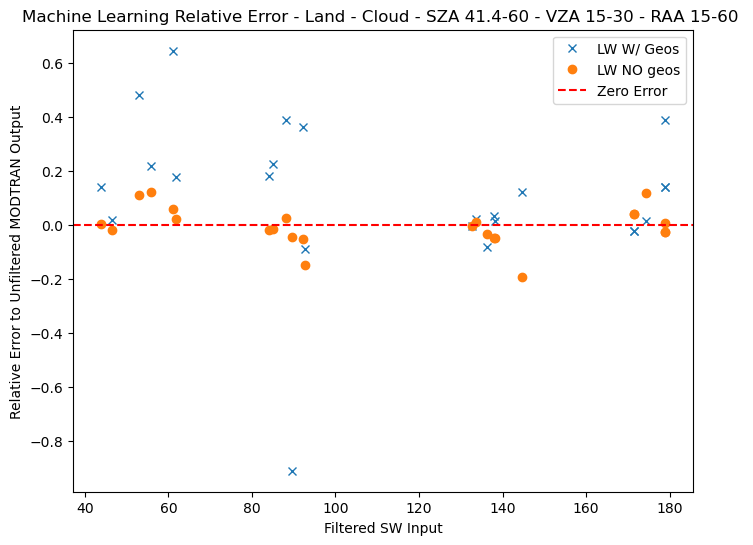

In [20]:
lw_bm_with_geos = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=False,
                                 input_features=['SZA', 'VZA', 'RAZ','Longwave Filtered Rads (Integrated)'],  best_params=lw_best, use_groups=True)

lw_bm_with_bands_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ','Longwave Filtered Rads (Integrated)'], lw_bm_with_geos['Final_Model'], is_sw=False)


lw_bm_no_geos = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=False,
                                 input_features=['Longwave Filtered Rads (Integrated)','SZA', 'VZA', 'RAZ',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=lw_best, use_groups=True)

lw_bm_no_bands_pe = calculate_pe(matt_test_data, ['Longwave Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], lw_bm_no_geos['Final_Model'], is_sw=False)

display_pe(sw_input, lw_bm_with_bands_pe, lw_bm_no_bands_pe, "LW W/ Geos", "LW NO geos")

In [21]:
test_sw_geos = bm_with_geos["Test_data"]
X_test_sw_geos = test_sw_geos["X_test"]
y_test_sw_geos = test_sw_geos["y_test"]
meta_test_sw_geos = test_sw_geos["meta_test"]
idxs_test_sw_geos = test_sw_geos["idxs"]
test_features = pd.DataFrame(X_test_sw_geos, columns=["SZA", 'VZA', 'RAZ',
       'Shortwave Filtered Rads (Integrated)'])
test_target = pd.Series(y_test_sw_geos, name="Shortwave Unfiltered Rads (Integrated)")
test_sw_geos_ds = pd.concat([test_features, test_target], axis=1)

test_sw_no_geos = bm_no_geos["Test_data"]
X_test_sw_no_geos = test_sw_no_geos["X_test"]
y_test_sw_no_geos = test_sw_no_geos["y_test"]
meta_test_sw_no_geos = test_sw_no_geos["meta_test"]
idxs_test_sw_no_geos = test_sw_no_geos["idxs"]
test_features = pd.DataFrame(X_test_sw_no_geos, columns=["SZA", 'VZA', 'RAZ',
       'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'])
test_target = pd.Series(y_test_sw_no_geos, name="Shortwave Unfiltered Rads (Integrated)")
geos = meta_test_sw_no_geos[["SZA", "VZA", "RAZ"]]
test_sw_no_geos_ds = pd.concat(
    [
        geos.reset_index(drop=True),
        test_features.reset_index(drop=True),
        test_target.reset_index(drop=True)
    ],
    axis=1
)

test_lw_geos = lw_bm_with_geos["Test_data"]
X_test_lw_geos = test_lw_geos["X_test"]
y_test_lw_geos = test_lw_geos["y_test"]
meta_test_lw_geos = test_lw_geos["meta_test"]
idxs_test_lw_geos = test_lw_geos["idxs"]
test_features = pd.DataFrame(X_test_lw_geos, columns=["SZA", 'VZA', 'RAZ',
       'Longwave Filtered Rads (Integrated)'])
test_target = pd.Series(y_test_lw_geos, name="Longwave Unfiltered Rads (Integrated)")
test_lw_geos_ds = pd.concat([test_features, test_target], axis=1)

test_lw_no_geos = lw_bm_no_geos["Test_data"]
X_test_lw_no_geos = test_lw_no_geos["X_test"]
y_test_lw_no_geos = test_lw_no_geos["y_test"]
meta_test_lw_no_geos = test_lw_no_geos["meta_test"]
idxs_test_lw_no_geos = test_lw_no_geos["idxs"]
test_features = pd.DataFrame(X_test_lw_no_geos, columns=["SZA", 'VZA', 'RAZ',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'])
test_target = pd.Series(y_test_lw_no_geos, name="Longwave Unfiltered Rads (Integrated)")
geos = meta_test_lw_no_geos[["SZA", "VZA", "RAZ"]]
# test_lw_no_geos_ds = pd.concat([geos, test_features, test_target], axis=1)
test_lw_no_geos_ds = pd.concat(
    [
        geos.reset_index(drop=True),
        test_features.reset_index(drop=True),
        test_target.reset_index(drop=True)
    ],
    axis=1
)

In [68]:
compare_global_vs_bin_fit_interactive(
    test_lw_geos_ds,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=lw_bm_with_geos["Final_Model"],
    name="LW",
    ml_features=["SZA", 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)'],
    is_sw=False
)


METRICS FOR: LW

Land - Global Fit (all data):
  R² Value: 0.9997
  RMSE: 0.2640
  Coefficients: [[0.        1.5957497]]
  Intercept: [-2.14658896]

Land - Binned Fit:
  R² Value: 0.9997
  RMSE: 0.2895
  Coefficients: [[0.         1.64083118]]
  Intercept: [-4.3413892]

ML Model (all data):
  R² Value: 0.9996
  RMSE: 0.3367
  MAPE: 0.35%
  Regression line: y = 0.9935x + 0.4156

ML Model (binned data):
  R² Value: 0.9990
  RMSE: 0.4918
  MAPE: 0.39%
  Regression line: y = 0.9801x + 1.5251



In [38]:
compare_global_vs_bin_fit_interactive(
    test_sw_geos_ds,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=bm_with_geos["Final_Model"],
    name="SW",
    ml_features=["SZA", 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)'],
    is_sw=True
)


METRICS FOR: SW

Land - Global Fit (all data):
  R² Value: 0.9997
  RMSE: 1.5797
  Coefficients: [[0.        1.3609419]]
  Intercept: [0.86764609]

Land - Binned Fit:
  R² Value: 1.0000
  RMSE: 0.0085
  Coefficients: [[0.         1.35465536]]
  Intercept: [1.95800123]

ML Model (all data):
  R² Value: 0.9999
  RMSE: 0.7525
  MAPE: 0.67%
  Regression line: y = 0.9994x + 0.0403

ML Model (binned data):
  R² Value: 0.9998
  RMSE: 0.6998
  MAPE: 4.29%
  Regression line: y = 0.9970x + 0.7564



Input features ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)']
In train test split: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)']
Train (4940, 4), Val (605, 4), Test (650, 4)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']
In calc pe ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)']
df cols: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Shortwave Unfiltered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Longwave Unfiltered Rads (Integrated)']


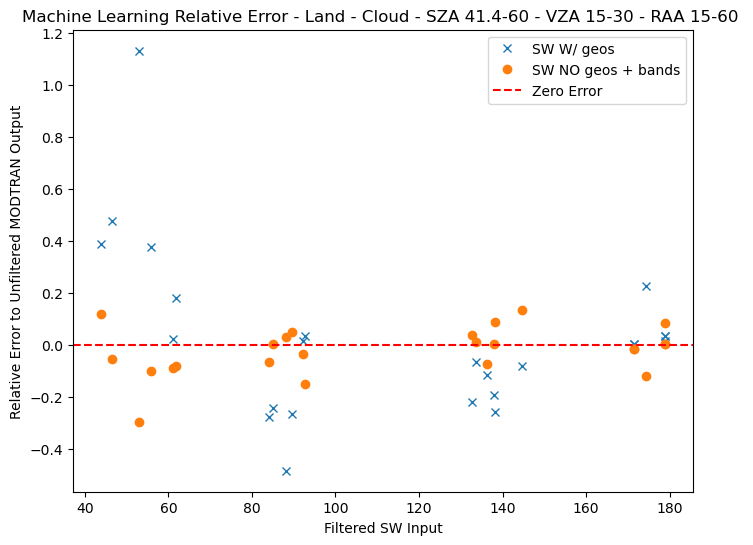

In [22]:
sw_with_geos = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True, input_features=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)'],  best_params=sw_2nd_best, use_groups=True)

sw_with_geos_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)'], sw_with_geos['Final_Model'])

# sw_no_geos = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
#                                  selected_viirs_bands=['Shortwave Filtered Rads (Integrated)',
#                                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
#                                                        'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=sw_2nd_best, use_groups=True)

# bm_no_geos_pe = calculate_pe(matt_test_data, ['Shortwave Filtered Rads (Integrated)',
#                                         'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
#                                         'M8', 'M9', 'I3', 'M10', 'M11'], bm_no_geos['Final_Model'])

display_pe(sw_input, sw_with_geos_pe, bm_no_geos_pe, "SW W/ geos", "SW NO geos + bands")

In [18]:
display_model_metrics(sw_with_geos)


Validation Metrics:
--------------------------------------------------
RMSE:      0.8664680502147426
MAE:       0.4929318642017383
MAPE:      0.8658469193589755%
R²:        0.9999046556192391

Cross-Validation:
--------------------------------------------------
RMSE (mean ± std): 1.8110804409744543 ± 0.600153731961305
RMSE per fold: ['1.2392553178613077', '1.135067806879728', '2.3588174670671496', '2.397429969101866', '1.924831643962219']

Test Metrics:
--------------------------------------------------
RMSE:      1.0685860230190392
MAE:       0.5093173498908767
MAPE:      0.6707691901967398%
R²:        0.9998640970020598


In [23]:
ssw_model = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 input_features=['SZA', 'VZA', 'RAZ', "Split Shortwave Filtered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)"],  best_params=sw_2nd_best, use_groups=True)

ssw_model_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ', "Split Shortwave Filtered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)"], ssw_model['Final_Model'], is_sw=True)

Input features ['SZA', 'VZA', 'RAZ', 'Split Shortwave Filtered Rads (Integrated)', 'Shortwave Filtered Rads (Integrated)']
In train test split: ['SZA', 'VZA', 'RAZ', 'Split Shortwave Filtered Rads (Integrated)', 'Shortwave Filtered Rads (Integrated)']
Train (4940, 5), Val (605, 5), Test (650, 5)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']
In calc pe ['SZA', 'VZA', 'RAZ', 'Split Shortwave Filtered Rads (Integrated)', 'Shortwave Filtered Rads (Integrated)']
df cols: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Shortwave Unfiltered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Longwave Unfiltered Rads (Integrated)']


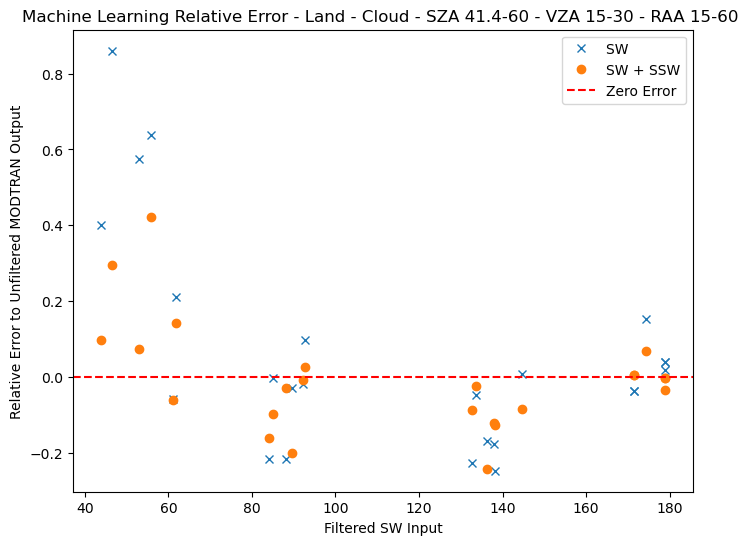

In [14]:
# sw_model = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
#                                  selected_viirs_bands=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)'],  best_params=sw_2nd_best, use_groups=True)
#
# sw_model_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)'], sw_model['Final_Model'], is_sw=True)

display_pe(sw_input, sw_with_geos_pe, ssw_model_pe, "SW ", "SW + SSW")

In [24]:
test_sw_geos_no_bands = sw_with_geos["Test_data"]
X_test_sw_geos_no_bands = test_sw_geos_no_bands["X_test"]
y_test_sw_geos_no_bands = test_sw_geos_no_bands["y_test"]
meta_test_sw_geos_no_bands = test_sw_geos_no_bands["meta_test"]
idxs_test_sw_geos_no_bands = test_sw_geos_no_bands["idxs"]
test_features = pd.DataFrame(X_test_sw_geos_no_bands, columns=["SZA", 'VZA', 'RAZ',
       'Shortwave Filtered Rads (Integrated)'])
test_target = pd.Series(y_test_sw_geos_no_bands, name="Shortwave Unfiltered Rads (Integrated)")
test_sw_geos_no_bands_ds = pd.concat([test_features, test_target], axis=1)

test_ssw = ssw_model["Test_data"]
X_test_ssw = test_ssw["X_test"]
y_test_ssw = test_ssw["y_test"]
meta_test_ssw = test_ssw["meta_test"]
idxs_test_ssw = test_ssw["idxs"]
test_features["Split Shortwave Filtered Rads (Integrated)"] = X_test_ssw[:, -1]
test_target = pd.Series(y_test_ssw, name="Shortwave Unfiltered Rads (Integrated)")
test_ssw_ds = pd.concat(
    [
        test_features,
        test_target
    ],
    axis=1
)

In [13]:
def compare_global_vs_bin_fit_interactive(df, scene="Land", sza_range=(45,60), vza_range=(15,30),
                                        raz_range=(15,60), degree=1, ml_model=None, name=None, ml_features=None, is_sw=True):
    """
    Compare global linear/poly fit vs a single geometry-bin fit with interactive plots.
    If ml_model is provided, also plots its predictions.
    """
    if is_sw:
        filt_col = "Shortwave Filtered Rads (Integrated)"
        unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
        temp = "SW"
    else:
        filt_col = "Longwave Filtered Rads (Integrated)"
        unfilt_col = "Longwave Unfiltered Rads (Integrated)"
        temp = "LW"

    # ---- GLOBAL FIT ----
    # land = df[df["Scene"] == scene] if scene is not None else df
    land = df
    X_global = land[[filt_col]].to_numpy().reshape(-1, 1)
    y_global = land[unfilt_col].to_numpy().reshape(-1, 1)

    poly = PolynomialFeatures(degree=degree)
    Xg_poly = poly.fit_transform(X_global)
    g_model = LinearRegression().fit(Xg_poly, y_global)

    # ---- BIN FIT ----
    subset = land[(land["SZA"].between(sza_range[0], sza_range[1])) &
                  (land["VZA"].between(vza_range[0], vza_range[1])) &
                  (land["RAZ"].between(raz_range[0], raz_range[1]))]

    X_bin = subset[filt_col].to_numpy().reshape(-1, 1)
    y_bin = subset[unfilt_col].to_numpy().reshape(-1, 1)

    Xb_poly = poly.fit_transform(X_bin)
    b_model = LinearRegression().fit(Xb_poly, y_bin)

    # Get predictions
    g_pred = g_model.predict(Xg_poly)
    b_pred = b_model.predict(Xb_poly)

    # Create layout based on whether ML model is provided
    n_cols = 2
    n_rows = 2 if ml_model is not None else 1

    subplot_titles = [f"{name} - Global Fit",
                     f"{name} - Binned (SZA={sza_range}, VZA={vza_range}, RAZ={raz_range})"]
    if ml_model is not None:
        subplot_titles.extend([f"ML Predictions - {name} (All Data)",
                              f"ML Predictions - {name} (Binned)"])

    fig = make_subplots(rows=n_rows, cols=n_cols, subplot_titles=subplot_titles)

    # ========== ROW 1: LINEAR/POLY FITS ==========

    # Plot 1: Global fit
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel(),
            y=y_global.ravel(),
            mode='markers',
            name='Data points (all)',
            marker=dict(size=4, opacity=0.5, color='lightblue'),
            hovertemplate="<br>".join([
                "Filtered: %{x:.2f}",
                "Unfiltered: %{y:.2f}",
            ]),
            showlegend=True
        ),
        row=1, col=1
    )

    idx_g = np.argsort(X_global.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel()[idx_g],
            y=g_pred.ravel()[idx_g],
            mode='lines',
            name=f'Global poly fit (deg={degree})',
            line=dict(color='green', width=2),
            showlegend=True
        ),
        row=1, col=1
    )

    # Plot 2: Binned fit
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel(),
            y=y_bin.ravel(),
            mode='markers',
            name='Data points (binned)',
            marker=dict(size=6, opacity=0.6, color='orange'),
            hovertemplate="<br>".join([
                "Filtered: %{x:.2f}",
                "Unfiltered: %{y:.2f}",
            ]),
            showlegend=True
        ),
        row=1, col=2
    )

    idx_b = np.argsort(X_bin.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel()[idx_b],
            y=b_pred.ravel()[idx_b],
            mode='lines',
            name=f'Binned poly fit (deg={degree})',
            line=dict(color='red', width=2),
            showlegend=True
        ),
        row=1, col=2
    )

    # ========== ROW 2: ML PREDICTIONS (if provided) ==========
    ml_pred = None
    ml_pred_bin = None
    reg_model = None
    reg_model_bin = None

    if ml_model is not None:
        # Get ML predictions

        subset2 = df[(df["SZA"].between(sza_range[0], sza_range[1])) &
                  (df["VZA"].between(vza_range[0], vza_range[1])) &
                  (df["RAZ"].between(raz_range[0], raz_range[1]))]

        X_ml = df[ml_features].to_numpy()
        X_bin_ml = subset2[ml_features].to_numpy()
        ml_pred = ml_model.predict(X_ml)
        ml_pred_bin = ml_model.predict(X_bin_ml)

        # ---- Plot 3: ML predictions (all data) ----
        fig.add_trace(
            go.Scatter(
                x=y_global.ravel(),
                y=ml_pred,
                mode='markers',
                name='ML predictions (all)',
                marker=dict(size=4, opacity=0.6, color='steelblue'),
                hovertemplate="<br>".join([
                    "True: %{x:.2f}",
                    "Predicted: %{y:.2f}",
                    "Error: %{customdata:.2f}"
                ]),
                customdata=ml_pred - y_global.ravel(),
                showlegend=True
            ),
            row=2, col=1
        )

        # Perfect prediction line (y=x) for all data
        min_val = min(y_global.min(), ml_pred.min())
        max_val = max(y_global.max(), ml_pred.max())
        fig.add_trace(
            go.Scatter(
                x=[min_val, max_val],
                y=[min_val, max_val],
                mode='lines',
                name='Perfect prediction',
                line=dict(color='black', width=1, dash='dash'),
                showlegend=True
            ),
            row=2, col=1
        )

        # Regression line for ML predictions (all data)
        idx_ml = np.argsort(y_global.ravel())
        X_line = y_global.ravel()[idx_ml].reshape(-1, 1)
        y_line = ml_pred[idx_ml].reshape(-1, 1)
        reg_model = LinearRegression().fit(X_line, y_line)
        line_pred = reg_model.predict(X_line)

        fig.add_trace(
            go.Scatter(
                x=X_line.ravel(),
                y=line_pred.ravel(),
                mode='lines',
                name='ML regression line (all)',
                line=dict(color='red', width=2),
                showlegend=True
            ),
            row=2, col=1
        )

        # ---- Plot 4: ML predictions (binned) ----
        fig.add_trace(
            go.Scatter(
                x=y_bin.ravel(),
                y=ml_pred_bin,
                mode='markers',
                name='ML predictions (binned)',
                marker=dict(size=6, opacity=0.6, color='purple'),
                hovertemplate="<br>".join([
                    "True: %{x:.2f}",
                    "Predicted: %{y:.2f}",
                    "Error: %{customdata:.2f}"
                ]),
                customdata=ml_pred_bin - y_bin.ravel(),
                showlegend=True
            ),
            row=2, col=2
        )

        # Perfect prediction line (y=x) for binned data
        min_val_bin = min(y_bin.min(), ml_pred_bin.min())
        max_val_bin = max(y_bin.max(), ml_pred_bin.max())
        fig.add_trace(
            go.Scatter(
                x=[min_val_bin, max_val_bin],
                y=[min_val_bin, max_val_bin],
                mode='lines',
                name='Perfect prediction',
                line=dict(color='black', width=1, dash='dash'),
                showlegend=False  # Already shown in col 1
            ),
            row=2, col=2
        )

        # Regression line for ML predictions (binned)
        idx_ml_bin = np.argsort(y_bin.ravel())
        X_line_bin = y_bin.ravel()[idx_ml_bin].reshape(-1, 1)
        y_line_bin = ml_pred_bin[idx_ml_bin].reshape(-1, 1)
        reg_model_bin = LinearRegression().fit(X_line_bin, y_line_bin)
        line_pred_bin = reg_model_bin.predict(X_line_bin)

        fig.add_trace(
            go.Scatter(
                x=X_line_bin.ravel(),
                y=line_pred_bin.ravel(),
                mode='lines',
                name='ML regression line (binned)',
                line=dict(color='red', width=2),
                showlegend=False  # Similar to col 1
            ),
            row=2, col=2
        )

    # Update layout
    height = 800 if ml_model is not None else 400
    fig.update_layout(
        height=height,
        width=1400,
        showlegend=True,
        title_text=f"Model Comparisons for {scene if scene else 'All Scenes'}",
    )

    # Update axes labels
    # Row 1: Filtered vs Unfiltered
    fig.update_xaxes(title_text=f"Filtered {temp} Radiance", row=1, col=1)
    fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", row=1, col=1)
    fig.update_xaxes(title_text=f"Filtered {temp} Radiance", row=1, col=2)
    fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", row=1, col=2)

    # Row 2: True vs Predicted (if ML model exists)
    if ml_model is not None:
        fig.update_xaxes(title_text=f"True Unfiltered {temp} Radiance", row=2, col=1)
        fig.update_yaxes(title_text=f"Predicted Unfiltered {temp} Radiance", row=2, col=1)
        fig.update_xaxes(title_text=f"True Unfiltered {temp} Radiance", row=2, col=2)
        fig.update_yaxes(title_text=f"Predicted Unfiltered {temp} Radiance", row=2, col=2)

    fig.show()

    # ========== PRINT METRICS ==========
    print(f"\n{'='*60}")
    print(f"METRICS FOR: {name if name else scene}")
    print(f"{'='*60}")

    print(f"\n{scene if scene else 'All'} - Global Fit (all data):")
    print(f"  R² Value: {r2_score(y_global, g_pred):.4f}")
    print(f"  RMSE: {root_mean_squared_error(y_global, g_pred):.4f}")
    print(f"  Coefficients: {g_model.coef_}")
    print(f"  Intercept: {g_model.intercept_}")

    print(f"\n{scene if scene else 'All'} - Binned Fit:")
    print(f"  R² Value: {r2_score(y_bin, b_pred):.4f}")
    print(f"  RMSE: {root_mean_squared_error(y_bin, b_pred):.4f}")
    print(f"  Coefficients: {b_model.coef_}")
    print(f"  Intercept: {b_model.intercept_}")

    if ml_pred is not None:
        print(f"\nML Model (all data):")
        print(f"  R² Value: {r2_score(y_global, ml_pred):.4f}")
        print(f"  RMSE: {root_mean_squared_error(y_global, ml_pred):.4f}")
        print(f"  MAPE: {mean_absolute_percentage_error(y_global, ml_pred)*100:.2f}%")
        print(f"  Regression line: y = {reg_model.coef_[0][0]:.4f}x + {reg_model.intercept_[0]:.4f}")

        print(f"\nML Model (binned data):")
        print(f"  R² Value: {r2_score(y_bin, ml_pred_bin):.4f}")
        print(f"  RMSE: {root_mean_squared_error(y_bin, ml_pred_bin):.4f}")
        print(f"  MAPE: {mean_absolute_percentage_error(y_bin, ml_pred_bin)*100:.2f}%")
        print(f"  Regression line: y = {reg_model_bin.coef_[0][0]:.4f}x + {reg_model_bin.intercept_[0]:.4f}")

    print(f"{'='*60}\n")

In [14]:
def plot_ml_predictions(df, ml_model, ml_features, scene=None, is_sw=True, name=None):
    """
    Plot ML model predictions vs true values.

    Parameters:
    -----------
    df : pd.DataFrame
        Data to plot
    ml_model : trained model
        ML model with .predict() method
    ml_features : list[str]
        Feature names to use for prediction
    scene : str, optional
        Scene name to filter data (e.g., "Land"). If None, uses all data.
    is_sw : bool
        True for shortwave, False for longwave
    name : str, optional
        Name for plot title. If None, uses scene name or "All Scenes"
    """
    # Select data
    data = df[df["Scene"] == scene] if scene is not None else df

    # Determine columns and labels
    if is_sw:
        unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
        wave_type = "SW"
    else:
        unfilt_col = "Longwave Unfiltered Rads (Integrated)"
        wave_type = "LW"

    # Get predictions
    X_ml = data[ml_features].to_numpy()
    y_true = data[unfilt_col].to_numpy()
    y_pred = ml_model.predict(X_ml)

    # Create figure
    fig = go.Figure()

    # Scatter plot of predictions vs true values
    fig.add_trace(
        go.Scatter(
            x=y_true,
            y=y_pred,
            mode='markers',
            name='Predictions',
            marker=dict(size=6, opacity=0.6, color='steelblue'),
            hovertemplate="<br>".join([
                "True: %{x:.2f}",
                "Predicted: %{y:.2f}",
                "Error: %{customdata:.2f}"
            ]),
            customdata=y_pred - y_true
        )
    )

    # Add perfect prediction line (y=x)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    fig.add_trace(
        go.Scatter(
            x=[min_val, max_val],
            y=[min_val, max_val],
            mode='lines',
            name='Perfect prediction',
            line=dict(color='black', width=2, dash='dash')
        )
    )

    # Add regression line through predictions
    idx_sort = np.argsort(y_true)
    X_line = y_true[idx_sort].reshape(-1, 1)
    y_line = y_pred[idx_sort].reshape(-1, 1)

    from sklearn.linear_model import LinearRegression
    reg_model = LinearRegression().fit(X_line, y_line)
    line_pred = reg_model.predict(X_line)

    fig.add_trace(
        go.Scatter(
            x=X_line.ravel(),
            y=line_pred.ravel(),
            mode='lines',
            name='Regression line',
            line=dict(color='red', width=2)
        )
    )

    # Calculate metrics
    from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_percentage_error
    r2 = r2_score(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    # Update layout
    plot_title = name if name else (scene if scene else "All Scenes")
    fig.update_layout(
        title=f"ML Model Predictions: {plot_title}",
        xaxis_title=f"True Unfiltered {wave_type} Radiance",
        yaxis_title=f"Predicted Unfiltered {wave_type} Radiance",
        height=600,
        width=800,
        showlegend=True,
        annotations=[
            dict(
                x=0.05, y=0.95,
                xref='paper', yref='paper',
                text=f"R² = {r2:.4f}<br>RMSE = {rmse:.4f}<br>MAPE = {mape:.2f}%",
                showarrow=False,
                font=dict(size=12),
                bgcolor='rgba(255,255,255,0.8)',
                bordercolor='black',
                borderwidth=1
            )
        ]
    )

    fig.show()

    # Print metrics
    print(f"\n{plot_title} ML Model Metrics:")
    print(f"R² Value: {r2:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"Mean Absolute Percentage Error: {mape:.2f}%")
    print(f"Regression line: y = {reg_model.coef_[0][0]:.4f}x + {reg_model.intercept_[0]:.4f}")


In [16]:
plot_ml_predictions(df=test_ssw_ds, ml_model=ssw_model['Final_Model'], ml_features=['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', "Split Shortwave Filtered Rads (Integrated)"], scene=None, is_sw=True, name="All Scenes")


All Scenes ML Model Metrics:
R² Value: 0.8201
Root Mean Squared Error: 38.8761
Mean Absolute Percentage Error: 48.60%
Regression line: y = 1.0933x + 25.0207


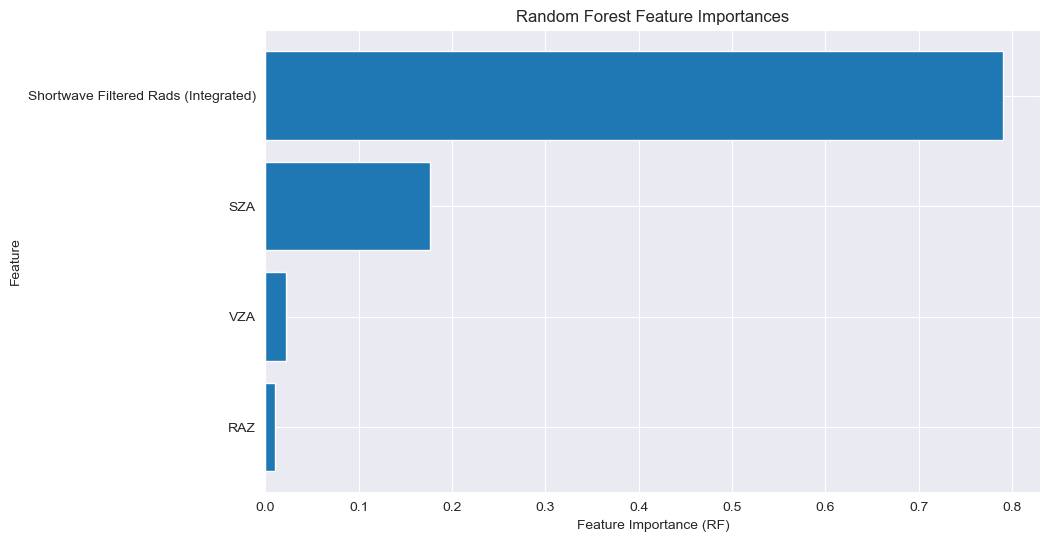

In [34]:
plot_importances(sw_with_geos, ["SZA", 'VZA', 'RAZ', "Shortwave Filtered Rads (Integrated)"])

In [15]:
def compare_global_vs_bin_fit_interactive(df, scene="Land", sza_range=(45,60), vza_range=(15,30),
                                        raz_range=(15,60), degree=1, ml_model=None, name=None, ml_features=None, is_sw=True):
    """
    Compare global linear/poly fit vs a single geometry-bin fit with interactive plots.
    If ml_model is provided, also plots its predictions.

    Now properly handles multi-feature ML models (e.g., split shortwave models with
    split SW filtered, SW filtered, and geometry features).
    """
    if is_sw:
        filt_col = "Shortwave Filtered Rads (Integrated)"
        unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
        temp = "SW"
    else:
        filt_col = "Longwave Filtered Rads (Integrated)"
        unfilt_col = "Longwave Unfiltered Rads (Integrated)"
        temp = "LW"

    # ---- GLOBAL FIT ----
    # land = df[df["Scene"] == scene] if scene is not None else df
    land = df
    X_global = land[[filt_col]].to_numpy().reshape(-1, 1)
    y_global = land[unfilt_col].to_numpy().reshape(-1, 1)

    poly = PolynomialFeatures(degree=degree)
    Xg_poly = poly.fit_transform(X_global)
    g_model = LinearRegression().fit(Xg_poly, y_global)

    # ---- BIN FIT ----
    subset = land[(land["SZA"].between(sza_range[0], sza_range[1])) &
                  (land["VZA"].between(vza_range[0], vza_range[1])) &
                  (land["RAZ"].between(raz_range[0], raz_range[1]))]

    X_bin = subset[filt_col].to_numpy().reshape(-1, 1)
    y_bin = subset[unfilt_col].to_numpy().reshape(-1, 1)

    Xb_poly = poly.fit_transform(X_bin)
    b_model = LinearRegression().fit(Xb_poly, y_bin)

    # Get predictions
    g_pred = g_model.predict(Xg_poly)
    b_pred = b_model.predict(Xb_poly)

    # Create layout based on whether ML model is provided
    n_cols = 2
    n_rows = 2 if ml_model is not None else 1

    subplot_titles = [f"{name} - Global Fit",
                     f"{name} - Binned (SZA={sza_range}, VZA={vza_range}, RAZ={raz_range})"]
    if ml_model is not None:
        subplot_titles.extend([f"ML Predictions - {name} (All Data)",
                              f"ML Predictions - {name} (Binned)"])

    fig = make_subplots(rows=n_rows, cols=n_cols, subplot_titles=subplot_titles)

    # ========== ROW 1: LINEAR/POLY FITS ==========

    # Plot 1: Global fit
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel(),
            y=y_global.ravel(),
            mode='markers',
            name='Data points (all)',
            marker=dict(size=4, opacity=0.5, color='lightblue'),
            hovertemplate="<br>".join([
                "Filtered: %{x:.2f}",
                "Unfiltered: %{y:.2f}",
            ]),
            showlegend=True
        ),
        row=1, col=1
    )

    idx_g = np.argsort(X_global.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel()[idx_g],
            y=g_pred.ravel()[idx_g],
            mode='lines',
            name=f'Global poly fit (deg={degree})',
            line=dict(color='green', width=2),
            showlegend=True
        ),
        row=1, col=1
    )

    # Plot 2: Binned fit
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel(),
            y=y_bin.ravel(),
            mode='markers',
            name='Data points (binned)',
            marker=dict(size=6, opacity=0.6, color='orange'),
            hovertemplate="<br>".join([
                "Filtered: %{x:.2f}",
                "Unfiltered: %{y:.2f}",
            ]),
            showlegend=True
        ),
        row=1, col=2
    )

    idx_b = np.argsort(X_bin.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel()[idx_b],
            y=b_pred.ravel()[idx_b],
            mode='lines',
            name=f'Binned poly fit (deg={degree})',
            line=dict(color='red', width=2),
            showlegend=True
        ),
        row=1, col=2
    )

    # ========== ROW 2: ML PREDICTIONS (if provided) ==========
    ml_pred = None
    ml_pred_bin = None
    reg_model = None
    reg_model_bin = None

    if ml_model is not None:
        # Get ML predictions using the same filtered data (land) as the linear models
        # This ensures consistency when scene filtering is applied
        X_ml = land[ml_features].to_numpy()
        ml_pred = ml_model.predict(X_ml)

        # For binned predictions, use the same subset as the binned linear fit
        X_bin_ml = subset[ml_features].to_numpy()
        ml_pred_bin = ml_model.predict(X_bin_ml)

        # ---- Plot 3: ML predictions (all data) ----
        fig.add_trace(
            go.Scatter(
                x=y_global.ravel(),
                y=ml_pred,
                mode='markers',
                name='ML predictions (all)',
                marker=dict(size=4, opacity=0.6, color='steelblue'),
                hovertemplate="<br>".join([
                    "True: %{x:.2f}",
                    "Predicted: %{y:.2f}",
                    "Error: %{customdata:.2f}"
                ]),
                customdata=ml_pred - y_global.ravel(),
                showlegend=True
            ),
            row=2, col=1
        )

        # Perfect prediction line (y=x) for all data
        min_val = min(y_global.min(), ml_pred.min())
        max_val = max(y_global.max(), ml_pred.max())
        fig.add_trace(
            go.Scatter(
                x=[min_val, max_val],
                y=[min_val, max_val],
                mode='lines',
                name='Perfect prediction',
                line=dict(color='black', width=1, dash='dash'),
                showlegend=True
            ),
            row=2, col=1
        )

        # Regression line for ML predictions (all data)
        idx_ml = np.argsort(y_global.ravel())
        X_line = y_global.ravel()[idx_ml].reshape(-1, 1)
        y_line = ml_pred[idx_ml].reshape(-1, 1)
        reg_model = LinearRegression().fit(X_line, y_line)
        line_pred = reg_model.predict(X_line)

        fig.add_trace(
            go.Scatter(
                x=X_line.ravel(),
                y=line_pred.ravel(),
                mode='lines',
                name='ML regression line (all)',
                line=dict(color='red', width=2),
                showlegend=True
            ),
            row=2, col=1
        )

        # ---- Plot 4: ML predictions (binned) ----
        fig.add_trace(
            go.Scatter(
                x=y_bin.ravel(),
                y=ml_pred_bin,
                mode='markers',
                name='ML predictions (binned)',
                marker=dict(size=6, opacity=0.6, color='purple'),
                hovertemplate="<br>".join([
                    "True: %{x:.2f}",
                    "Predicted: %{y:.2f}",
                    "Error: %{customdata:.2f}"
                ]),
                customdata=ml_pred_bin - y_bin.ravel(),
                showlegend=True
            ),
            row=2, col=2
        )

        # Perfect prediction line (y=x) for binned data
        min_val_bin = min(y_bin.min(), ml_pred_bin.min())
        max_val_bin = max(y_bin.max(), ml_pred_bin.max())
        fig.add_trace(
            go.Scatter(
                x=[min_val_bin, max_val_bin],
                y=[min_val_bin, max_val_bin],
                mode='lines',
                name='Perfect prediction',
                line=dict(color='black', width=1, dash='dash'),
                showlegend=False  # Already shown in col 1
            ),
            row=2, col=2
        )

        # Regression line for ML predictions (binned)
        idx_ml_bin = np.argsort(y_bin.ravel())
        X_line_bin = y_bin.ravel()[idx_ml_bin].reshape(-1, 1)
        y_line_bin = ml_pred_bin[idx_ml_bin].reshape(-1, 1)
        reg_model_bin = LinearRegression().fit(X_line_bin, y_line_bin)
        line_pred_bin = reg_model_bin.predict(X_line_bin)

        fig.add_trace(
            go.Scatter(
                x=X_line_bin.ravel(),
                y=line_pred_bin.ravel(),
                mode='lines',
                name='ML regression line (binned)',
                line=dict(color='red', width=2),
                showlegend=False  # Similar to col 1
            ),
            row=2, col=2
        )

    # Update layout
    height = 800 if ml_model is not None else 400
    fig.update_layout(
        height=height,
        width=1400,
        showlegend=True,
        title_text=f"Model Comparisons for {scene if scene else 'All Scenes'}",
    )

    # Update axes labels
    # Row 1: Filtered vs Unfiltered
    fig.update_xaxes(title_text=f"Filtered {temp} Radiance", row=1, col=1)
    fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", row=1, col=1)
    fig.update_xaxes(title_text=f"Filtered {temp} Radiance", row=1, col=2)
    fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", row=1, col=2)

    # Row 2: True vs Predicted (if ML model exists)
    if ml_model is not None:
        fig.update_xaxes(title_text=f"True Unfiltered {temp} Radiance", row=2, col=1)
        fig.update_yaxes(title_text=f"Predicted Unfiltered {temp} Radiance", row=2, col=1)
        fig.update_xaxes(title_text=f"True Unfiltered {temp} Radiance", row=2, col=2)
        fig.update_yaxes(title_text=f"Predicted Unfiltered {temp} Radiance", row=2, col=2)

    fig.show()

    # ========== PRINT METRICS ==========
    print(f"\n{'='*60}")
    print(f"METRICS FOR: {name if name else scene}")
    print(f"{'='*60}")

    print(f"\n{scene if scene else 'All'} - Global Fit (all data):")
    print(f"  R² Value: {r2_score(y_global, g_pred):.4f}")
    print(f"  RMSE: {root_mean_squared_error(y_global, g_pred):.4f}")
    print(f"  Coefficients: {g_model.coef_}")
    print(f"  Intercept: {g_model.intercept_}")

    print(f"\n{scene if scene else 'All'} - Binned Fit:")
    print(f"  R² Value: {r2_score(y_bin, b_pred):.4f}")
    print(f"  RMSE: {root_mean_squared_error(y_bin, b_pred):.4f}")
    print(f"  Coefficients: {b_model.coef_}")
    print(f"  Intercept: {b_model.intercept_}")

    if ml_pred is not None:
        print(f"\nML Model (all data):")
        print(f"  R² Value: {r2_score(y_global, ml_pred):.4f}")
        print(f"  RMSE: {root_mean_squared_error(y_global, ml_pred):.4f}")
        print(f"  MAPE: {mean_absolute_percentage_error(y_global, ml_pred)*100:.2f}%")
        print(f"  Regression line: y = {reg_model.coef_[0][0]:.4f}x + {reg_model.intercept_[0]:.4f}")

        print(f"\nML Model (binned data):")
        print(f"  R² Value: {r2_score(y_bin, ml_pred_bin):.4f}")
        print(f"  RMSE: {root_mean_squared_error(y_bin, ml_pred_bin):.4f}")
        print(f"  MAPE: {mean_absolute_percentage_error(y_bin, ml_pred_bin)*100:.2f}%")
        print(f"  Regression line: y = {reg_model_bin.coef_[0][0]:.4f}x + {reg_model_bin.intercept_[0]:.4f}")

    print(f"{'='*60}\n")

In [23]:
def plot_importances(model, feature_names=None):
    importances = model["Final_Model"].feature_importances_

    # Try to get feature names from model, otherwise use provided names or generic names
    if hasattr(model["Final_Model"], 'feature_names_in_'):
        features = model["Final_Model"].feature_names_in_
    elif feature_names is not None:
        features = feature_names
    else:
        # Generic feature names
        features = [f"Feature {i}" for i in range(len(importances))]

    importance_df = (
        pd.Series(importances, index=features)
          .sort_values(ascending=False)
          .rename_axis("Feature")
          .reset_index(name="Importance")
    )

    # Plot as heatmap or bar chart
    plt.figure(figsize=(10,6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel("Feature Importance (RF)")
    plt.ylabel("Feature")
    plt.title("Random Forest Feature Importances")
    plt.gca().invert_yaxis()
    plt.show()

In [ ]:
plot_importances(ssw_model, ["SZA", 'VZA', 'RAZ', 'Split Shortwave Filtered Rads (Integrated)', "Shortwave Filtered Rads (Integrated)"])

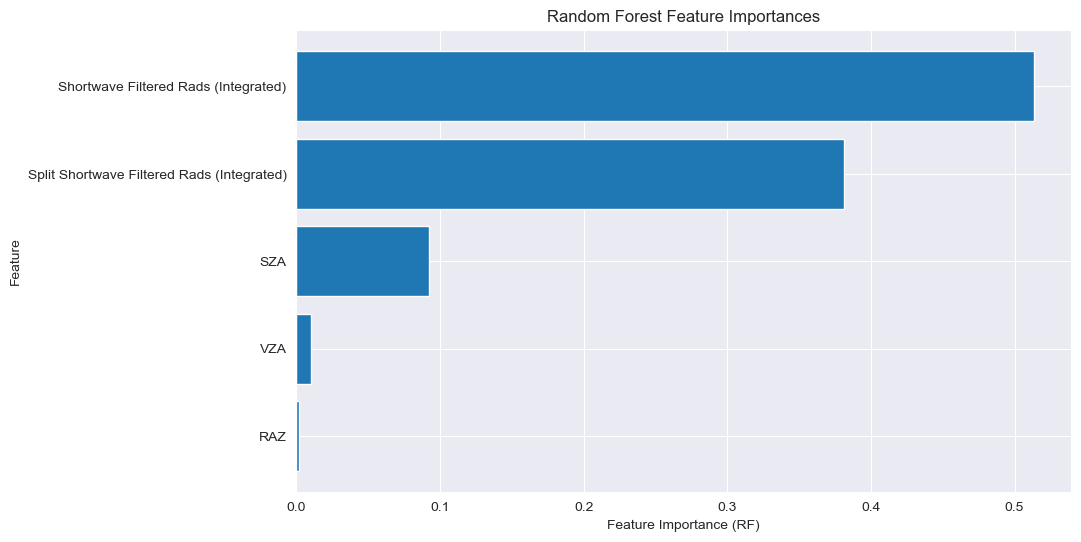

In [35]:
plot_importances(ssw_model, ["SZA", 'VZA', 'RAZ', 'Split Shortwave Filtered Rads (Integrated)', "Shortwave Filtered Rads (Integrated)"])

# STANDARD METHOD QUADRATIC SMQ



In [17]:
# land_sza_41_runs = load_all_runs_from_tp7("./data/Modtran_Unfiltering_Tape7s_SZA41/lnd_sz41L.tp7", header_lines=12)
# a00_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA00")
# a41_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA41")
# a60_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA60")
# a75_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA75")
# a85_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA85")
# snow_dfs = [file.describer_df for file in snow_data]
# snow_dataset = pd.concat(snow_dfs, axis=0)
# land_dfs = [file.describer_df for file in land_data]
# dc_dfs = [file.describer_df for file in dc_data]
# cloud_dfs = [file.describer_df for file in cloudy_data]
# clear_dfs = [file.describer_df for file in clear_data]
# land_dataset = pd.concat(land_dfs, axis=0)
# dc_dataset = pd.concat(dc_dfs, axis=0)
# cloud_dataset = pd.concat(cloud_dfs, axis=0)
# clear_dataset = pd.concat(clear_dfs, axis=0)
# all_dataset = pd.concat([snow_dataset, land_dataset, dc_dataset, cloud_dataset, clear_dataset])
os.listdir("./data/Modtran_Unfiltering_Tape7s_SZA41")

['.DS_Store',
 'sno_sz41L.tp7',
 'lnd_sz41L.tp7',
 'oceclr_sz41L.tp7',
 'dc_sz41.spectra.tp7',
 'ocecld_sz41L.tp7']

In [21]:
snow_dataset

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),...,I3,M10,M11,I4,M12,M13,M14,M15,I5,M16
0,Snow,0.000,0.000,0.0,0,0,307.528673,64.630148,223.028925,41.965232,...,0.788612,0.788612,0.256200,0.007365,0.004348,0.001302,0.000088,0.000138,0.000294,0.000190
1,Snow,0.000,0.000,0.0,1,1,308.989576,61.707542,224.248333,40.116431,...,0.810478,0.810478,0.261258,0.023179,0.013530,0.005802,0.000327,0.000176,0.000381,0.000226
2,Snow,0.000,0.000,0.0,1,2,307.570444,65.121000,222.762654,42.268825,...,0.459548,0.459548,0.185318,0.005659,0.003081,0.000960,0.000084,0.000111,0.000276,0.000193
3,Snow,0.000,0.000,0.0,1,3,367.808738,53.795463,271.728794,35.110162,...,6.130183,6.130183,1.111976,0.617699,0.347688,0.160067,0.012621,0.007502,0.010138,0.003258
4,Snow,0.000,0.000,0.0,1,4,323.988001,63.367576,236.912900,41.203241,...,5.174450,5.174450,1.129244,0.639892,0.377263,0.147548,0.011686,0.006478,0.008392,0.002541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,Snow,83.928,89.947,172.5,0,310,72.642480,55.204991,51.300045,35.872650,...,0.133322,0.133322,0.010539,0.002607,0.001669,0.000262,0.000016,0.000069,0.000111,0.000072
311,Snow,83.928,89.947,172.5,1,311,92.298272,42.378937,67.134657,27.621768,...,1.141790,1.141790,0.272472,0.171527,0.101630,0.041075,0.003688,0.000781,0.001448,0.000791
312,Snow,83.928,89.947,172.5,1,312,87.839910,53.257830,63.201569,34.673715,...,0.542783,0.542783,0.128367,0.006041,0.004059,0.000427,0.000067,0.000161,0.000338,0.000266
313,Snow,83.928,89.947,172.5,1,313,113.020691,47.220680,83.541169,30.899859,...,2.552133,2.552133,0.464214,0.269270,0.179506,0.032531,0.005186,0.005883,0.007889,0.003408


In [24]:
geom_cols = ["SZA", "VZA", "RAZ"]

unique_triplets = (
    snow_dataset[geom_cols]
    .drop_duplicates()
    .reset_index(drop=True)
)
unique_triplets

,SZA,VZA,RAZ
0,0.000,0.000,0.0
1,0.066,30.000,7.5
2,0.311,30.000,37.5
3,0.511,30.000,90.0
4,0.511,30.000,142.5
...,...,...,...
102,85.710,89.947,7.5
103,85.532,89.947,37.5
104,84.884,89.947,90.0
105,84.153,89.947,142.5


In [25]:
all_dataset

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),...,M12,M13,M14,M15,I5,M16,Scaled Shortwave Filtered,Scaled Shortwave Unfiltered,Scaled Longwave Filtered,Scaled Longwave Unfiltered
0,Snow,0.000,0.000,0.0,0,0,307.528673,64.630148,223.028925,41.965232,...,0.004348,0.001302,0.000088,0.000138,0.000294,0.000190,0.460896,0.500871,0.492032,0.477688
1,Snow,0.000,0.000,0.0,1,1,308.989576,61.707542,224.248333,40.116431,...,0.013530,0.005802,0.000327,0.000176,0.000381,0.000226,0.463442,0.503278,0.453486,0.439632
2,Snow,0.000,0.000,0.0,1,2,307.570444,65.121000,222.762654,42.268825,...,0.003081,0.000960,0.000084,0.000111,0.000276,0.000193,0.460340,0.500940,0.498362,0.484079
3,Snow,0.000,0.000,0.0,1,3,367.808738,53.795463,271.728794,35.110162,...,0.347688,0.160067,0.012621,0.007502,0.010138,0.003258,0.562603,0.600195,0.349109,0.336606
4,Snow,0.000,0.000,0.0,1,4,323.988001,63.367576,236.912900,41.203241,...,0.377263,0.147548,0.011686,0.006478,0.008392,0.002541,0.489892,0.527991,0.476145,0.461247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,Clear Ocean,83.845,89.947,172.5,0,142,55.161028,68.826211,38.618218,44.481189,...,0.002860,0.000531,0.000014,0.000010,0.000013,0.000005,0.075762,0.085044,0.544488,0.532326
143,Clear Ocean,83.845,89.947,172.5,0,143,58.683832,68.796818,41.352139,44.467129,...,0.004841,0.000933,0.000018,0.000013,0.000016,0.000006,0.081471,0.090849,0.544195,0.531943
144,Clear Ocean,83.845,89.947,172.5,0,144,62.944481,68.745825,44.653951,44.440408,...,0.008280,0.001732,0.000027,0.000019,0.000023,0.000008,0.088367,0.097869,0.543638,0.531279
145,Clear Ocean,83.845,89.947,172.5,0,145,68.463058,68.719250,48.915804,44.427437,...,0.013350,0.003030,0.000036,0.000023,0.000027,0.000009,0.097268,0.106962,0.543367,0.530933


# Final research regular quad method END

In [20]:
def generate_multivariate_coefficients(dataset: pd.DataFrame) -> list:

    coefficients = {}

    SZA_BINS = [
        (0.0, 22.2),
        (22.2, 41.4),
        (41.4, 60.0),
        (60.0, 75.5),
        (75.5, 85.0),
    ]

    VZA_BINS = [
        (0.0, 15.0),
        (15.0, 30.0),
        (30.0, 45.0),
        (45.0, 60.0),
        (60.0, 90.0),
    ]

    RAZ_BINS = [
        (0.0, 15.0),
        (15.0, 60.0),
        (60.0, 120.0),
        (120.0, 165.0),
        (165.0, 180.0),
    ]

    angular_bins = [
        (sza_bin, vza_bin, raz_bin)
        for sza_bin in SZA_BINS
        for vza_bin in VZA_BINS
        for raz_bin in RAZ_BINS
    ]

    no_data = []

    for sza_bin, vza_bin, raz_bin in angular_bins:
        binned_data = dataset[
            (dataset["SZA"].between(*sza_bin)) &
            (dataset["VZA"].between(*vza_bin)) &
            (dataset["RAZ"].between(*raz_bin))
        ]
        filtered_sw = binned_data["Shortwave Filtered Rads (Integrated)"]
        unfiltered_sw = binned_data["Shortwave Unfiltered Rads (Integrated)"]
        filtered_lw = binned_data["Longwave Filtered Rads (Integrated)"]
        unfiltered_lw = binned_data["Longwave Unfiltered Rads (Integrated)"]

        filtered_ssw = binned_data["Split Shortwave Filtered Rads (Integrated)"]
        sw_coef, ssw_coef, lw_coef = None, None, None

        try:
            fit_sw = np.polynomial.polynomial.Polynomial.fit(filtered_sw, unfiltered_sw, 2)
            fit_lw = np.polynomial.polynomial.Polynomial.fit(filtered_lw, unfiltered_lw, 2)
            sw_coef = fit_sw.convert().coef
            lw_coef = fit_lw.convert().coef

            input = np.vstack((filtered_sw, filtered_ssw)).transpose()
            output = unfiltered_sw
            poly_model = PolynomialFeatures(degree=2)
            poly_x = poly_model.fit_transform(input)
            poly_model.fit(poly_x, output)
            regression = LinearRegression()
            regression.fit(poly_x, output)
            ssw_coef = regression.coef_

        except:
            no_data.append((sza_bin, vza_bin, raz_bin))
            print("No data for: ", (sza_bin, vza_bin, raz_bin))

        coefficients[(sza_bin, vza_bin, raz_bin)] = (sw_coef, ssw_coef, lw_coef)

    return [coefficients, no_data]


land_coefficients = generate_multivariate_coefficients(land_dataset)
snow_coefficients = generate_multivariate_coefficients(snow_dataset)
dc_coefficients = generate_multivariate_coefficients(dc_dataset)
cloud_coefficients = generate_multivariate_coefficients(cloud_dataset)
clear_coefficients = generate_multivariate_coefficients(clear_dataset)
bin_check = [land_coefficients[1], dc_coefficients[1], dc_coefficients[1], cloud_coefficients[1], clear_coefficients[1]]

No data for:  ((0.0, 22.2), (0.0, 15.0), (15.0, 60.0))
No data for:  ((0.0, 22.2), (0.0, 15.0), (60.0, 120.0))
No data for:  ((0.0, 22.2), (0.0, 15.0), (120.0, 165.0))
No data for:  ((0.0, 22.2), (0.0, 15.0), (165.0, 180.0))
No data for:  ((22.2, 41.4), (0.0, 15.0), (15.0, 60.0))
No data for:  ((22.2, 41.4), (0.0, 15.0), (60.0, 120.0))
No data for:  ((22.2, 41.4), (0.0, 15.0), (120.0, 165.0))
No data for:  ((22.2, 41.4), (0.0, 15.0), (165.0, 180.0))
No data for:  ((22.2, 41.4), (15.0, 30.0), (0.0, 15.0))
No data for:  ((22.2, 41.4), (15.0, 30.0), (15.0, 60.0))
No data for:  ((22.2, 41.4), (30.0, 45.0), (0.0, 15.0))
No data for:  ((22.2, 41.4), (30.0, 45.0), (15.0, 60.0))
No data for:  ((22.2, 41.4), (45.0, 60.0), (0.0, 15.0))
No data for:  ((22.2, 41.4), (45.0, 60.0), (15.0, 60.0))
No data for:  ((22.2, 41.4), (60.0, 90.0), (0.0, 15.0))
No data for:  ((22.2, 41.4), (60.0, 90.0), (15.0, 60.0))
No data for:  ((41.4, 60.0), (0.0, 15.0), (15.0, 60.0))
No data for:  ((41.4, 60.0), (0.0, 15.

In [19]:
from itertools import combinations
from typing import Dict, List, Tuple, Set

GeometryBin = Tuple[Tuple[float, float], Tuple[float, float], Tuple[float, float]]


def compare_no_data_bins(
    scene_no_data: Dict[str, List[GeometryBin]],
    verbose: bool = True,
):
    """
    Compare missing (no_data) geometry bins across scenes.

    Parameters
    ----------
    scene_no_data : dict
        Mapping from scene name -> list of (SZA_bin, VZA_bin, RAZ_bin)
    verbose : bool
        Print summary to stdout

    Returns
    -------
    results : dict
        {
          "shared": set of bins missing in ALL scenes,
          "pairwise": {
              (scene_a, scene_b): {
                  "shared": set,
                  "only_a": set,
                  "only_b": set
              }
          },
          "per_scene_unique": {
              scene: set of bins missing ONLY in that scene
          }
        }
    """

    # Convert lists → sets
    scene_sets: Dict[str, Set[GeometryBin]] = {
        scene: set(bins) for scene, bins in scene_no_data.items()
    }

    scenes = list(scene_sets.keys())

    # ---- bins missing in *all* scenes ----
    shared_all = set.intersection(*scene_sets.values())

    # ---- pairwise comparisons ----
    pairwise = {}
    for a, b in combinations(scenes, 2):
        pairwise[(a, b)] = {
            "shared": scene_sets[a] & scene_sets[b],
            "only_a": scene_sets[a] - scene_sets[b],
            "only_b": scene_sets[b] - scene_sets[a],
        }

    # ---- bins unique to a single scene ----
    per_scene_unique = {}
    for scene in scenes:
        others = set.union(*(scene_sets[s] for s in scenes if s != scene))
        per_scene_unique[scene] = scene_sets[scene] - others

    # ---- optional printing ----
    if verbose:
        print("\n=== NO-DATA GEOMETRY COMPARISON ===")
        print("Scenes:", scenes)
        print(f"\nMissing in ALL scenes: {len(shared_all)}")

        for (a, b), res in pairwise.items():
            print(f"\n{a} vs {b}")
            print("  shared:", len(res["shared"]))
            print(f"  only {a}:", len(res["only_a"]))
            print(f"  only {b}:", len(res["only_b"]))

        print("\nUnique missing bins per scene:")
        for scene, bins in per_scene_unique.items():
            print(f"  {scene}: {len(bins)}")

    return {
        "shared": shared_all,
        "pairwise": pairwise,
        "per_scene_unique": per_scene_unique,
    }

scene_no_data = {
    "land":  land_coefficients[1],
    "snow":  snow_coefficients[1],
    "dc":    dc_coefficients[1],
    "cloud": cloud_coefficients[1],
    "clear": clear_coefficients[1],
}

results = compare_no_data_bins(scene_no_data)

NameError: name 'land_coefficients' is not defined

In [20]:
type(land_coefficients[0])

dict

In [18]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# typing alias (optional)
GeomBin = tuple[tuple[float, float], tuple[float, float], tuple[float, float]]

def generate_multivariate_coefficients_by_cloud(dataset: pd.DataFrame) -> list:
    """
    Returns:
      coefficients: dict keyed by (cloud_flag, sza_bin, vza_bin, raz_bin)
                    value: (sw_coef, ssw_coef, lw_coef)
      no_data: list of keys for which we couldn't fit
    """

    coefficients = {}

    SZA_BINS = [(0.0, 22.2), (22.2, 41.4), (41.4, 60.0), (60.0, 75.5), (75.5, 85.0)]
    VZA_BINS = [(0.0, 15.0), (15.0, 30.0), (30.0, 45.0), (45.0, 60.0), (60.0, 90.0)]
    RAZ_BINS = [(0.0, 15.0), (15.0, 60.0), (60.0, 120.0), (120.0, 165.0), (165.0, 180.0)]

    angular_bins = [(sza, vza, raz) for sza in SZA_BINS for vza in VZA_BINS for raz in RAZ_BINS]

    no_data = []

    # Ensure Cloud exists and is 0/1
    if "Cloud" not in dataset.columns:
        raise ValueError("Dataset must contain a 'Cloud' column with 0/1 values.")

    for cloud_flag in [0, 1]:
        cloud_data = dataset[dataset["Cloud"] == cloud_flag]

        for sza_bin, vza_bin, raz_bin in angular_bins:
            binned = cloud_data[
                (cloud_data["SZA"].between(*sza_bin)) &
                (cloud_data["VZA"].between(*vza_bin)) &
                (cloud_data["RAZ"].between(*raz_bin))
            ]

            sw_coef, ssw_coef, lw_coef = None, None, None
            key = (cloud_flag, sza_bin, vza_bin, raz_bin)

            try:
                # ---- SW / LW 1D quadratic fits ----
                filtered_sw = binned["Shortwave Filtered Rads (Integrated)"].to_numpy()
                unfiltered_sw = binned["Shortwave Unfiltered Rads (Integrated)"].to_numpy()

                filtered_lw = binned["Longwave Filtered Rads (Integrated)"].to_numpy()
                unfiltered_lw = binned["Longwave Unfiltered Rads (Integrated)"].to_numpy()

                # Need enough points to fit stably
                if len(filtered_sw) < 3 or len(filtered_lw) < 3:
                    raise ValueError("Not enough points in bin to fit polynomial.")

                fit_sw = np.polynomial.polynomial.Polynomial.fit(filtered_sw, unfiltered_sw, 2)
                fit_lw = np.polynomial.polynomial.Polynomial.fit(filtered_lw, unfiltered_lw, 2)
                sw_coef = fit_sw.convert().coef
                lw_coef = fit_lw.convert().coef

                # ---- SSW multivariate polynomial regression (SW + SSW -> SW_unfiltered) ----
                filtered_ssw = binned["Split Shortwave Filtered Rads (Integrated)"].to_numpy()
                if len(filtered_ssw) < 3:
                    raise ValueError("Not enough points for SSW regression.")

                X = np.vstack([filtered_sw, filtered_ssw]).T
                y = unfiltered_sw

                poly = PolynomialFeatures(degree=2, include_bias=True)
                X_poly = poly.fit_transform(X)

                reg = LinearRegression()
                reg.fit(X_poly, y)

                # Store BOTH the polynomial feature definition and coefficients,
                # otherwise you can't reconstruct prediction correctly later.
                # We store (coef, intercept, feature_names) minimal version:
                ssw_coef = {
                    "coef": reg.coef_,
                    "intercept": reg.intercept_,
                    "feature_names": poly.get_feature_names_out(["sw_filt", "ssw_filt"]).tolist(),
                }

            except Exception:
                no_data.append(key)

            coefficients[key] = (sw_coef, ssw_coef, lw_coef)

    return [coefficients, no_data]

# land_coeffs, land_no_data = generate_multivariate_coefficients_by_cloud(land_dataset)
# snow_coeffs, snow_no_data = generate_multivariate_coefficients_by_cloud(snow_dataset)
# dc_coeffs, dc_no_data     = generate_multivariate_coefficients_by_cloud(dc_dataset)
# cloud_coeffs, cloud_no_data = generate_multivariate_coefficients_by_cloud(cloud_dataset)
# clear_coeffs, clear_no_data  = generate_multivariate_coefficients_by_cloud(clear_dataset)
#
# bin_check = {
#     "land": land_no_data,
#     "snow": snow_no_data,
#     "dc": dc_no_data,
#     "cloud": cloud_no_data,
#     "clear": clear_no_data,
# }

In [32]:
from typing import Optional, Tuple

GeomBin = Tuple[Tuple[float, float], Tuple[float, float], Tuple[float, float]]

SZA_BINS = [(0.0, 22.2), (22.2, 41.4), (41.4, 60.0), (60.0, 75.5), (75.5, 85.0)]
VZA_BINS = [(0.0, 15.0), (15.0, 30.0), (30.0, 45.0), (45.0, 60.0), (60.0, 90.0)]
RAZ_BINS = [(0.0, 15.0), (15.0, 60.0), (60.0, 120.0), (120.0, 165.0), (165.0, 180.0)]

def find_geometry_bin(sza: float, vza: float, raz: float) -> Optional[GeomBin]:
    sza_bin = next((b for b in SZA_BINS if b[0] <= sza <= b[1]), None)
    vza_bin = next((b for b in VZA_BINS if b[0] <= vza <= b[1]), None)
    raz_bin = next((b for b in RAZ_BINS if b[0] <= raz <= b[1]), None)
    if sza_bin is None or vza_bin is None or raz_bin is None:
        return None
    return (sza_bin, vza_bin, raz_bin)


In [24]:
def apply_unfiltering_by_cloud(
    df: pd.DataFrame,
    coefficients: dict,
    sw_filt_col="Shortwave Filtered Rads (Integrated)",
    ssw_filt_col="Split Shortwave Filtered Rads (Integrated)",
    lw_filt_col="Longwave Filtered Rads (Integrated)",
    out_sw="SW_unf_pred",
    out_lw="LW_unf_pred",
    out_sw_ssw="SW_unf_pred_ssw",
) -> pd.DataFrame:
    """
    coefficients key: (cloud_flag, sza_bin, vza_bin, raz_bin)
    value: (sw_coef (np.ndarray), ssw_model (dict), lw_coef (np.ndarray))
    """

    out = df.copy()
    n = len(out)

    sw_pred = np.full(n, np.nan)
    lw_pred = np.full(n, np.nan)
    sw_ssw_pred = np.full(n, np.nan)

    # Fast local refs
    sw_x = out[sw_filt_col].to_numpy()
    ssw_x = out[ssw_filt_col].to_numpy() if ssw_filt_col in out.columns else None
    lw_x = out[lw_filt_col].to_numpy()
    sza = out["SZA"].to_numpy()
    vza = out["VZA"].to_numpy()
    raz = out["RAZ"].to_numpy()
    cloud = out["Cloud"].to_numpy()

    for i in range(n):
        geom_bin = find_geometry_bin(float(sza[i]), float(vza[i]), float(raz[i]))
        if geom_bin is None:
            # print("No geometry bin for :", float(sza[i]), float(vza[i]), float(raz[i]))
            continue

        cloud_flag = int(cloud[i])
        key = (cloud_flag, geom_bin[0], geom_bin[1], geom_bin[2])

        coef_triplet = coefficients.get(key)
        if coef_triplet is None:
            # print("No coeff triplet for: ", key)
            continue

        sw_coef, ssw_model, lw_coef = coef_triplet

        # 1D SW poly
        if sw_coef is not None and np.isfinite(sw_x[i]):
            sw_pred[i] = np.polynomial.polynomial.polyval(sw_x[i], sw_coef)

        # 1D LW poly
        if lw_coef is not None and np.isfinite(lw_x[i]):
            lw_pred[i] = np.polynomial.polynomial.polyval(lw_x[i], lw_coef)

        # Multivariate SW+SSW -> SW_unfiltered (degree=2)
        if ssw_model is not None and ssw_x is not None and np.isfinite(sw_x[i]) and np.isfinite(ssw_x[i]):
            # feature order we stored: ['1', 'sw_filt', 'ssw_filt', 'sw_filt^2', 'sw_filt ssw_filt', 'ssw_filt^2']
            # (PolynomialFeatures(degree=2, include_bias=True))
            x1 = float(sw_x[i])
            x2 = float(ssw_x[i])
            feats = np.array([1.0, x1, x2, x1*x1, x1*x2, x2*x2], dtype=float)

            coef = np.asarray(ssw_model["coef"], dtype=float)
            intercept = float(ssw_model["intercept"])

            sw_ssw_pred[i] = intercept + float(np.dot(coef, feats))

    out[out_sw] = sw_pred
    out[out_lw] = lw_pred
    out[out_sw_ssw] = sw_ssw_pred
    return out


In [25]:
# def _metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
#     mask = np.isfinite(y_true) & np.isfinite(y_pred)
#     y_true = y_true[mask]
#     y_pred = y_pred[mask]
#     if len(y_true) == 0:
#         return {"n": 0, "MAE": np.nan, "RMSE": np.nan, "Bias": np.nan, "MAPE_%": np.nan}
#
#     err = y_pred - y_true
#     mae = float(np.mean(np.abs(err)))
#     rmse = float(np.sqrt(np.mean(err**2)))
#     bias = float(np.mean(err))
#     mape = float(np.mean(np.abs(err) / np.maximum(np.abs(y_true), 1e-12)) * 100.0)
#     r2 = float(r2_score(y_true, y_pred))
#
#     return {"n": int(len(y_true)), "MAE": mae, "RMSE": rmse, "Bias": bias, "MAPE_%": mape, "r2" : r2}

def _metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    # print(f"in metrics - len true {len(y_true)} : len pred {len(y_pred)}")
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    n = len(y_true)
    if n == 0:
        print("N IS 0")
        return {"n": 0, "MAE": np.nan, "RMSE": np.nan, "Bias": np.nan, "MAPE_%": np.nan, "R2": np.nan}

    err = y_pred - y_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    bias = float(np.mean(err))
    mape = float(np.mean(np.abs(err) / np.maximum(np.abs(y_true), 1e-12)) * 100.0)

    # R2 guard
    if n < 2 or np.var(y_true) == 0:
        # print("N : ", n)
        r2 = np.nan
    else:
        # print('calculating r2', float(r2_score(y_true, y_pred)))
        r2 = float(r2_score(y_true, y_pred))

    return {
        "n": int(n),
        "MAE": mae,
        "RMSE": rmse,
        "Bias": bias,
        "MAPE_%": mape,
        "R2": r2
    }


def evaluate_by_cloud(
    df: pd.DataFrame,
    sw_true="Shortwave Unfiltered Rads (Integrated)",
    lw_true="Longwave Unfiltered Rads (Integrated)",
    sw_pred="SW_unf_pred",
    lw_pred="LW_unf_pred",
    sw_pred_ssw="SW_unf_pred_ssw",
) -> dict:
    results = {}

    # overall
    results["overall"] = {
        "SW_1D": _metrics(df[sw_true].to_numpy(), df[sw_pred].to_numpy()),
        "LW_1D": _metrics(df[lw_true].to_numpy(), df[lw_pred].to_numpy()),
        "SW_SSW": _metrics(df[sw_true].to_numpy(), df[sw_pred_ssw].to_numpy()),
    }

    # per cloud flag
    for cloud_flag in [0, 1]:
        sub = df[df["Cloud"] == cloud_flag]
        results[f"cloud={cloud_flag}"] = {
            "SW_1D": _metrics(sub[sw_true].to_numpy(), sub[sw_pred].to_numpy()),
            "LW_1D": _metrics(sub[lw_true].to_numpy(), sub[lw_pred].to_numpy()),
            "SW_SSW": _metrics(sub[sw_true].to_numpy(), sub[sw_pred_ssw].to_numpy()),
        }

    results["standard_df"] = df

    return results


In [26]:
def grouped_train_val_test_split_final(
    df: pd.DataFrame,
    target_col: str,
    input_features: list[str],
    train_size: float = 0.8,
    val_size: float = 0.1,
    random_state: int = 42
):
    """
    Custom split grouped by Scene+Run # to avoid leakage,
    while maintaining Scene distribution across splits.
    Returns numpy arrays for features and targets.
    """
    np.random.seed(random_state)
    df = df.reset_index(drop=True)

    # Create unique group identifiers
    df = df.copy()
    # df['group_key'] = df["Scene"].astype(str) + "|" + df["Run #"].astype(str)
    df['group_key'] = (
        df["Scene"].astype(str) + "|" +
        df["Cloud"].astype(str) + "|" +
        df["Run #"].astype(str)
    )
    # Get unique groups per scene
    scene_groups = df.groupby(["Scene", "Cloud"])["group_key"].unique()

    train_groups = []
    val_groups = []
    test_groups = []

    # Split each scene's groups independently
    for scene, groups in scene_groups.items():
        n_groups = len(groups)
        groups_shuffled = np.random.permutation(groups)

        # Calculate split points
        n_train = int(n_groups * train_size)
        n_val = int(n_groups * val_size)

        train_groups.extend(groups_shuffled[:n_train])
        val_groups.extend(groups_shuffled[n_train:n_train + n_val])
        test_groups.extend(groups_shuffled[n_train + n_val:])

    # Create boolean masks for indexing
    train_mask = df['group_key'].isin(train_groups)
    val_mask = df['group_key'].isin(val_groups)
    test_mask = df['group_key'].isin(test_groups)

    tr_idx = df[train_mask].index.to_numpy()
    val_idx = df[val_mask].index.to_numpy()
    test_idx = df[test_mask].index.to_numpy()

    print(f"In train test split: {input_features}")

    # Prepare data
    X_full = df[input_features]
    y_full = df[target_col]

    if target_col == "Shortwave Unfiltered Rads (Integrated)":
        filtered_col = "Shortwave Filtered Rads (Integrated)"
    else:
        filtered_col = "Longwave Filtered Rads (Integrated)"

    def pack(idxs):
        return (
            X_full.loc[idxs].to_numpy(),
            y_full.loc[idxs].to_numpy(),
            df.loc[idxs][["Scene", "Run #", "SZA", "VZA", "RAZ", 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', filtered_col]],
            idxs
        )

    return pack(tr_idx), pack(val_idx), pack(test_idx)

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def grouped_train_val_test_split_final_2(
    df: pd.DataFrame,
    target_col: str,
    input_features: list[str],
    train_size: float = 0.8,
    val_size: float = 0.1,
    random_state: int = 42,
    stratify_target: bool = True,
    n_target_bins: int = 5,
):
    """
    Custom grouped split by Scene+Cloud+Run# to avoid leakage,
    while maintaining Scene/Cloud distribution across splits.

    If stratify_target=True, also stratifies group assignment using
    group-level target quantiles (helps preserve high-radiance groups).
    """
    rng = np.random.RandomState(random_state)
    df = df.reset_index(drop=True).copy()

    df["group_key"] = (
        df["Scene"].astype(str) + "|" +
        df["Cloud"].astype(str) + "|" +
        df["Run #"].astype(str)
    )

    # ---- One row per group ----
    group_df = (
        df.groupby("group_key")
        .agg(
            Scene=("Scene", "first"),
            Cloud=("Cloud", "first"),
            target_stat=(target_col, "max"),   # use max to preserve upper tail
        )
        .reset_index()
    )

    train_groups = []
    val_groups = []
    test_groups = []

    # Split within each Scene/Cloud bucket
    for (scene, cloud), sub in group_df.groupby(["Scene", "Cloud"]):
        sub = sub.copy()

        n_groups = len(sub)
        if n_groups < 3:
            # fallback if too few groups
            groups_shuffled = rng.permutation(sub["group_key"].to_numpy())
            n_train = max(1, int(n_groups * train_size))
            n_val = max(0, int(n_groups * val_size))

            train_groups.extend(groups_shuffled[:n_train])
            val_groups.extend(groups_shuffled[n_train:n_train + n_val])
            test_groups.extend(groups_shuffled[n_train + n_val:])
            continue

        if stratify_target:
            # build target bins inside this scene/cloud bucket
            n_bins_here = min(n_target_bins, sub["target_stat"].nunique(), max(2, n_groups // 2))
            if n_bins_here >= 2:
                try:
                    sub["target_bin"] = pd.qcut(
                        sub["target_stat"],
                        q=n_bins_here,
                        labels=False,
                        duplicates="drop"
                    )
                except ValueError:
                    sub["target_bin"] = 0
            else:
                sub["target_bin"] = 0
        else:
            sub["target_bin"] = 0

        # First split: train vs temp
        try:
            g_train, g_temp = train_test_split(
                sub["group_key"],
                train_size=train_size,
                random_state=random_state,
                stratify=sub["target_bin"] if stratify_target and sub["target_bin"].nunique() > 1 else None
            )
        except ValueError:
            g_train, g_temp = train_test_split(
                sub["group_key"],
                train_size=train_size,
                random_state=random_state,
                stratify=None
            )

        temp_sub = sub[sub["group_key"].isin(g_temp)].copy()

        # relative val fraction inside temp
        temp_fraction = 1.0 - train_size
        val_relative = val_size / temp_fraction

        try:
            g_val, g_test = train_test_split(
                temp_sub["group_key"],
                train_size=val_relative,
                random_state=random_state,
                stratify=temp_sub["target_bin"] if stratify_target and temp_sub["target_bin"].nunique() > 1 else None
            )
        except ValueError:
            g_val, g_test = train_test_split(
                temp_sub["group_key"],
                train_size=val_relative,
                random_state=random_state,
                stratify=None
            )

        train_groups.extend(g_train.tolist())
        val_groups.extend(g_val.tolist())
        test_groups.extend(g_test.tolist())

    train_mask = df["group_key"].isin(train_groups)
    val_mask = df["group_key"].isin(val_groups)
    test_mask = df["group_key"].isin(test_groups)

    tr_idx = df[train_mask].index.to_numpy()
    val_idx = df[val_mask].index.to_numpy()
    test_idx = df[test_mask].index.to_numpy()

    print(f"In train/val/test split: {input_features}")

    X_full = df[input_features]
    y_full = df[target_col]

    if target_col == "Shortwave Unfiltered Rads (Integrated)":
        filtered_col = "Shortwave Filtered Rads (Integrated)"
    else:
        filtered_col = "Longwave Filtered Rads (Integrated)"

    def pack(idxs):
        return (
            X_full.loc[idxs].to_numpy(),
            y_full.loc[idxs].to_numpy(),
            df.loc[idxs][[
                "Scene", "Run #", "SZA", "VZA", "RAZ",
                "M1", "M2", "M3", "M4", "I1", "M5", "DNB", "M6", "I2",
                "M7", "M8", "M9", "I3", "M10", "M11", filtered_col
            ]],
            idxs
        )

    return pack(tr_idx), pack(val_idx), pack(test_idx)


from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple

import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold, KFold


@dataclass
class GridSearchResult:
    best_params: Dict[str, Any]
    best_rmse: float
    cv_type: str


def tune_rf_two_ways(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    *,
    groups_tr: Optional[np.ndarray] = None,
    n_splits: int = 5,
    random_state: int = 42,
    param_grid: Optional[Dict[str, list]] = None,
    n_jobs: int = -1,
    verbose: int = 0,
) -> Tuple[Dict[str, Any], Dict[str, GridSearchResult]]:
    """
    Runs 2 grid searches on the TRAIN set only:
      1) GroupKFold CV (requires groups_tr)
      2) Standard KFold CV

    Returns:
      - params_to_use: best params chosen (prefers grouped if provided)
      - details: dict with results for both searches
    """

    if param_grid is None:
        # keep this small-ish for runtime; expand later if needed
        param_grid = {
            # "n_estimators": [100, 200, 300, 400, 500, 600],
            "n_estimators": np.arange(100, 600, 100),
            "max_depth": [8, 12, 16, None],
            "max_features": ["sqrt", "log2"],
            "min_samples_split": [2, 4],
            "min_samples_leaf": [1, 2],
            "bootstrap": [True],
            "max_samples": [None, 0.8],
        }

    base = RandomForestRegressor(random_state=random_state, n_jobs=n_jobs)

    details: Dict[str, GridSearchResult] = {}

    # --- 1) GroupKFold grid search (preferred) ---
    if groups_tr is not None:
        gkf = GroupKFold(n_splits=n_splits)
        gsearch = GridSearchCV(
            estimator=base,
            param_grid=param_grid,
            scoring="neg_root_mean_squared_error",
            cv=gkf,
            n_jobs=n_jobs,
            verbose=verbose,
            refit=True,
        )
        gsearch.fit(X_tr, y_tr, groups=groups_tr)

        details["groupkfold"] = GridSearchResult(
            best_params=gsearch.best_params_,
            best_rmse=float(-gsearch.best_score_),
            cv_type="GroupKFold",
        )

    # --- 2) Standard KFold grid search ---
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    ksearch = GridSearchCV(
        estimator=base,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=kf,
        n_jobs=n_jobs,
        verbose=verbose,
        refit=True,
    )
    ksearch.fit(X_tr, y_tr)

    details["kfold"] = GridSearchResult(
        best_params=ksearch.best_params_,
        best_rmse=float(-ksearch.best_score_),
        cv_type="KFold",
    )

    # Choose params: prefer grouped if available, otherwise kfold
    if "groupkfold" in details:
        params_to_use = details["groupkfold"].best_params
    else:
        params_to_use = details["kfold"].best_params

    # Always ensure we keep these stable
    params_to_use = dict(params_to_use)
    params_to_use["random_state"] = random_state
    params_to_use["n_jobs"] = n_jobs  # so training later uses parallelism

    return params_to_use, details

In [27]:
import pandas as pd
def final_ml_testing(
    dataset: pd.DataFrame,
    v: bool,
    is_sw: bool = True,
    input_features: list[str] | None = None,
    best_params: dict | None = None,
    use_groups: bool = True,
    n_splits: int = 5,
    refit_on_val: bool = True
):
    """
    Train a RandomForest model, validate on held-out data, and optionally refit
    on train+val before evaluating on the test set.
    """
    ret = {}
    dataset_ = dataset.reset_index(drop=True)
    target_col = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"

    print(f"Input features {input_features}")

    (X_tr, y_tr, meta_tr, tr_idx), (X_val, y_val, meta_val, val_idx), (X_te, y_te, meta_te, te_idx) = (None,None,None,None), (None,None,None,None), (None,None,None,None)

    if is_sw:
        (X_tr, y_tr, meta_tr, tr_idx), (X_val, y_val, meta_val, val_idx), (X_te, y_te, meta_te, te_idx) = grouped_train_val_test_split_final_2(
        dataset_,
        target_col=target_col,
        input_features=input_features,
        train_size=0.8,
        val_size=0.1,
        random_state=42
    )
    else:
        (X_tr, y_tr, meta_tr, tr_idx), (X_val, y_val, meta_val, val_idx), (X_te, y_te, meta_te, te_idx) = grouped_train_val_test_split_final(
        dataset_,
        target_col=target_col,
        input_features=input_features,
        train_size=0.8,
        val_size=0.1,
        random_state=42
    )

    train_idxs = tr_idx
    val_idxs   = val_idx
    test_idxs  = te_idx
    train_df = dataset_.iloc[train_idxs].copy()
    val_df   = dataset_.iloc[val_idxs].copy()
    test_df  = dataset_.iloc[test_idxs].copy()

    print("data sizes")
    print(train_df.shape)
    print(val_df.shape)
    print(test_df.shape)

    # ---- Traditional regression (coefficients) ----
    coeffs, no_data = generate_multivariate_coefficients_by_cloud(train_df)
    val_reg = apply_unfiltering_by_cloud(val_df, coeffs)
    val_scores = evaluate_by_cloud(val_reg)
    ret["Regression_val"] = val_scores

    trainval_df = pd.concat([train_df, val_df], axis=0)
    coeffs_final, _ = generate_multivariate_coefficients_by_cloud(trainval_df)
    test_reg = apply_unfiltering_by_cloud(test_df, coeffs_final)
    test_reg_scores = evaluate_by_cloud(test_reg)
    # test_reg = apply_unfiltering_by_cloud(test_df, coeffs_final)

    # normalize regression pred column names if needed:
    rename_map = {
        "SW_unf_pred": "SW_unf_pred_reg",
        "LW_unf_pred": "LW_unf_pred_reg",
    }
    test_reg = test_reg.rename(columns={k:v for k,v in rename_map.items() if k in test_reg.columns})

    ret["Regression_test"] = test_reg_scores

    if v:
        print(f"Train {X_tr.shape}, Val {X_val.shape}, Test {X_te.shape}")
        print("Train scenes:", meta_tr["Scene"].unique())

    params = {}

    if best_params is None:
        if use_groups:
            groups_all = (
                dataset_["Scene"].astype(str) + "|" +
                dataset_["Cloud"].astype(str) + "|" +
                dataset_["Run #"].astype(str)
            ).to_numpy()

            groups_tr = groups_all[tr_idx]
        else:
            groups_tr = None

        tuned_params, tune_details = tune_rf_two_ways(
            X_tr, y_tr,
            groups_tr=groups_tr,
            n_splits=n_splits,
            random_state=42,
            verbose=0,
        )

        params = tuned_params
        ret["GridSearch"] = {
            "chosen": "GroupKFold" if groups_tr is not None else "KFold",
            "groupkfold_best_rmse": getattr(tune_details.get("groupkfold"), "best_rmse", None),
            "kfold_best_rmse": tune_details["kfold"].best_rmse,
            "groupkfold_best_params": getattr(tune_details.get("groupkfold"), "best_params", None),
            "kfold_best_params": tune_details["kfold"].best_params,
        }
    else:
        params = best_params

    # params = best_params or {
    #     'max_depth': 16,
    #     'max_features': 'log2',
    #     'max_samples': None,
    #     'min_samples_leaf': 1,
    #     'min_samples_split': 2,
    #     'n_estimators': 600,
    #     'random_state': 42,
    #     'bootstrap': True
    # }

    model = RandomForestRegressor(**params)
    model.fit(X_tr, y_tr)
    y_val_pred = model.predict(X_val)

    ret["Val_RMSE"] = root_mean_squared_error(y_val, y_val_pred)
    ret["Val_MAE"] = mean_absolute_error(y_val, y_val_pred)
    ret["Val_MAPE%"] = mean_absolute_percentage_error(y_val, y_val_pred) * 100
    ret["Val_R2"] = r2_score(y_val, y_val_pred)

    if use_groups:
        groups = (
            dataset_["Scene"].astype(str) + "|" +
            dataset_["Cloud"].astype(str) + "|" +
            dataset_["Run #"].astype(str)
        )
        splitter = GroupKFold(n_splits=n_splits)
        folds = list(splitter.split(X_tr, y_tr, groups.iloc[tr_idx]))
    else:
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        folds = list(splitter.split(X_tr, y_tr))

    cv_scores_neg = cross_val_score(
        RandomForestRegressor(**params),
        X_tr, y_tr,
        cv=folds,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    ret["CV_Fold_RMSEs"] = -cv_scores_neg
    ret["CV_RMSE_mean"] = float(np.mean(-cv_scores_neg))
    ret["CV_RMSE_std"] = float(np.std(-cv_scores_neg, ddof=1))

    if refit_on_val:
        X_trval = np.concatenate([X_tr, X_val], axis=0)
        y_trval = np.concatenate([y_tr, y_val], axis=0)
        final_model = RandomForestRegressor(**params)
        final_model.fit(X_trval, y_trval)
        y_test_pred = final_model.predict(X_te)

        test_ml = test_df.copy()
        pred_col = "SW_unf_pred_ml" if is_sw else "LW_unf_pred_ml"
        test_ml[pred_col] = y_test_pred
        ret["ML_test_df"] = test_ml
        ret["Regression_test_df"] = test_reg

        test_plot = test_reg.copy()
        test_plot[pred_col] = y_test_pred
        ret["Test_plot_df"] = test_plot

        ret["Test_RMSE"] = root_mean_squared_error(y_te, y_test_pred)
        ret["Test_MAE"] = mean_absolute_error(y_te, y_test_pred)
        ret["Test_MAPE%"] = mean_absolute_percentage_error(y_te, y_test_pred) * 100
        ret["Test_R2"] = r2_score(y_te, y_test_pred)
        ret["Final_Model"] = final_model
    else:
        ret["Final_Model"] = model


    ret["Params_Used"] = params
    ret["Train_data"] = {"X_tr": X_tr, "y_tr": y_tr, "meta_tr": train_df, "idxs": train_idxs}
    ret["Validation_data"] = {"X_val": X_val, "y_val": y_val, "meta_val": val_df, "idxs": val_idxs}
    ret["Test_data"] = {"X_test": X_te, "y_test": y_te, "meta_test": test_df, "idxs": te_idx}

    return ret

In [28]:
import pandas as pd

def one_hot_encode_scene(
    df: pd.DataFrame,
    scene_col: str = "Scene",
    categories: list[str] | None = None,
    prefix: str = "Scene",
    drop_original: bool = False,
    dtype: str = "int8",
) -> tuple[pd.DataFrame, list[str]]:
    """
    One-hot encode a Scene column with stable dummy columns.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    scene_col : str
        Name of the scene column.
    categories : list[str] | None
        If provided, forces these categories (stable columns).
        If None, uses sorted unique values from df[scene_col].
    prefix : str
        Prefix for dummy columns.
    drop_original : bool
        Whether to drop the original scene column.
    dtype : str
        dtype for dummy columns.

    Returns
    -------
    df_out : pd.DataFrame
        Copy of df with one-hot columns added.
    dummy_cols : list[str]
        Names of the created dummy columns (in order).
    """
    df_out = df.copy()

    # Convert scene values to string for consistent column naming
    scene_series = df_out[scene_col].astype(str)

    if categories is None:
        categories = sorted(scene_series.unique().tolist())

    # Make it a categorical so get_dummies creates consistent columns
    scene_cat = pd.Categorical(scene_series, categories=[str(c) for c in categories])

    dummies = pd.get_dummies(scene_cat, prefix=prefix, dtype=dtype)

    # Attach dummies
    df_out = pd.concat([df_out, dummies], axis=1)

    if drop_original:
        df_out = df_out.drop(columns=[scene_col])

    return df_out, dummies.columns.tolist()

In [29]:
def encode_scene_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds a Scene_encoded column with fixed integer encoding.
    """

    if "Scene" not in df.columns:
        raise ValueError("Scene column not found in dataframe")

    scene_mapping = {
        "Land": 1,
        "Snow": 2,
        "Cloudy Ocean": 3,
        "Clear Ocean": 4,
        "Deep Convective Cloud": 5
    }

    df["Scene_encoded"] = df["Scene"].map(scene_mapping)

    if df["Scene_encoded"].isnull().any():
        unknown_scenes = df[df["Scene_encoded"].isnull()]["Scene"].unique()
        raise ValueError(f"Unknown scene types found: {unknown_scenes}")

    return df

all_dataset = encode_scene_column(all_dataset)

In [30]:
dataset_ = all_dataset.reset_index(drop=True)
dataset_ohe, scene_ohe_cols = one_hot_encode_scene(dataset_, scene_col="Scene", categories=None)

# Now pass your features including the new one-hot columns
input_features = [
    "SZA", "VZA", "RAZ",
    *scene_ohe_cols,
    # plus VIIRS bands if you want...
]
input_features

['SZA',
 'VZA',
 'RAZ',
 'Scene_Clear Ocean',
 'Scene_Cloudy Ocean',
 'Scene_Deep Convective Cloud',
 'Scene_Land',
 'Scene_Snow']

In [27]:
dataset_ohe.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)',
       'Split Shortwave Filtered Rads (Integrated)',
       'Total Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5',
       'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12',
       'M13', 'M14', 'M15', 'I5', 'M16', 'Scaled Shortwave Filtered',
       'Scaled Shortwave Unfiltered', 'Scaled Longwave Filtered',
       'Scaled Longwave Unfiltered', 'Scene_encoded', 'Scene_Clear Ocean',
       'Scene_Cloudy Ocean', 'Scene_Deep Convective Cloud', 'Scene_Land',
       'Scene_Snow'],
      dtype='object')

In [21]:
sw_scene_model = final_ml_testing(
    dataset=dataset_ohe,
    v=True,
    is_sw=True,
    input_features=input_features + ['Shortwave Filtered Rads (Integrated)'],
)

Input features ['SZA', 'VZA', 'RAZ', 'Scene_Clear Ocean', 'Scene_Cloudy Ocean', 'Scene_Deep Convective Cloud', 'Scene_Land', 'Scene_Snow', 'Shortwave Filtered Rads (Integrated)']
In train/val/test split: ['SZA', 'VZA', 'RAZ', 'Scene_Clear Ocean', 'Scene_Cloudy Ocean', 'Scene_Deep Convective Cloud', 'Scene_Land', 'Scene_Snow', 'Shortwave Filtered Rads (Integrated)']
data sizes
(4940, 44)
(615, 44)
(640, 44)
Train (4940, 9), Val (615, 9), Test (640, 9)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


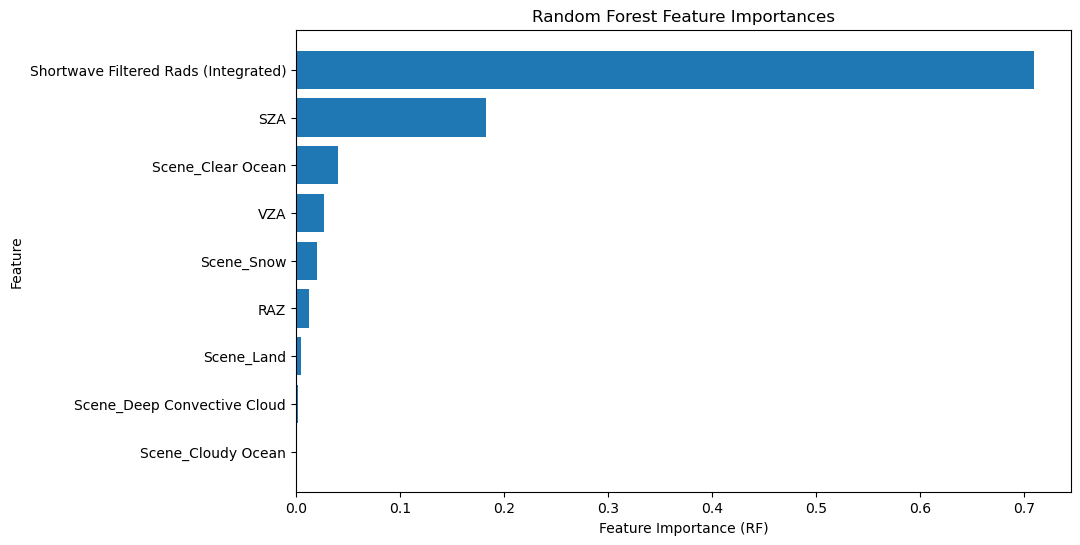

In [124]:
plot_importances(sw_scene_model, input_features + ['Shortwave Filtered Rads (Integrated)'])

In [22]:
lw_scene_model = final_ml_testing(
    dataset=dataset_ohe,
    v=True,
    is_sw=False,
    input_features=input_features + ['Longwave Filtered Rads (Integrated)'],
)

Input features ['SZA', 'VZA', 'RAZ', 'Scene_Clear Ocean', 'Scene_Cloudy Ocean', 'Scene_Deep Convective Cloud', 'Scene_Land', 'Scene_Snow', 'Longwave Filtered Rads (Integrated)']
In train test split: ['SZA', 'VZA', 'RAZ', 'Scene_Clear Ocean', 'Scene_Cloudy Ocean', 'Scene_Deep Convective Cloud', 'Scene_Land', 'Scene_Snow', 'Longwave Filtered Rads (Integrated)']
data sizes
(4940, 44)
(605, 44)
(650, 44)
Train (4940, 9), Val (605, 9), Test (650, 9)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


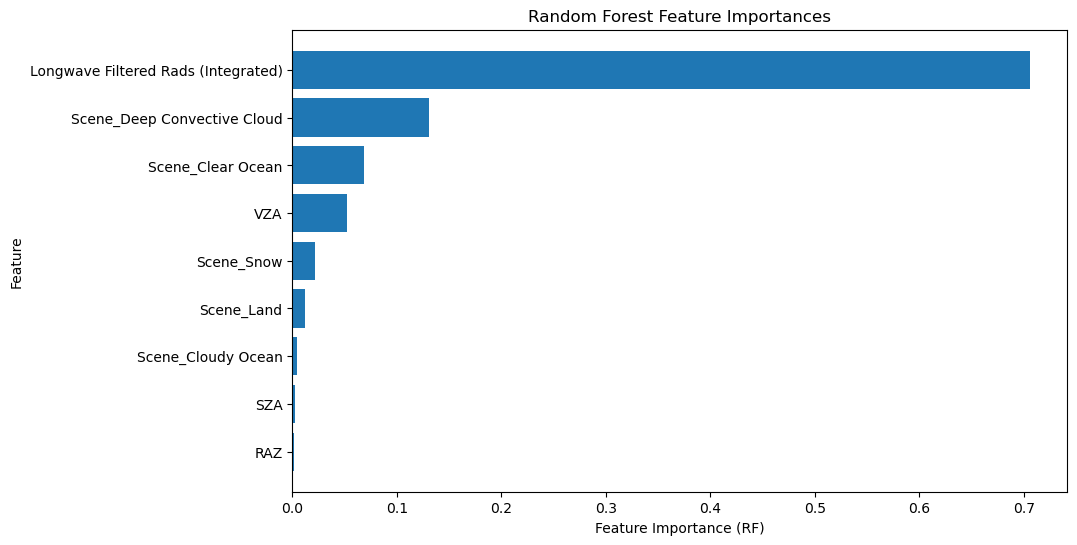

In [123]:
plot_importances(lw_scene_model, input_features + ['Longwave Filtered Rads (Integrated)'])

In [33]:
test_model = final_ml_testing(all_dataset, v=True, is_sw=True, input_features=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)', "Scene_encoded"], use_groups=True)

Input features ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'Scene_encoded']
In train/val/test split: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'Scene_encoded']
data sizes
(4940, 39)
(615, 39)
(640, 39)
Train (4940, 5), Val (615, 5), Test (640, 5)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


In [23]:
sw_model = final_ml_testing(all_dataset, v=True, is_sw=True, input_features=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)', 'M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7'], use_groups=True)

Input features ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7']
In train/val/test split: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7']
data sizes
(4940, 39)
(615, 39)
(640, 39)
Train (4940, 14), Val (615, 14), Test (640, 14)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


In [24]:
lw_model = final_ml_testing(all_dataset, v=True, is_sw=False, input_features=['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)',  'M7', 'M9', 'I2', 'M16'], use_groups=True)

Input features ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M7', 'M9', 'I2', 'M16']
In train test split: ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M7', 'M9', 'I2', 'M16']
data sizes
(4940, 39)
(605, 39)
(650, 39)
Train (4940, 8), Val (605, 8), Test (650, 8)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


In [37]:
plot_importances(sw_model, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)', 'M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7'])

TypeError: plot_importances() takes 1 positional argument but 2 were given

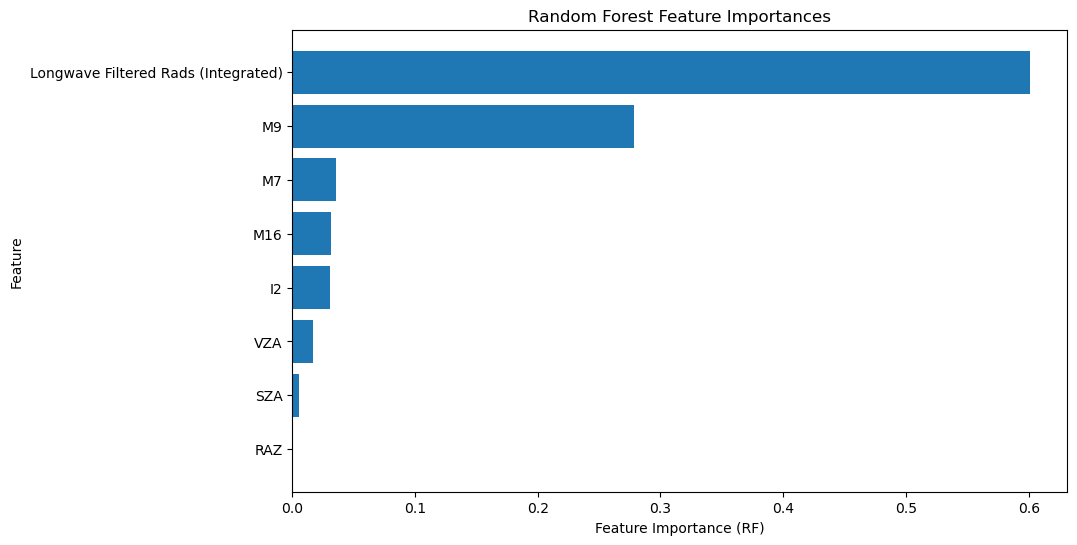

In [60]:
plot_importances(lw_model, ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)',  'M7', 'M9', 'I2', 'M16'])

In [25]:
ssw_model = final_ml_testing(all_dataset, v=True,is_sw=True,input_features=["DNB", "M6", "M5", "M7", "I1", "I2", "Split Shortwave Filtered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)"],  use_groups=True)

Input features ['DNB', 'M6', 'M5', 'M7', 'I1', 'I2', 'Split Shortwave Filtered Rads (Integrated)', 'Shortwave Filtered Rads (Integrated)']
In train/val/test split: ['DNB', 'M6', 'M5', 'M7', 'I1', 'I2', 'Split Shortwave Filtered Rads (Integrated)', 'Shortwave Filtered Rads (Integrated)']
data sizes
(4940, 39)
(615, 39)
(640, 39)
Train (4940, 8), Val (615, 8), Test (640, 8)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


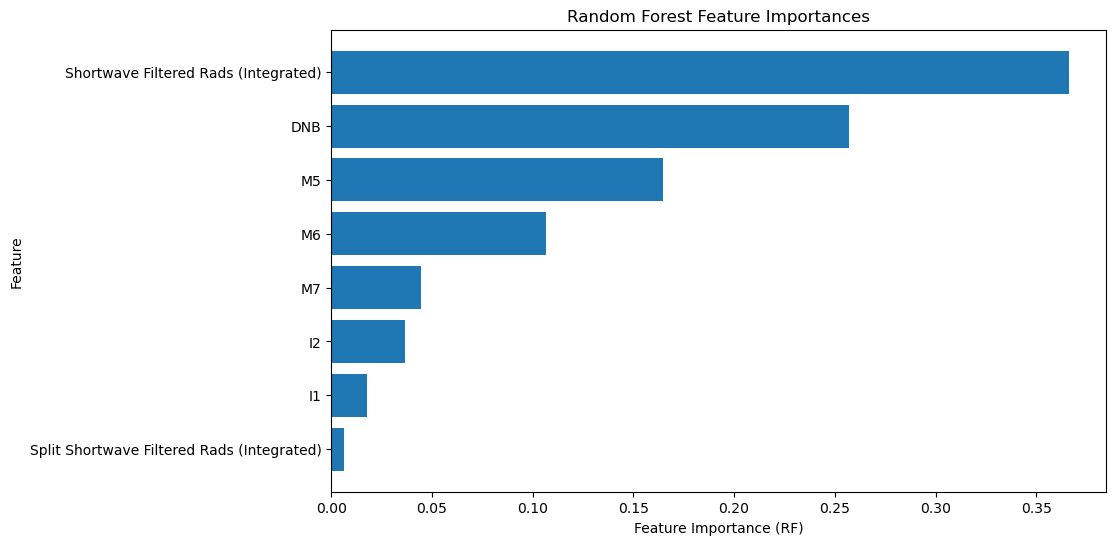

In [99]:
plot_importances(ssw_model, ["DNB", "M6", "M5", "M7", "I1", "I2", "Split Shortwave Filtered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)"])

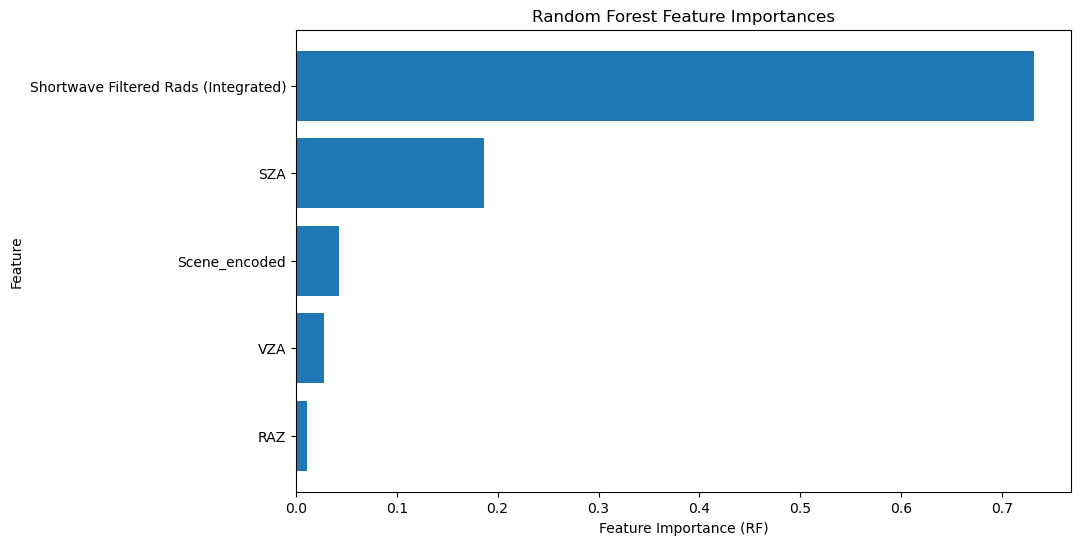

In [106]:
plot_importances(test_model, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)', "Scene_encoded"])

In [105]:
display_model_metrics(test_model)


Validation Metrics:
--------------------------------------------------
RMSE:      1.486308203349527
MAE:       0.7180314807343617
MAPE:      0.9982591530783992%
R²:        0.9997349579095061

Cross-Validation:
--------------------------------------------------
RMSE (mean ± std): 1.8857957001200574 ± 0.3539609571645395
RMSE per fold: ['1.6008919650746993', '2.4889572844567778', '1.6711163823922655', '1.7853857794451786', '1.8826270892313672']

Test Metrics:
--------------------------------------------------
RMSE:      1.0736728274198124
MAE:       0.5919787156844205
MAPE:      0.7932609994582497%
R²:        0.999842657690788


In [95]:
display_model_metrics(ssw_model)


Validation Metrics:
--------------------------------------------------
RMSE:      1.2064743520526138
MAE:       0.6184484688630375
MAPE:      0.9629832497360049%
R²:        0.9998253641966043

Cross-Validation:
--------------------------------------------------
RMSE (mean ± std): 1.3734596872666942 ± 0.13037640642382228
RMSE per fold: ['1.2848468684113403', '1.6036603868716124', '1.3380129583681124', '1.3317467738678197', '1.3090314488145864']

Test Metrics:
--------------------------------------------------
RMSE:      0.9140921485553914
MAE:       0.5385123125230202
MAPE:      0.9983810640244175%
R²:        0.9998859536073486


In [82]:
display_model_metrics(sw_model)


Validation Metrics:
--------------------------------------------------
RMSE:      1.1793342729636618
MAE:       0.5379633269006678
MAPE:      0.6459179006693347%
R²:        0.9998331328154125

Cross-Validation:
--------------------------------------------------
RMSE (mean ± std): 1.3385052074895545 ± 0.21212434805996003
RMSE per fold: ['1.2098247690888857', '1.6461288372830607', '1.4617658761836794', '1.1243984190918208', '1.2504081358003258']

Test Metrics:
--------------------------------------------------
RMSE:      0.780676523350054
MAE:       0.4517163901917768
MAPE:      0.6367274766071%
R²:        0.9999168152272906


In [64]:
display_model_metrics(lw_model)


Validation Metrics:
--------------------------------------------------
RMSE:      0.2901203397437823
MAE:       0.1541241072941492
MAPE:      0.2668988833119472%
R²:        0.9996803943013285

Cross-Validation:
--------------------------------------------------
RMSE (mean ± std): 0.3538165070902677 ± 0.0423174166701772
RMSE per fold: ['0.3674785693081933', '0.35760487158277693', '0.4151660901324332', '0.3075769387402338', '0.32125606568770115']

Test Metrics:
--------------------------------------------------
RMSE:      0.2560156754265157
MAE:       0.11162808956097044
MAPE:      0.18504504001511418%
R²:        0.9997406659884828


In [64]:
df_sw = sw_model["Test_plot_df"]
df_lw = lw_model["Test_plot_df"]

In [66]:
sw_model.keys()

dict_keys(['Regression_val', 'Regression_test', 'Val_RMSE', 'Val_MAE', 'Val_MAPE%', 'Val_R2', 'CV_Fold_RMSEs', 'CV_RMSE_mean', 'CV_RMSE_std', 'ML_test_df', 'Regression_test_df', 'Test_plot_df', 'Test_RMSE', 'Test_MAE', 'Test_MAPE%', 'Test_R2', 'Final_Model', 'Params_Used', 'Train_data', 'Validation_data', 'Test_data'])

In [68]:
sw_model["Regression_test"].keys()

dict_keys(['overall', 'cloud=0', 'cloud=1'])

In [76]:
sw_model["Test_plot_df"].columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)',
       'Split Shortwave Filtered Rads (Integrated)',
       'Total Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5',
       'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12',
       'M13', 'M14', 'M15', 'I5', 'M16', 'Scaled Shortwave Filtered',
       'Scaled Shortwave Unfiltered', 'Scaled Longwave Filtered',
       'Scaled Longwave Unfiltered', 'SW_unf_pred_reg', 'LW_unf_pred_reg',
       'SW_unf_pred_ssw', 'SW_unf_pred_ml'],
      dtype='object')

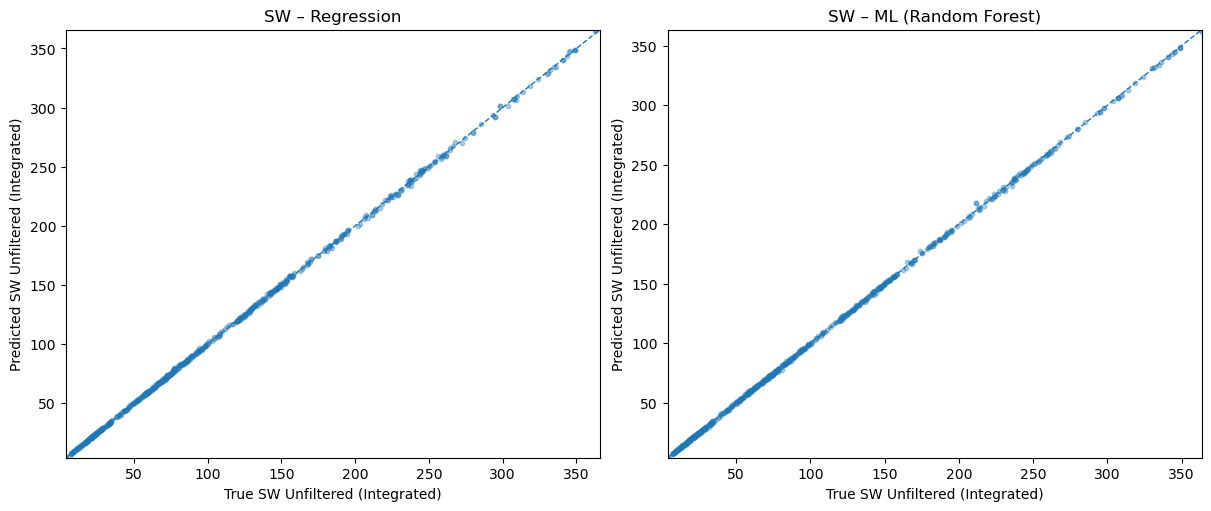

In [75]:
def figure1_true_vs_pred_sw(test_plot_df):
    df = test_plot_df.copy()

    true = df["Shortwave Unfiltered Rads (Integrated)"].to_numpy()
    pred_reg = df["SW_unf_pred_reg"].to_numpy()
    pred_ml  = df["SW_unf_pred_ml"].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    def panel(ax, y_true, y_pred, title):
        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        y_true = y_true[mask]
        y_pred = y_pred[mask]

        ax.scatter(y_true, y_pred, s=10, alpha=0.35)
        lo = min(y_true.min(), y_pred.min())
        hi = max(y_true.max(), y_pred.max())
        ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)

        ax.set_title(title)
        ax.set_xlabel("True SW Unfiltered (Integrated)")
        ax.set_ylabel("Predicted SW Unfiltered (Integrated)")
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

    panel(axes[0], true, pred_reg, "SW – Regression")
    panel(axes[1], true, pred_ml,  "SW – ML (Random Forest)")

    plt.show()

figure1_true_vs_pred_sw(sw_model["Test_plot_df"])

In [ ]:
# def summarize_rmse_r2(ret: dict, is_sw: bool = True) -> pd.DataFrame:
#     """
#     Creates a summary table comparing Regression vs ML
#     using RMSE and R2 on the TEST set.
#     """
#
#     reg = ret["Regression_test"]
#
#     # ML metrics
#     ml_rmse = ret["Test_RMSE"]
#     ml_r2   = ret["Test_R2"]
#
#     rows = []
#
#     # Regression metrics
#     for subset in ["overall", "cloud=0", "cloud=1"]:
#         reg_rmse = reg[subset]["SW_1D"]["RMSE"] if is_sw else reg[subset]["LW_1D"]["RMSE"]
#         reg_r2 = None  # regression R2 not currently computed
#
#         rows.append({
#             "Subset": subset,
#             "Method": "Regression",
#             "RMSE": reg_rmse,
#             "R2": reg_r2
#         })
#
#     # ML only has overall in your current structure
#     rows.append({
#         "Subset": "overall",
#         "Method": "ML (Random Forest)",
#         "RMSE": ml_rmse,
#         "R2": ml_r2
#     })
#
#     df = pd.DataFrame(rows)
#     return df
import pandas as pd
import numpy as np

def overall_rmse_r2_table(ret_sw: dict, ret_lw: dict) -> pd.DataFrame:
    """
    Build an OVERALL-only comparison table for:
      - Regression: SW_1D, SW_SSW, LW_1D
      - ML: SW, LW
    Requires:
      ret_sw from final_ml_testing(..., is_sw=True)
      ret_lw from final_ml_testing(..., is_sw=False)
    Notes:
      - Regression metrics are pulled from ret_*["Regression_test"]["overall"][...]
      - ML metrics are pulled from ret_*["Test_RMSE"], ret_*["Test_R2"]
    """

    reg_sw = ret_sw["Regression_test"]["overall"]
    reg_lw = ret_lw["Regression_test"]["overall"]

    rows = []

    # ---- Regression rows ----
    rows.append({
        "Method": "Regression (SW_1D)",
        "RMSE_SW": reg_sw["SW_1D"].get("RMSE", np.nan),
        "R2_SW":   reg_sw["SW_1D"].get("R2", reg_sw["SW_1D"].get("r2", np.nan)),
        "RMSE_LW": np.nan,
        "R2_LW":   np.nan,
        "n":       reg_sw["SW_1D"].get("n", np.nan),
    })

    rows.append({
        "Method": "Regression (SW_SSW)",
        "RMSE_SW": reg_sw["SW_SSW"].get("RMSE", np.nan),
        "R2_SW":   reg_sw["SW_SSW"].get("R2", reg_sw["SW_SSW"].get("r2", np.nan)),
        "RMSE_LW": np.nan,
        "R2_LW":   np.nan,
        "n":       reg_sw["SW_SSW"].get("n", np.nan),
    })

    rows.append({
        "Method": "Regression (LW_1D)",
        "RMSE_SW": np.nan,
        "R2_SW":   np.nan,
        "RMSE_LW": reg_lw["LW_1D"].get("RMSE", np.nan),
        "R2_LW":   reg_lw["LW_1D"].get("R2", reg_lw["LW_1D"].get("r2", np.nan)),
        "n":       reg_lw["LW_1D"].get("n", np.nan),
    })

    # ---- ML row (overall) ----
    rows.append({
        "Method": "ML (Random Forest)",
        "RMSE_SW": ret_sw.get("Test_RMSE", np.nan),
        "R2_SW":   ret_sw.get("Test_R2", np.nan),
        "RMSE_LW": ret_lw.get("Test_RMSE", np.nan),
        "R2_LW":   ret_lw.get("Test_R2", np.nan),
        "n":       ret_sw["Test_data"]["X_test"].shape[0] if "Test_data" in ret_sw else np.nan,
    })

    df = pd.DataFrame(rows)

    # Optional: nicer column order
    df = df[["Method", "RMSE_SW", "R2_SW", "RMSE_LW", "R2_LW", "n"]]
    return df

In [70]:
lw_model['Regression_test']['overall']

{'SW_1D': {'n': 621,
  'MAE': 0.591578148197707,
  'RMSE': 0.9011696151389379,
  'Bias': 0.0652531535444061,
  'MAPE_%': 0.6364777750098514,
  'R2': 0.9998892342827339},
 'LW_1D': {'n': 621,
  'MAE': 0.06148695464067089,
  'RMSE': 0.08075359202448348,
  'Bias': -0.00807446086780338,
  'MAPE_%': 0.08945212534903216,
  'R2': 0.9999741517622607},
 'SW_SSW': {'n': 621,
  'MAE': 0.19826969979937026,
  'RMSE': 0.281169005968886,
  'Bias': -0.00699818096606049,
  'MAPE_%': 0.26472851278538245,
  'R2': 0.9999892173086251}}

In [71]:
lw_model["Val_RMSE"], lw_model['Val_R2']

(0.2901203397437823, 0.9996803943013285)

In [83]:
sw_model["Val_RMSE"], sw_model["Val_R2"]

(1.1793342729636618, 0.9998331328154125)

In [84]:
sw_model["Test_RMSE"], sw_model["Test_R2"]

(0.780676523350054, 0.9999168152272906)

In [85]:
sw_model['Regression_test']

{'overall': {'SW_1D': {'n': 621,
   'MAE': 0.591578148197707,
   'RMSE': 0.9011696151389379,
   'Bias': 0.0652531535444061,
   'MAPE_%': 0.6364777750098514,
   'R2': 0.9998892342827339},
  'LW_1D': {'n': 621,
   'MAE': 0.06148695464067089,
   'RMSE': 0.08075359202448348,
   'Bias': -0.00807446086780338,
   'MAPE_%': 0.08945212534903216,
   'R2': 0.9999741517622607},
  'SW_SSW': {'n': 621,
   'MAE': 0.19826969979937026,
   'RMSE': 0.281169005968886,
   'Bias': -0.00699818096606049,
   'MAPE_%': 0.26472851278538245,
   'R2': 0.9999892173086251}},
 'cloud=0': {'SW_1D': {'n': 179,
   'MAE': 0.4981673466353873,
   'RMSE': 0.7639826505923953,
   'Bias': 0.08752240895755765,
   'MAPE_%': 1.010309388937226,
   'R2': 0.9998513325278459},
  'LW_1D': {'n': 179,
   'MAE': 0.08590570477048164,
   'RMSE': 0.10976060683488509,
   'Bias': -0.03476819758920979,
   'MAPE_%': 0.10918371195454057,
   'R2': 0.9999260216074456},
  'SW_SSW': {'n': 179,
   'MAE': 0.2033540833499869,
   'RMSE': 0.2865645065845

In [127]:
sw_model["Test_MAPE%"]

0.6367274766071

In [128]:
ssw_model["Test_MAPE%"]

0.47311540913389055

In [129]:
lw_model["Test_MAPE%"]

0.18619588780147137

In [150]:
summary_table = overall_rmse_r2_table(sw_model, lw_model)
summary_table

,Method,RMSE_SW,R2_SW,RMSE_LW,R2_LW,n
0,Regression (SW_1D),0.901170,0.999889,NaN,NaN,621
1,Regression (SW_SSW),0.281169,0.999989,NaN,NaN,621
2,Regression (LW_1D),NaN,NaN,0.080754,0.999974,621
3,ML (Random Forest),0.752507,0.999923,0.336738,0.999551,650


Uncertainty analysis

Look at the RMSE differences plot a table of the RMSEs and the R^2s + Conclusion slide

do masking and check the training set for real training examples

scene classification is huge error so talk about that in the paper that machine learning helps with that

remember to talk about grid search in your paper and how it works, plus for presentation


In [110]:
test_model["Val_RMSE"], test_model["Test_RMSE"]

(1.486308203349527, 1.0736728274198124)

In [73]:
lw_model["Regression_test"].keys()

dict_keys(['overall', 'cloud=0', 'cloud=1', 'standard_df'])

In [ ]:
reg_test_df = lw_model["Regression_test"]["standard_df"]
reg_test_df.columns

In [116]:
lw_model["Test_data"]

{'X_test': array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         4.11220735e-02, 2.09561387e+01, 2.26198127e-04],
        [6.60000000e-02, 3.00000000e+01, 7.50000000e+00, ...,
         1.10109529e+00, 2.35783057e+01, 3.43798140e-03],
        [6.60000000e-02, 3.00000000e+01, 7.50000000e+00, ...,
         1.73099342e-02, 1.85291644e+01, 2.68270957e-03],
        ...,
        [8.56480000e+01, 8.99470000e+01, 3.75000000e+01, ...,
         5.13780322e-02, 5.57775020e+00, 1.36923325e-05],
        [8.49110000e+01, 8.99470000e+01, 9.00000000e+01, ...,
         1.59475797e-02, 2.35511093e+00, 6.74801444e-06],
        [8.38450000e+01, 8.99470000e+01, 1.72500000e+02, ...,
         2.16816129e-02, 4.40291469e+00, 8.89783051e-06]]),
 'y_test': array([ 61.70754173,  53.41280231,  62.88623162,  64.57700783,
         60.6990934 ,  64.57722793,  62.88667394,  53.41279437,
         62.78782572,  65.43072042,  62.88667394,  65.63514055,
         63.31089382,  63.91260721,  63.31104445,  61

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_relative_error(y_true, y_pred, title="Relative Error Distribution"):
    """
    Compute relative error and plot distribution.

    Relative Error = (y_pred - y_true) / y_true

    Parameters
    ----------
    y_true : array-like
    y_pred : array-like
    """

    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    if len(y_true) != len(y_pred):
        raise ValueError("y_true and y_pred must be same length")

    # Avoid divide-by-zero issues
    eps = 1e-12
    safe_true = np.where(np.abs(y_true) < eps, eps, y_true)

    relative_error = (y_pred - y_true) / safe_true

    # ---- Plot ----
    plt.figure(figsize=(10,6))
    plt.hist(relative_error * 100, bins=60)
    plt.axvline(0, linestyle="--")
    plt.xlabel("Relative Error (%)")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()

    # ---- Stats ----
    mean_re = np.nanmean(relative_error)
    median_re = np.nanmedian(relative_error)
    mae_re = np.nanmean(np.abs(relative_error))
    rmse_re = np.sqrt(np.nanmean(relative_error**2))
    std_re = np.nanstd(relative_error)

    print(f"Mean Relative Error: {mean_re*100:.4f}%")
    print(f"Median Relative Error: {median_re*100:.4f}%")
    print(f"Mean Absolute Relative Error: {mae_re*100:.4f}%")
    print(f"RMSE Relative Error: {rmse_re*100:.4f}%")
    print(f"STD Relative Error: {std_re*100:.4f}%")

    return relative_error

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_relative_error(
    y_true,
    y_pred,
    title="Relative Error Distribution",
    plot=True,
    bins=60
):
    """
    Compute relative error and optionally plot distribution.

    Relative Error = (y_pred - y_true) / y_true
    """

    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    if len(y_true) != len(y_pred):
        raise ValueError("y_true and y_pred must be same length")

    eps = 1e-12
    safe_true = np.where(np.abs(y_true) < eps, eps, y_true)

    relative_error = (y_pred - y_true) / safe_true

    # ---- Stats ----
    stats = {
        "mean_signed_percent": np.nanmean(relative_error) * 100,
        "median_signed_percent": np.nanmedian(relative_error) * 100,
        "mean_abs_percent": np.nanmean(np.abs(relative_error)) * 100,
        "rmse_percent": np.sqrt(np.nanmean(relative_error**2)) * 100,
        "std_percent": np.nanstd(relative_error) * 100,
        "p90_abs_percent": np.nanpercentile(np.abs(relative_error), 90) * 100,
        "p95_abs_percent": np.nanpercentile(np.abs(relative_error), 95) * 100,
    }

    # ---- Plot ----
    if plot:
        plt.figure(figsize=(10,6))
        plt.hist(relative_error * 100, bins=bins)
        plt.axvline(0, linestyle="--")
        plt.xlabel("Relative Error (%)")
        plt.ylabel("Count")
        plt.title(title)
        plt.show()

    return relative_error, stats

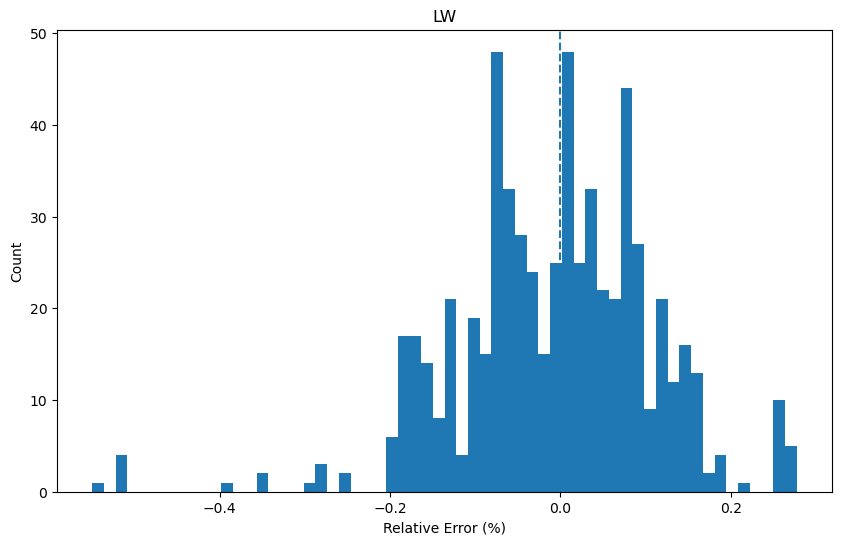

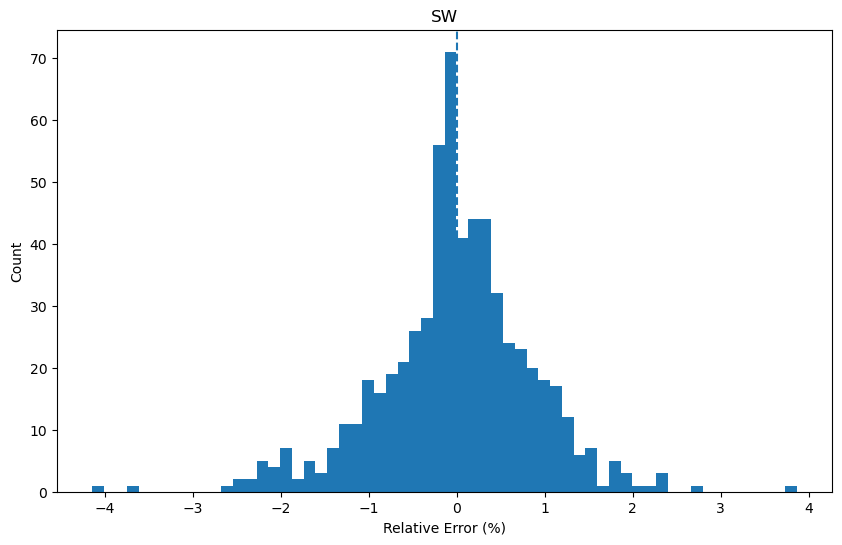

LW: {'mean_signed_percent': -0.008374452539635523, 'median_signed_percent': 0.002989748593973445, 'mean_abs_percent': 0.08945212534903216, 'rmse_percent': 0.11685861799955546, 'std_percent': 0.11655816207124844, 'p90_abs_percent': 0.17264605032160887, 'p95_abs_percent': 0.1934408554843312}
SW: {'mean_signed_percent': -0.01462028493737374, 'median_signed_percent': -0.014473204433021069, 'mean_abs_percent': 0.6364777750098514, 'rmse_percent': 0.8737277382015654, 'std_percent': 0.8736054073614546, 'p90_abs_percent': 1.3644466992622875, 'p95_abs_percent': 1.8957316980775414}


In [39]:
lw_re_trad, lw_stats_trad = analyze_relative_error(reg_test_df['Longwave Unfiltered Rads (Integrated)'], reg_test_df['LW_unf_pred'], "LW")
sw_re_trad, sw_stats_trad = analyze_relative_error(reg_test_df['Shortwave Unfiltered Rads (Integrated)'], reg_test_df['SW_unf_pred'], "SW")

print("LW:", lw_stats_trad)
print("SW:", sw_stats_trad)

In [40]:
sw_ml_test_df = sw_model["ML_test_df"]
lw_ml_test_df = lw_model["ML_test_df"]
lw_model["ML_test_df"].keys()

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)',
       'Split Shortwave Filtered Rads (Integrated)',
       'Total Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5',
       'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12',
       'M13', 'M14', 'M15', 'I5', 'M16', 'Scaled Shortwave Filtered',
       'Scaled Shortwave Unfiltered', 'Scaled Longwave Filtered',
       'Scaled Longwave Unfiltered', 'Scene_encoded', 'LW_unf_pred_ml'],
      dtype='object')

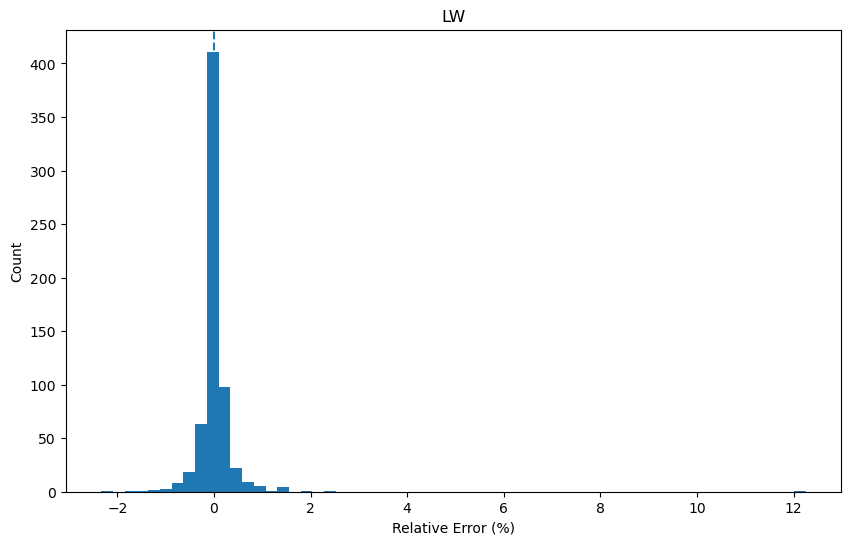

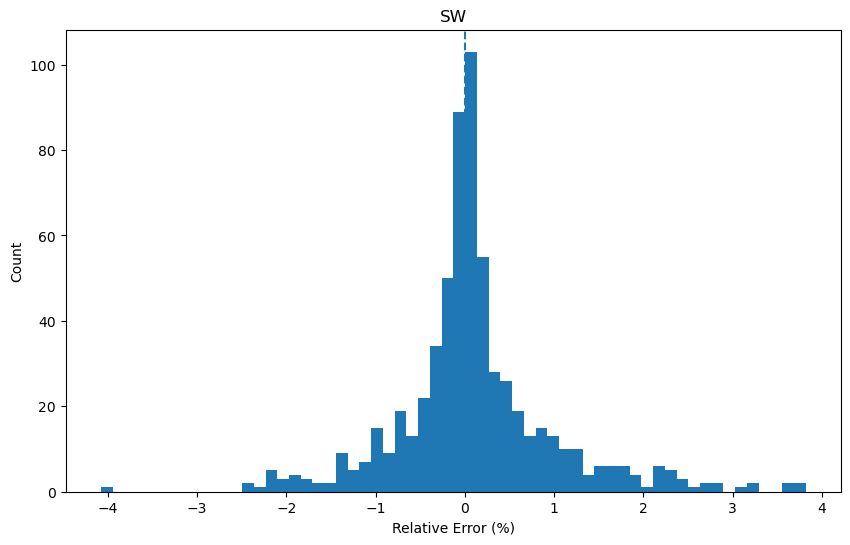

LW: {'mean_signed_percent': -0.008374452539635523, 'median_signed_percent': 0.002989748593973445, 'mean_abs_percent': 0.08945212534903216, 'rmse_percent': 0.11685861799955546, 'std_percent': 0.11655816207124844, 'p90_abs_percent': 0.17264605032160887, 'p95_abs_percent': 0.1934408554843312}
SW: {'mean_signed_percent': -0.01462028493737374, 'median_signed_percent': -0.014473204433021069, 'mean_abs_percent': 0.6364777750098514, 'rmse_percent': 0.8737277382015654, 'std_percent': 0.8736054073614546, 'p90_abs_percent': 1.3644466992622875, 'p95_abs_percent': 1.8957316980775414}


In [41]:
lw_re_ml, lw_stats_ml = analyze_relative_error(lw_ml_test_df['Longwave Unfiltered Rads (Integrated)'], lw_ml_test_df['LW_unf_pred_ml'], "LW")
sw_re_ml, sw_stats_ml = analyze_relative_error(sw_ml_test_df['Shortwave Unfiltered Rads (Integrated)'], sw_ml_test_df['SW_unf_pred_ml'], "SW")

print("LW:", lw_stats_trad)
print("SW:", sw_stats_trad)

In [83]:
ssw_model.keys()

dict_keys(['Regression_val', 'Regression_test', 'GridSearch', 'Val_RMSE', 'Val_MAE', 'Val_MAPE%', 'Val_R2', 'CV_Fold_RMSEs', 'CV_RMSE_mean', 'CV_RMSE_std', 'ML_test_df', 'Regression_test_df', 'Test_plot_df', 'Test_RMSE', 'Test_MAE', 'Test_MAPE%', 'Test_R2', 'Final_Model', 'Params_Used', 'Train_data', 'Validation_data', 'Test_data'])

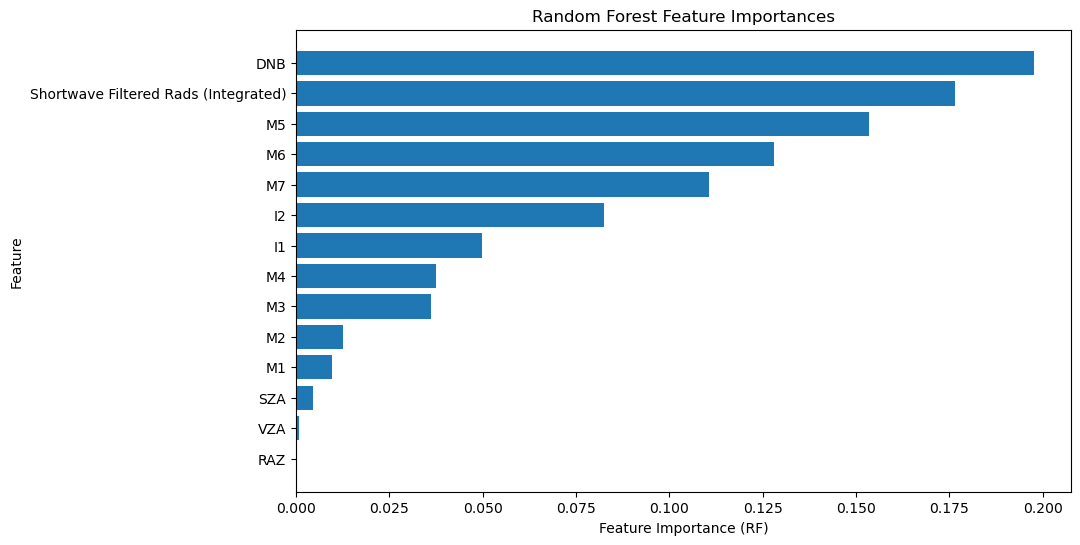

In [24]:
plot_importances(sw_model, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)', 'M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7'])

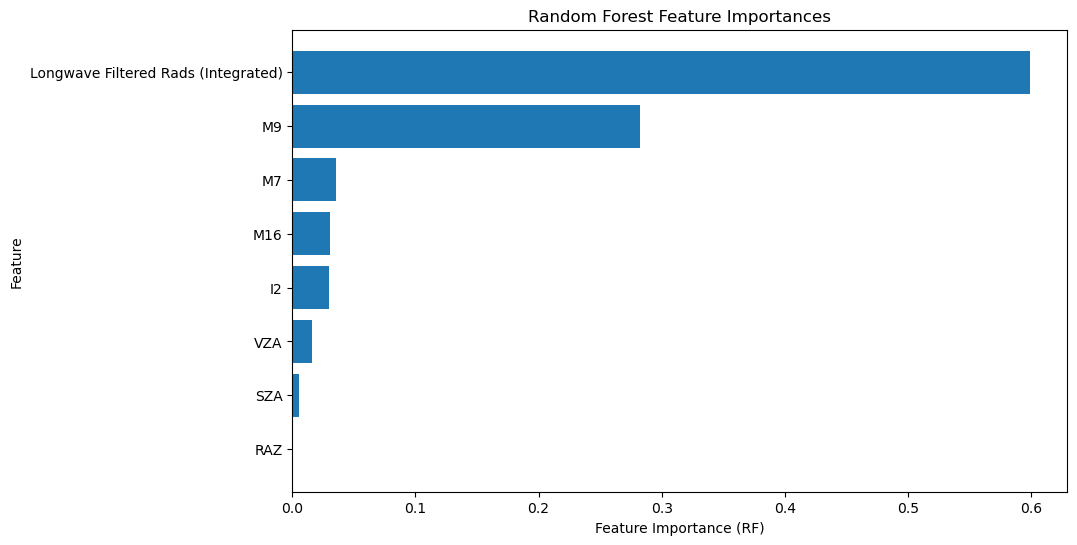

In [26]:
plot_importances(lw_model, ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)',  'M7', 'M9', 'I2', 'M16'])

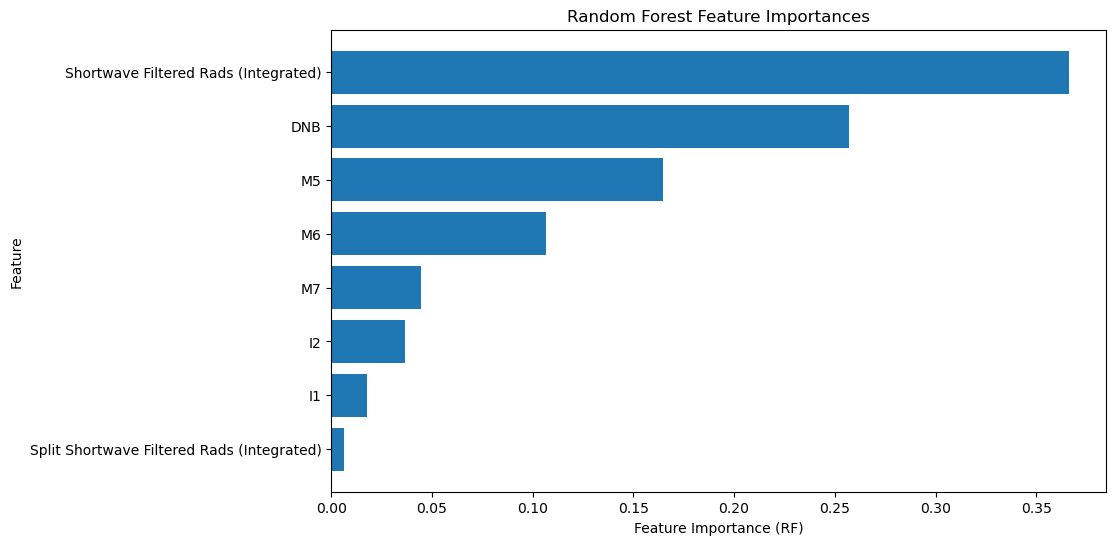

In [28]:
plot_importances(ssw_model, ["DNB", "M6", "M5", "M7", "I1", "I2", "Split Shortwave Filtered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)"])

In [26]:
sw_everything_model = final_ml_testing(all_dataset, v=True, is_sw=True, input_features=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)','M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9','I3','M10','M11','I4','M12','M13','M14','M15','I5','M16', "Scene_encoded"], use_groups=True)

Input features ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Scene_encoded']
In train/val/test split: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Scene_encoded']
data sizes
(4940, 39)
(615, 39)
(640, 39)
Train (4940, 27), Val (615, 27), Test (640, 27)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


In [ ]:
plot_importances(sw_everything_model, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)','M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9','I3','M10','M11','I4','M12','M13','M14','M15','I5','M16', "Scene_encoded"])

In [27]:
lw_everything_model = final_ml_testing(all_dataset, v=True, is_sw=False, input_features=['SZA', 'VZA', 'RAZ','Longwave Filtered Rads (Integrated)','M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9','I3','M10','M11','I4','M12','M13','M14','M15','I5','M16', "Scene_encoded"], use_groups=True)

Input features ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Scene_encoded']
In train test split: ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Scene_encoded']
data sizes
(4940, 39)
(605, 39)
(650, 39)
Train (4940, 27), Val (605, 27), Test (650, 27)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


In [ ]:
plot_importances(lw_everything_model, ['SZA', 'VZA', 'RAZ','Longwave Filtered Rads (Integrated)','M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9','I3','M10','M11','I4','M12','M13','M14','M15','I5','M16', "Scene_encoded"])

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

input_features = ['SZA', 'VZA', 'RAZ','Longwave Filtered Rads (Integrated)','M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9','I3','M10','M11','I4','M12','M13','M14','M15','I5','M16', "Scene_encoded"]
X_pca = all_dataset[input_features]
X_pca = X_pca.dropna()

scaler = StandardScaler()
X_scaled_pca = scaler.fit_transform(X_pca)

pca = PCA()
X_pca = pca.fit_transform(X_scaled_pca)

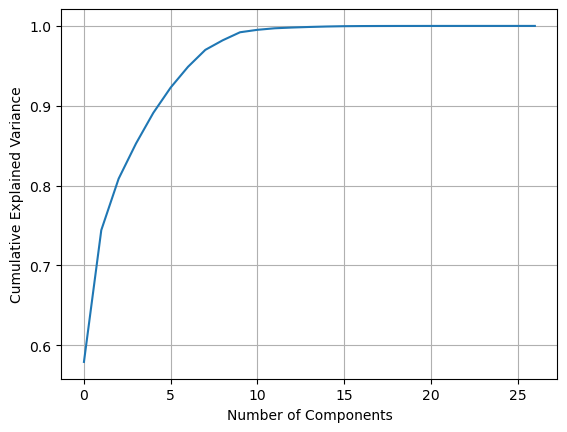

In [48]:
import matplotlib.pyplot as plt

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

In [50]:
band_cols = ['M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9','I3','M10','M11','I4','M12','M13','M14','M15','I5','M16',]
X_bands = all_dataset[band_cols]

scaler = StandardScaler()
X_scaled_bands = scaler.fit_transform(X_bands)

pca_bands = PCA()
pca_bands.fit(X_scaled_bands)

loadings = pca_bands.components_
explained = pca_bands.explained_variance_ratio_

band_importance = np.sum(
    np.abs(loadings.T) * explained,
    axis=1
)

pca_importance_df = pd.DataFrame({
    "Band": band_cols,
    "PCA_Importance": band_importance
}).sort_values("PCA_Importance", ascending=False)

print(pca_importance_df)

   Band  PCA_Importance
15   I4        0.211515
12   I3        0.211092
13  M10        0.211092
16  M12        0.210759
20   I5        0.209292
14  M11        0.208509
18  M14        0.208507
19  M15        0.206544
17  M13        0.206436
3    M4        0.205929
7    M6        0.205770
21  M16        0.205553
2    M3        0.204824
1    M2        0.204192
4    I1        0.204070
5    M5        0.203894
6   DNB        0.203341
0    M1        0.203331
8    I2        0.203205
9    M7        0.203205
10   M8        0.199699
11   M9        0.157701


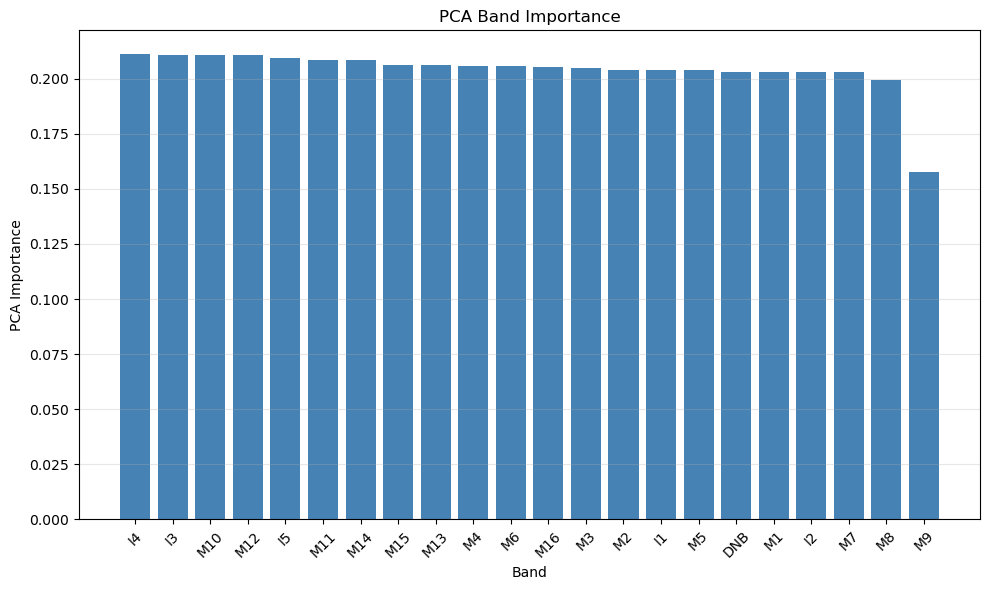

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_pca_band_importance(
    pca_importance_df: pd.DataFrame,
    normalize: bool = True,
    figsize: tuple = (10, 6),
    title: str = "PCA Band Importance",
    color: str = "steelblue"
):
    """
    Plot PCA-derived band importance scores.

    Parameters
    ----------
    pca_importance_df : pd.DataFrame
        Must contain columns:
            - 'Band'
            - 'PCA_Importance'
    normalize : bool
        If True, normalize importance to sum to 1.
    figsize : tuple
        Matplotlib figure size.
    title : str
        Plot title.
    color : str
        Bar color.
    """

    df = pca_importance_df.copy()
    df = df.sort_values("PCA_Importance", ascending=False)

    values = df["PCA_Importance"].values

    if normalize:
        values = values / np.sum(values)

    plt.figure(figsize=figsize)
    bars = plt.bar(df["Band"], values, color=color)

    plt.xlabel("Band")
    plt.ylabel("Normalized Importance" if normalize else "PCA Importance")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_pca_band_importance(pca_importance_df, False)

In [53]:
sw_everything_model.keys()

dict_keys(['Regression_val', 'Regression_test', 'GridSearch', 'Val_RMSE', 'Val_MAE', 'Val_MAPE%', 'Val_R2', 'CV_Fold_RMSEs', 'CV_RMSE_mean', 'CV_RMSE_std', 'ML_test_df', 'Regression_test_df', 'Test_plot_df', 'Test_RMSE', 'Test_MAE', 'Test_MAPE%', 'Test_R2', 'Final_Model', 'Params_Used', 'Train_data', 'Validation_data', 'Test_data'])

In [55]:
sw_everything_model["Test_data"].keys()

dict_keys(['X_test', 'y_test', 'meta_test', 'idxs'])

In [56]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    sw_everything_model["Final_Model"],
    sw_everything_model["Test_data"]['X_test'],
    sw_everything_model["Test_data"]['y_test'],
    n_repeats=10,
    random_state=42
)

In [57]:
result

{'importances_mean': array([2.02122323e-05, 3.99145901e-06, 2.19178079e-06, 8.00800750e-02,
        3.98574151e-04, 1.10404479e-03, 2.39265321e-03, 1.54363106e-03,
        7.09783775e-03, 2.21831260e-02, 4.59428139e-02, 1.23237812e-02,
        6.71728567e-03, 6.27409270e-03, 4.29338991e-04, 2.42291367e-05,
        4.65303329e-05, 4.41842443e-05, 4.81799464e-05, 3.26274713e-05,
        1.64455087e-05, 3.11119904e-05, 4.31348085e-05, 1.70064940e-05,
        1.80014722e-05, 1.09778235e-05, 1.35309566e-06]),
 'importances_std': array([2.01434443e-06, 6.65493293e-07, 3.27341075e-07, 2.14865385e-03,
        1.24604877e-05, 4.15522275e-05, 4.40267238e-05, 5.88630527e-05,
        3.05105674e-04, 7.14289502e-04, 1.22480796e-03, 4.46914202e-04,
        3.04164098e-04, 2.70342047e-04, 1.80283875e-05, 2.68985027e-06,
        2.77433530e-06, 2.53968140e-06, 3.39444765e-06, 4.89205400e-06,
        2.65138611e-06, 3.41461132e-06, 3.50845035e-06, 1.36872095e-06,
        1.85148661e-06, 9.86846016e-07,

In [63]:
pca_importance_df = pca_importance_df.sort_values("PCA_Importance", ascending=False)
top5_pca = pca_importance_df.head(5)["Band"].tolist()
features_pca = top5_pca + [
    "SZA",
    "VZA",
    "RAZ",
    "Shortwave Filtered Rads (Integrated)"
]
sw_pca_model = final_ml_testing(all_dataset, v=True, is_sw=True, input_features=features_pca, use_groups=True)

Input features ['I4', 'I3', 'M10', 'M12', 'I5', 'SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)']
In train test split: ['I4', 'I3', 'M10', 'M12', 'I5', 'SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)']
Train (4940, 9), Val (605, 9), Test (650, 9)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


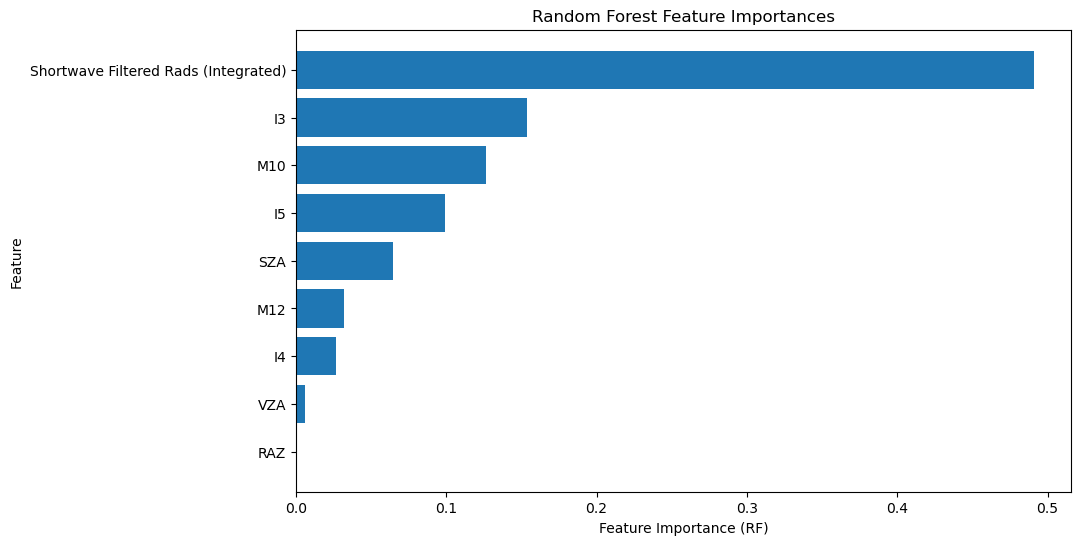

In [64]:
plot_importances(sw_pca_model, features_pca)

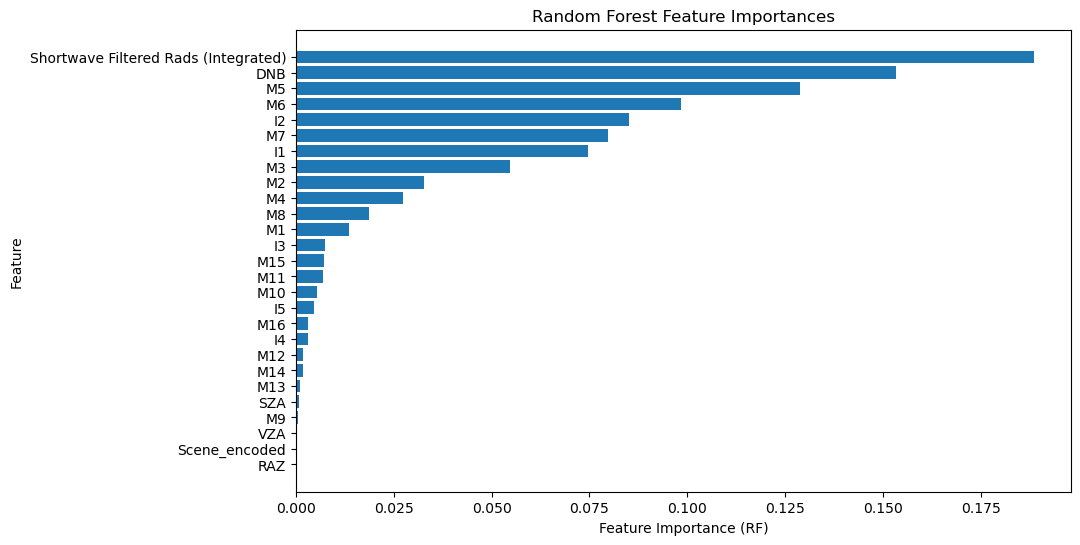

In [67]:
plot_importances(sw_everything_model, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)','M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9','I3','M10','M11','I4','M12','M13','M14','M15','I5','M16', "Scene_encoded"])

In [68]:
display_model_metrics(sw_everything_model)


Validation Metrics:
--------------------------------------------------
RMSE:      0.8935841682408482
MAE:       0.3784928262563594
MAPE:      0.5110232310906903%
R²:        0.999904199443871

Cross-Validation:
--------------------------------------------------
RMSE (mean ± std): 1.0184784571679262 ± 0.28285602814909516
RMSE per fold: ['0.9465522925953649', '1.4921643117971874', '1.0289392747875308', '0.760377019291381', '0.8643593873681662']

Test Metrics:
--------------------------------------------------
RMSE:      0.5195710577870702
MAE:       0.3019441257491279
MAPE:      0.49072292337261486%
R²:        0.999963153902432


In [69]:
display_model_metrics(sw_pca_model)


Validation Metrics:
--------------------------------------------------
RMSE:      1.3114529678878415
MAE:       0.7092168230575994
MAPE:      1.0482220648259863%
R²:        0.9997936509188681

Cross-Validation:
--------------------------------------------------
RMSE (mean ± std): 1.9409424750730615 ± 0.6589280259033263
RMSE per fold: ['1.8734139093853281', '3.0570024583888924', '1.8744131953064256', '1.451413698935199', '1.4484691133494625']

Test Metrics:
--------------------------------------------------
RMSE:      1.194922140356103
MAE:       0.7040788053562346
MAPE:      1.1329788577156288%
R²:        0.9998051139237593


In [28]:
sw_all_channels_model = final_ml_testing(all_dataset, v=True, is_sw=True, input_features=['Shortwave Filtered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ'], use_groups=True)

Input features ['Shortwave Filtered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ']
In train/val/test split: ['Shortwave Filtered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ']
data sizes
(4940, 39)
(615, 39)
(640, 39)
Train (4940, 7), Val (615, 7), Test (640, 7)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


In [73]:
display_model_metrics(sw_all_channels_model)


Validation Metrics:
--------------------------------------------------
RMSE:      0.992873195057005
MAE:       0.4804614683693214
MAPE:      0.7434307352850893%
R²:        0.9998817272565326

Cross-Validation:
--------------------------------------------------
RMSE (mean ± std): 1.085893021990517 ± 0.26272324571689865
RMSE per fold: ['0.9782506257363133', '1.543641964513709', '1.025765416301515', '0.8726620190689864', '1.0091450843320606']

Test Metrics:
--------------------------------------------------
RMSE:      0.6310496181042465
MAE:       0.38741110259566375
MAPE:      0.689224966041856%
R²:        0.9999456463626967


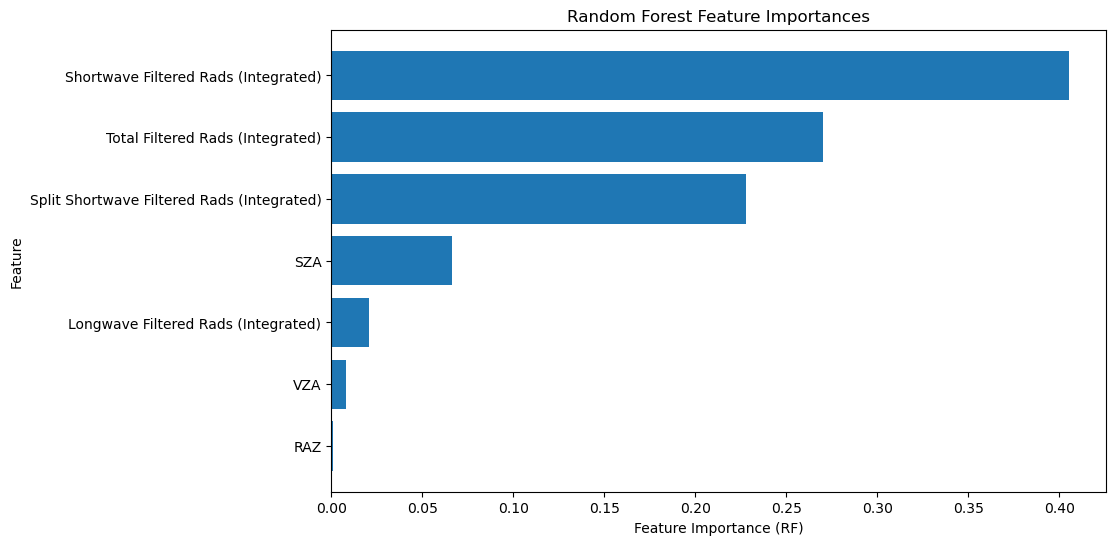

In [74]:
plot_importances(sw_all_channels_model, ['Shortwave Filtered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ'])

In [ ]:
y_lim_map = {
    "Snow": [[1.75e-6, 4], [1e-5, 100]],
    "Cloudy Ocean": [[2.25e-6, 5], [1e-5, 100]],
    "Land": [[600, 3], [10, 50]],
    "Clear Ocean": [[7e-7, 3], [1.75e-5, 100]],
    "Deep Convective Cloud": [[500, 3], [2.5, 80]]
}

def plot_sza(sza_dict: dict):
    fig, axes = plt.subplots(5, 1, figsize=(18, 50))

    for i, (key, tp7) in enumerate(sza_dict.items()):

        wavelength = tp7.rads[0, 0, :]

        print(key)
        ax_sw = axes[i]
        shortwave = tp7.rads[-1, 1, :]
        interp_shortwave_filt = np.interp(x=wavelength, xp=tot_wvln, fp=sw_srf)
        shortwave_filt = interp_shortwave_filt * shortwave

        ax_sw.plot(wavelength, shortwave_filt, 'r-', label='Filtered')
        ax_sw.plot(wavelength, shortwave, 'b-', label='Unfiltered')
        # ax_sw.set_xlim(0, y_lim_map[key][0][1])
        # ax_sw.set_ylim(0, y_lim_map[key][0][0])
        ax_sw.set_xlim(0, y_lim_map["Land"][0][1])
        ax_sw.set_ylim(0, y_lim_map["Land"][0][0])

        ax_sw.legend(prop={"size": 10})
        ax_sw.set_title(f'Shortwave: {key}')
        ax_sw.set_ylabel('Radiance Wm$^{-2}$µm$^{-1}$sr$^{-1}$')
        ax_sw.set_xlabel('Wavelength µm')
        ax_sw.grid(True)


        # ax_lw = axes[i, 1]
        # longwave = tp7.rads[-1, 2, :]
        # longwave_filt = np.interp(x=wavelength, xp=tot_wvln, fp=lw_srf)
        # longwave_filt = longwave_filt * shortwave
        # ax_lw.plot(wavelength, longwave, longwave_filt, 'b-', label='Longwave')
        # ax_lw.set_xlim(5, y_lim_map[key][1][1])
        # ax_lw.set_ylim(0, y_lim_map[key][1][0])
        #
        # ax_lw.legend(prop={"size": 10})
        # ax_lw.set_title(f'Longwave: {key}')
        # ax_lw.set_ylabel('Radiance Wm$^{-2}$µm$^{-1}$sr$^{-1}$')
        # ax_lw.set_xlabel('Wavelength µm')
        # ax_lw.grid(True)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4)
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_full_spectrum(
    tape7_obj,
    run_index=0,
    save_path="full_spectrum.png",
    dpi=600
):
    """
    Plot full TOA spectral radiance (SW + LW) vs wavelength.

    Parameters
    ----------
    tape7_obj : Tape7
        Initialized Tape7 object
    run_index : int
        Which MODTRAN run to plot
    save_path : str
        File path to save image
    dpi : int
        Resolution for saved figure
    """

    # Ensure radiances computed
    tape7_obj._compute_radiences()

    # Extract data
    run = tape7_obj.rads[run_index]
    wavelength = run[0]        # microns
    sw_rad = run[1]
    lw_rad = run[2]

    total_rad = sw_rad + lw_rad

    # Remove any negative or zero wavelengths
    mask = wavelength > 0
    wavelength = wavelength[mask]
    total_rad = total_rad[mask]

    # Create plot
    plt.figure(figsize=(8, 5))
    plt.plot(wavelength, total_rad, linewidth=1.5)

    plt.xscale("log")
    plt.xlabel("Wavelength (μm)")
    plt.ylabel("Radiance (W m$^{-2}$ sr$^{-1}$ μm$^{-1}$)")
    plt.title("Top-of-Atmosphere Spectral Radiance")

    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.close()

    print(f"Saved figure to {save_path}")

In [35]:
all_dataset.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)',
       'Split Shortwave Filtered Rads (Integrated)',
       'Total Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5',
       'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12',
       'M13', 'M14', 'M15', 'I5', 'M16', 'Scaled Shortwave Filtered',
       'Scaled Shortwave Unfiltered', 'Scaled Longwave Filtered',
       'Scaled Longwave Unfiltered', 'Scene_encoded'],
      dtype='object')

In [37]:
land_plot = plot_full_spectrum(a00["Land"])

Saved figure to full_spectrum.png


In [38]:
a00

{'Snow': <tp7.tp7.Tape7 at 0x326ebbfd0>,
 'Land': <tp7.tp7.Tape7 at 0x32a257390>,
 'Clear Ocean': <tp7.tp7.Tape7 at 0x329c3c450>,
 'Cloudy Ocean': <tp7.tp7.Tape7 at 0x32a23e650>,
 'Deep Convective Cloud': <tp7.tp7.Tape7 at 0x32c9ad3d0>}

In [64]:
import matplotlib.pyplot as plt
import numpy as np

def plot_multi_scene_spectra(
    scene_dict: dict,
    run_index: int = 0,
    save_path: str = "multi_scene_spectra.png",
    dpi: int = 600
):
    """
    Plot total TOA spectral radiance (SW + LW) for one run from each scene
    on a single log-wavelength plot.

    Parameters
    ----------
    scene_dict : dict
        Dictionary of {scene_name: Tape7_object}
    run_index : int
        Which run to plot from each Tape7 object
    save_path : str
        Path to save the image
    dpi : int
        Image resolution
    """

    plt.figure(figsize=(8, 5))

    for scene_name, tp7_obj in scene_dict.items():

        # Ensure radiances computed
        # tp7_obj._compute_radiences()

        run = tp7_obj.rads[run_index]

        wavelength = run[0]
        sw_rad = run[1]
        lw_rad = run[2]

        total_rad = sw_rad + lw_rad

        # Remove invalid wavelengths
        mask = wavelength > 0
        wavelength = wavelength[mask]
        total_rad = total_rad[mask]

        plt.plot(
            wavelength,
            total_rad,
            linewidth=1.5,
            label=scene_name
        )

    plt.xscale("log")
    plt.xlabel("Wavelength (μm)")
    plt.ylabel("Radiance (W m$^{-2}$ sr$^{-1}$ μm$^{-1}$)")
    plt.title("SZA 0.0 Top-of-Atmosphere Spectral Radiance")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.close()

    print(f"Saved figure to {save_path}")

plot_multi_scene_spectra(a00)

Saved figure to multi_scene_spectra.png


In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_stratified_split_distribution(
    dataset,
    train_idx,
    val_idx,
    test_idx,
    save_path="stratified_split.png",
    dpi=600
):
    """
    Plot grouped bar chart showing scene distribution across
    train/validation/test splits.
    """

    # Subsets
    train_df = dataset.iloc[train_idx]
    val_df = dataset.iloc[val_idx]
    test_df = dataset.iloc[test_idx]

    print("data sizes")
    print(train_df.shape)
    print(val_df.shape)
    print(test_df.shape)

    # Scene counts
    train_counts = train_df["Scene"].value_counts().sort_index()
    val_counts = val_df["Scene"].value_counts().sort_index()
    test_counts = test_df["Scene"].value_counts().sort_index()

    scenes = train_counts.index

    x = np.arange(len(scenes))
    width = 0.25

    plt.figure(figsize=(8, 5))

    plt.bar(x - width, train_counts, width, label="Train")
    plt.bar(x, val_counts, width, label="Validation")
    plt.bar(x + width, test_counts, width, label="Test")

    plt.xticks(x, scenes, rotation=30)
    plt.ylabel("Number of Samples")
    plt.title("Stratified Dataset Split by Scene Type")
    plt.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.close()

    print(f"Saved to {save_path}")

plot_stratified_split_distribution(all_dataset, sw_model["Train_data"]["idxs"], sw_model["Validation_data"]["idxs"], sw_model["Test_data"]["idxs"])

data sizes
(4940, 39)
(605, 39)
(650, 39)
Saved to stratified_split.png


In [51]:
sw_model.keys()

dict_keys(['Regression_val', 'Regression_test', 'GridSearch', 'Val_RMSE', 'Val_MAE', 'Val_MAPE%', 'Val_R2', 'CV_Fold_RMSEs', 'CV_RMSE_mean', 'CV_RMSE_std', 'ML_test_df', 'Regression_test_df', 'Test_plot_df', 'Test_RMSE', 'Test_MAE', 'Test_MAPE%', 'Test_R2', 'Final_Model', 'Params_Used', 'Train_data', 'Validation_data', 'Test_data'])

In [52]:
sw_model["Train_data"].keys()

dict_keys(['X_tr', 'y_tr', 'meta_tr', 'idxs'])

In [178]:
def plot_feature_importance(
    model,
    title,
    sw,
    feature_names,
    save_path="feature_importance.png",
    dpi=600
):
    """
    Plot feature importance from trained Random Forest.
    """

    importances = model['Final_Model'].feature_importances_
    indices = np.argsort(importances)

    plt.figure(figsize=(8, 5))

    plt.barh(range(len(indices)), importances[indices])
    plt.yticks(range(len(indices)), np.array(feature_names)[indices])

    plt.xlabel("Feature Importance")
    plt.title(title)

    plt.tight_layout()
    plt.savefig(f"./imgs/{sw}_feature_importance.png", dpi=dpi, bbox_inches="tight")
    plt.close()

    print(f"Saved to {save_path}")

In [180]:
plot_feature_importance(sw_model, "Shortwave Model Feature Importance", "sw", ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)', 'M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7'])

Saved to feature_importance.png


In [181]:
plot_feature_importance(lw_model, "Longwave Model Feature Importance", "lw", ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)',  'M7', 'M9', 'I2', 'M16'])

Saved to feature_importance.png


In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_split_spread_scatter(
    df: pd.DataFrame,
    tr_idx,
    val_idx,
    te_idx,
    x_col: str,
    y_col: str,
    title: str | None = None,
    alpha: float = 0.5,
    s: float = 14,
    use_log: bool = False,
):
    """
    Scatter plot of dataset spread colored by train/val/test.

    Common choice:
      x_col = "Shortwave Filtered Rads (Integrated)"
      y_col = "Shortwave Unfiltered Rads (Integrated)"
    """

    # Ensure indices are numpy arrays
    tr_idx = np.asarray(tr_idx)
    val_idx = np.asarray(val_idx)
    te_idx = np.asarray(te_idx)
    print("Idx shapes")
    print(np.shape(tr_idx), np.shape(val_idx), np.shape(te_idx))

    # Helper: clean NaNs/infs consistently per split
    def _get_xy(idxs):
        sub = df.iloc[idxs]
        print("df shape")
        print(sub.shape)
        x = pd.to_numeric(sub[x_col], errors="coerce").to_numpy()
        y = pd.to_numeric(sub[y_col], errors="coerce").to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        return x[m], y[m]

    x_tr, y_tr = _get_xy(tr_idx)
    x_val, y_val = _get_xy(val_idx)
    x_te, y_te = _get_xy(te_idx)

    plt.figure(figsize=(9, 7))
    plt.scatter(x_tr,  y_tr,  label=f"Train (n={len(x_tr)})", alpha=alpha, s=s)
    plt.scatter(x_val, y_val, label=f"Val (n={len(x_val)})",  alpha=alpha, s=s)
    plt.scatter(x_te,  y_te,  label=f"Test (n={len(x_te)})", alpha=alpha, s=s)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title or f"Dataset spread by split: {y_col} vs {x_col}")
    plt.legend()

    if use_log:
        plt.xscale("log")
        plt.yscale("log")

    # Optional: show y=x line for reference (only meaningful if x,y comparable units)
    # lo = min(np.min(x_tr), np.min(x_val), np.min(x_te), np.min(y_tr), np.min(y_val), np.min(y_te))
    # hi = max(np.max(x_tr), np.max(x_val), np.max(x_te), np.max(y_tr), np.max(y_val), np.max(y_te))
    # plt.plot([lo, hi], [lo, hi], linestyle="--")

    _ = x_col.split(" ")
    print(_)
    wv = "SW" if _[0] == "Shortwave" else "LW"
    plt.savefig(f"./imgs/{wv}_data_coverage", dpi=600, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

In [101]:
lw_model['Train_data'].keys()

dict_keys(['X_tr', 'y_tr', 'meta_tr', 'idxs'])

In [ ]:
sw_train_idx, sw_val_idx, sw_test_idx = sw_model["Train_data"]["idxs"], sw_model["Validation_data"]["idxs"], sw_model["Test_data"]["idxs"]
lw_train_idx, lw_val_idx, lw_test_idx = lw_model["Train_data"]["idxs"], lw_model["Validation_data"]["idxs"], lw_model["Test_data"]["idxs"]

Idx shapes
(4940,) (615,) (640,)
df shape
(4940, 39)
df shape
(615, 39)
df shape
(640, 39)
['Shortwave', 'Filtered', 'Rads', '(Integrated)']


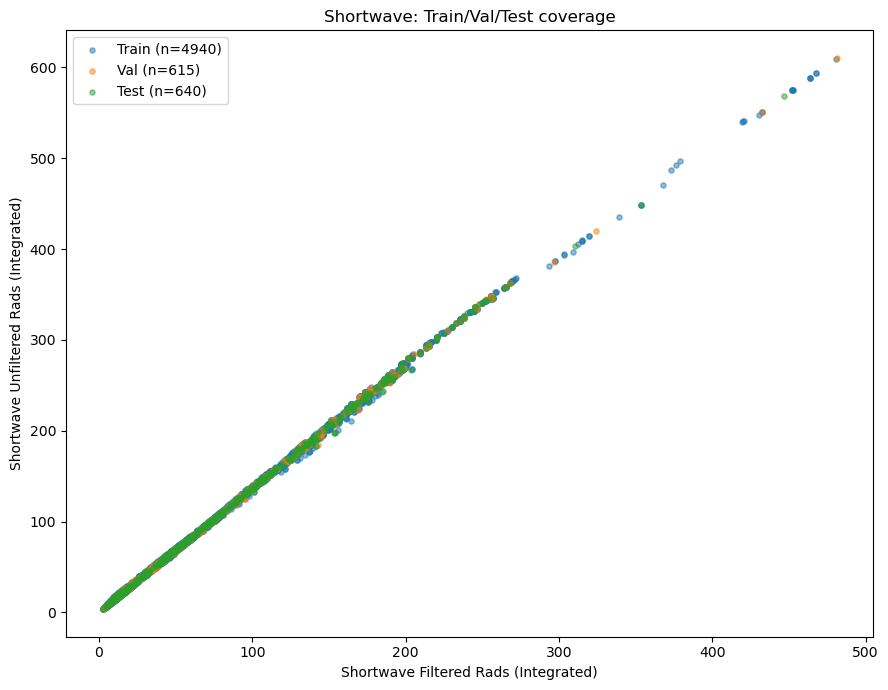

In [176]:
plot_split_spread_scatter(
    df=all_dataset,
    tr_idx=sw_train_idx,
    val_idx=sw_val_idx,
    te_idx=sw_test_idx,
    x_col="Shortwave Filtered Rads (Integrated)",
    y_col="Shortwave Unfiltered Rads (Integrated)",
    title="Shortwave: Train/Val/Test coverage",
)

Idx shapes
(4940,) (605,) (650,)
df shape
(4940, 39)
df shape
(605, 39)
df shape
(650, 39)


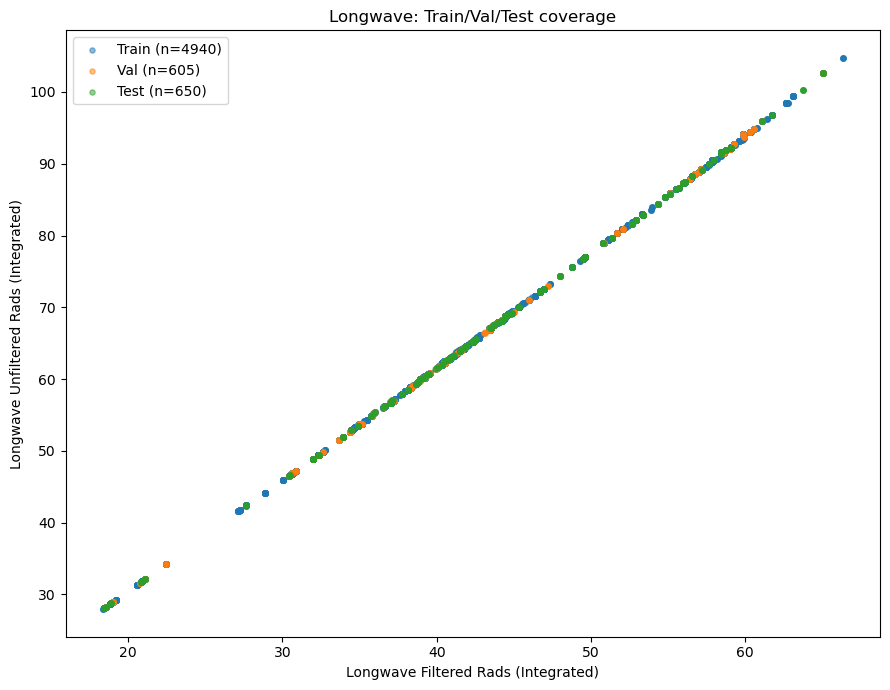

In [104]:
plot_split_spread_scatter(
    df=all_dataset,
    tr_idx=lw_train_idx,
    val_idx=lw_val_idx,
    te_idx=lw_test_idx,
    x_col="Longwave Filtered Rads (Integrated)",
    y_col="Longwave Unfiltered Rads (Integrated)",
    title="Longwave: Train/Val/Test coverage",
)


In [105]:
def plot_split_target_hist(
    df: pd.DataFrame,
    tr_idx,
    val_idx,
    te_idx,
    target_col: str,
    bins: int = 60,
    title: str | None = None,
    density: bool = False,
):
    tr_idx = np.asarray(tr_idx)
    val_idx = np.asarray(val_idx)
    te_idx = np.asarray(te_idx)

    def _get_y(idxs):
        y = pd.to_numeric(df.iloc[idxs][target_col], errors="coerce").to_numpy()
        y = y[np.isfinite(y)]
        return y

    y_tr = _get_y(tr_idx)
    y_val = _get_y(val_idx)
    y_te = _get_y(te_idx)

    plt.figure(figsize=(9, 5.5))
    plt.hist(y_tr, bins=bins, alpha=0.45, label=f"Train (n={len(y_tr)})", density=density)
    plt.hist(y_val, bins=bins, alpha=0.45, label=f"Val (n={len(y_val)})", density=density)
    plt.hist(y_te, bins=bins, alpha=0.45, label=f"Test (n={len(y_te)})", density=density)

    plt.xlabel(target_col)
    plt.ylabel("Density" if density else "Count")
    plt.title(title or f"Target distribution by split: {target_col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

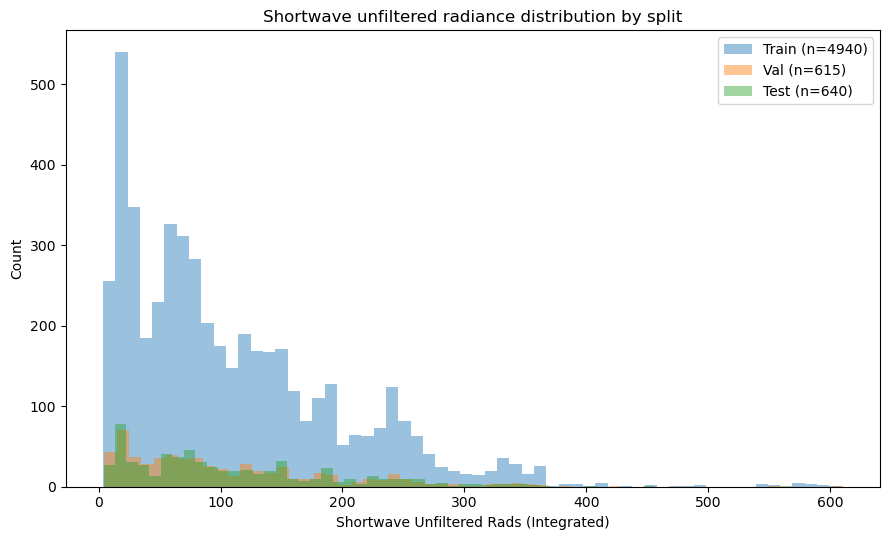

In [175]:
plot_split_target_hist(
    df=all_dataset,
    tr_idx=sw_train_idx,
    val_idx=sw_val_idx,
    te_idx=sw_test_idx,
    target_col="Shortwave Unfiltered Rads (Integrated)",
    title="Shortwave unfiltered radiance distribution by split",
)

In [30]:
lw_all_channels_model = final_ml_testing(all_dataset, v=True, is_sw=False, input_features=['Shortwave Filtered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ'], use_groups=True)

Input features ['Shortwave Filtered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ']
In train test split: ['Shortwave Filtered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ']
data sizes
(4940, 39)
(605, 39)
(650, 39)
Train (4940, 7), Val (605, 7), Test (650, 7)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


# All models
Baseline
- sw_scene_model, lw_scene_model

Libera Only
- sw_all_channels_model, lw_all_channels_model

ML Based
- sw_model, lw_model, ssw_model

In [ ]:
# sw_model, lw_model, sw_scene_model, lw_scene_model, test_model, ssw_model, sw_everything_model, lw_everything_model, sw_all_channels_model, lw_all_channels_model

In [125]:
sw_scene_model.keys()

dict_keys(['Regression_val', 'Regression_test', 'GridSearch', 'Val_RMSE', 'Val_MAE', 'Val_MAPE%', 'Val_R2', 'CV_Fold_RMSEs', 'CV_RMSE_mean', 'CV_RMSE_std', 'ML_test_df', 'Regression_test_df', 'Test_plot_df', 'Test_RMSE', 'Test_MAE', 'Test_MAPE%', 'Test_R2', 'Final_Model', 'Params_Used', 'Train_data', 'Validation_data', 'Test_data'])

In [126]:
lw_scene_model.keys()

dict_keys(['Regression_val', 'Regression_test', 'GridSearch', 'Val_RMSE', 'Val_MAE', 'Val_MAPE%', 'Val_R2', 'CV_Fold_RMSEs', 'CV_RMSE_mean', 'CV_RMSE_std', 'ML_test_df', 'Regression_test_df', 'Test_plot_df', 'Test_RMSE', 'Test_MAE', 'Test_MAPE%', 'Test_R2', 'Final_Model', 'Params_Used', 'Train_data', 'Validation_data', 'Test_data'])

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def relative_percent_error(y_true, y_pred, eps: float = 1e-12):
    """
    Relative percent error: 100 * (y_pred - y_true) / y_true
    Uses eps to avoid divide-by-zero explosions.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    safe_true = np.where(np.abs(y_true) < eps, eps, y_true)
    return 100.0 * (y_pred - y_true) / safe_true

In [141]:
def plot_percent_error_panels_4up(
    channel: str,
    ret_regression: dict,
    ret_ml_baseline: dict,
    ret_ml_libera: dict,
    ret_ml_full: dict,
    *,
    bins: int = 60,
    xlim: tuple[float, float] | None = (-10, 10),
    density: bool = False,
    title: str | None = None,
    show_zero_line: bool = True,
    eps: float = 1e-12,
):
    """
    Create a 2x2 panel plot of % error histograms:
      [0,0] Regression
      [0,1] ML Baseline
      [1,0] ML Libera-only
      [1,1] ML Full / ML-chosen-features

    Each `ret_*` should be the output dict returned by final_ml_testing(...).

    Requirements:
      - ret_regression must include ret["Regression_test_df"] with SW_unf_pred_reg / LW_unf_pred_reg, etc.
      - each ML ret must include ret["ML_test_df"] with SW_unf_pred_ml / LW_unf_pred_ml, etc.

    channel: one of {"SW", "LW", "SSW", "TOT"} (we map it to your column names below).
    """

    channel = channel.upper().strip()

    # ---- Map channel to your truth/pred column names ----
    # Adjust these if your dataset uses different column names.
    truth_map = {
        "SW":  "Shortwave Unfiltered Rads (Integrated)",
        "LW":  "Longwave Unfiltered Rads (Integrated)",
        # If you have these columns, keep them; otherwise update/remove.
        "SSW": "Split Shortwave Unfiltered Rads (Integrated)",
        "TOT": "Total Unfiltered Rads (Integrated)",
    }
    pred_reg_map = {
        "SW":  "SW_unf_pred_reg",
        "LW":  "LW_unf_pred_reg",
        "SSW": "SSW_unf_pred_reg",
        "TOT": "TOT_unf_pred_reg",
    }
    pred_ml_map = {
        "SW":  "SW_unf_pred_ml",
        "LW":  "LW_unf_pred_ml",
        "SSW": "SSW_unf_pred_ml",
        "TOT": "TOT_unf_pred_ml",
    }

    if channel not in truth_map:
        raise ValueError(f"Unknown channel={channel}. Expected one of {list(truth_map.keys())}")

    y_col = truth_map[channel]
    reg_pred_col = pred_reg_map[channel]
    ml_pred_col = pred_ml_map[channel]

    # ---- Extract the test dfs ----
    reg_df = ret_regression.get("Regression_test_df")
    if reg_df is None:
        raise KeyError("ret_regression must contain 'Regression_test_df'")

    def _get_ml_df(ret: dict, name: str) -> pd.DataFrame:
        df = ret.get("ML_test_df")
        if df is None:
            raise KeyError(f"{name} must contain 'ML_test_df'")
        return df

    ml_base_df  = _get_ml_df(ret_ml_baseline, "ret_ml_baseline")
    ml_lib_df   = _get_ml_df(ret_ml_libera, "ret_ml_libera")
    ml_full_df  = _get_ml_df(ret_ml_full, "ret_ml_full")

    # ---- Compute errors with consistent cleaning ----
    def _errors(df: pd.DataFrame, pred_col: str) -> np.ndarray:
        y_true = pd.to_numeric(df[y_col], errors="coerce").to_numpy()
        y_pred = pd.to_numeric(df[pred_col], errors="coerce").to_numpy()
        m = np.isfinite(y_true) & np.isfinite(y_pred)
        return relative_percent_error(y_true[m], y_pred[m], eps=eps)

    # Regression errors
    if reg_pred_col not in reg_df.columns:
        raise KeyError(f"Regression df missing prediction column '{reg_pred_col}'. "
                       f"Available: {list(reg_df.columns)}")
    e_reg = _errors(reg_df, reg_pred_col)

    # ML errors
    for df, nm in [(ml_base_df, "Baseline ML"), (ml_lib_df, "Libera ML"), (ml_full_df, "Full ML")]:
        if ml_pred_col not in df.columns:
            raise KeyError(f"{nm} df missing prediction column '{ml_pred_col}'.")

    e_base = _errors(ml_base_df, ml_pred_col)
    e_lib  = _errors(ml_lib_df, ml_pred_col)
    e_full = _errors(ml_full_df, ml_pred_col)

    # ---- Plot ----
    fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

    panels = [
        ("Regression (traditional)", e_reg,  axes[0, 0]),
        ("ML Baseline (physically informed)", e_base, axes[0, 1]),
        ("ML Libera-only", e_lib, axes[1, 0]),
        ("ML Full / ML-chosen features", e_full, axes[1, 1]),
    ]

    for panel_title, errs, ax in panels:
        ax.hist(errs, bins=bins, density=density, alpha=0.9)
        if show_zero_line:
            ax.axvline(0, linestyle="--")
        if xlim is not None:
            ax.set_xlim(*xlim)
        ax.set_title(panel_title)
        ax.set_xlabel("Relative Error (%)")
        ax.set_ylabel("Density" if density else "Count")

        # quick stats in the corner
        med = float(np.median(errs)) if len(errs) else np.nan
        mae = float(np.mean(np.abs(errs))) if len(errs) else np.nan
        ax.text(
            0.98, 0.98,
            f"n={len(errs)}\nmedian={med:.3f}%\nMAE={mae:.3f}%",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9,
        )

    fig.suptitle(title or f"{channel}: Relative Percent Error Distributions (Test Set)", fontsize=14)
    plt.savefig(f"./imgs/{channel}_pe_plot", dpi=600, bbox_inches="tight")
    plt.show()

In [152]:
sw_model['Regression_test']['standard_df'].columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)',
       'Split Shortwave Filtered Rads (Integrated)',
       'Total Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5',
       'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12',
       'M13', 'M14', 'M15', 'I5', 'M16', 'Scaled Shortwave Filtered',
       'Scaled Shortwave Unfiltered', 'Scaled Longwave Filtered',
       'Scaled Longwave Unfiltered', 'Scene_encoded', 'SW_unf_pred',
       'LW_unf_pred', 'SW_unf_pred_ssw'],
      dtype='object')

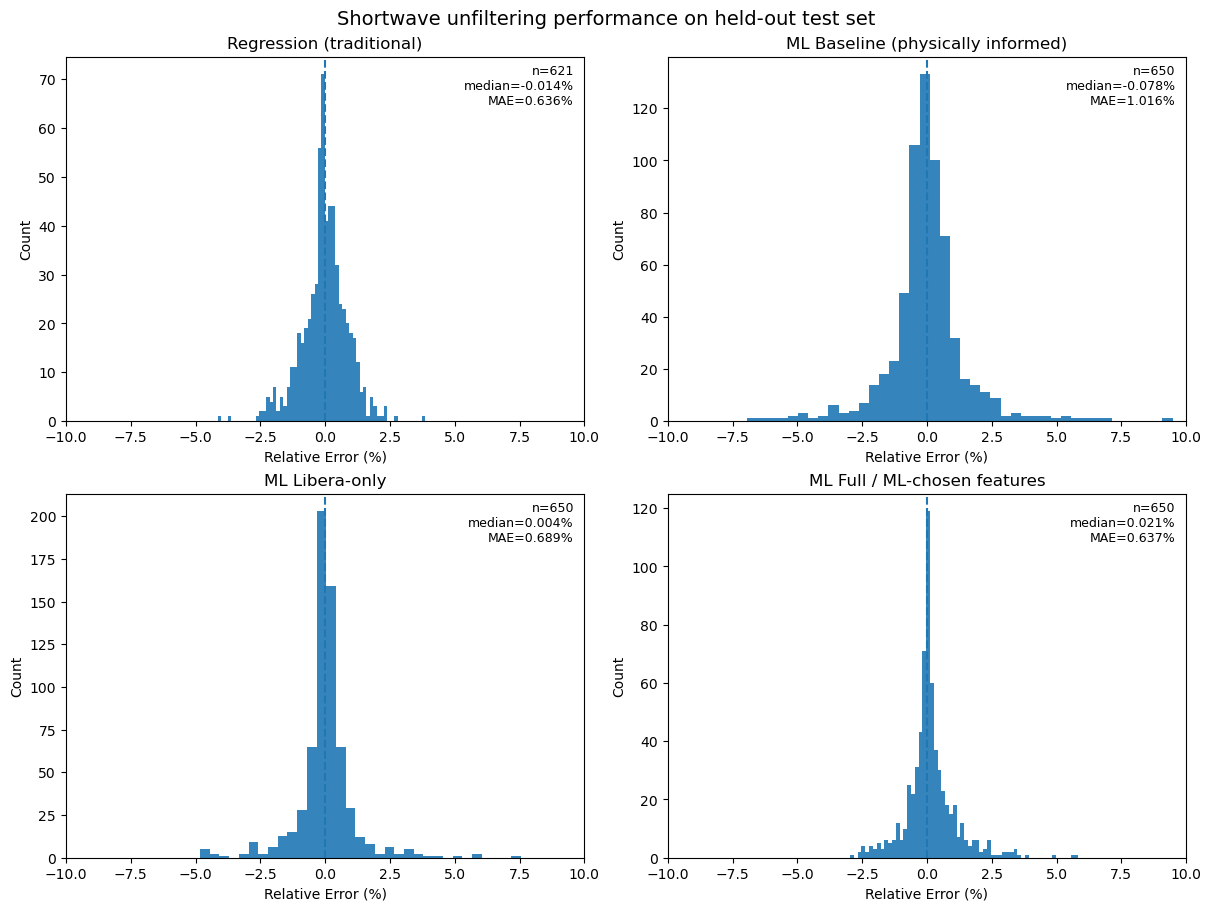

In [143]:
plot_percent_error_panels_4up(
    channel="SW",
    ret_regression=sw_scene_model,
    ret_ml_baseline=sw_scene_model,
    ret_ml_libera=sw_all_channels_model,
    ret_ml_full=sw_model,
    bins=60,
    xlim=(-10, 10),
    title="Shortwave unfiltering performance on held-out test set",
)

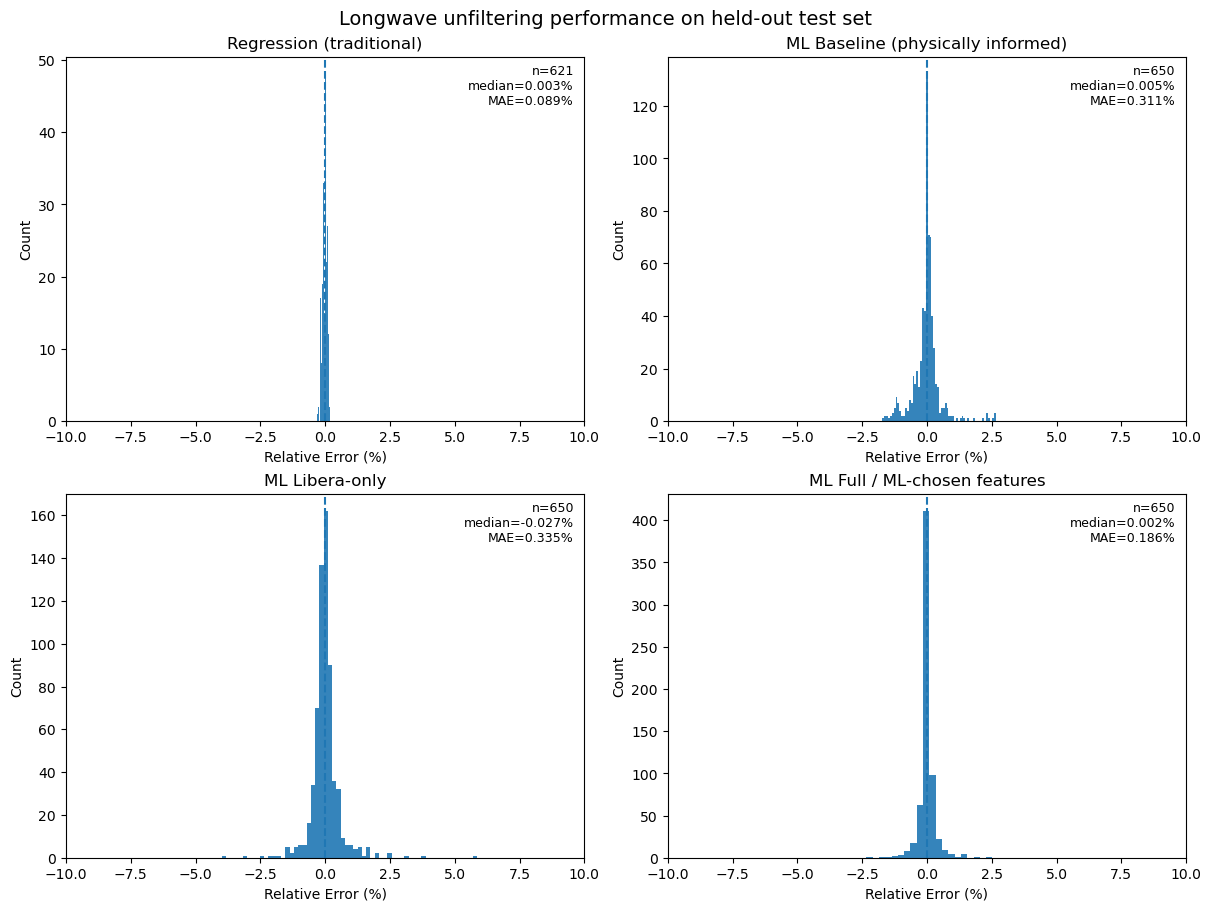

In [153]:
plot_percent_error_panels_4up(
    channel="lW",
    ret_regression=lw_scene_model,
    ret_ml_baseline=lw_scene_model,
    ret_ml_libera=lw_all_channels_model,
    ret_ml_full=lw_model,
    bins=60,
    xlim=(-10, 10),
    title="Longwave unfiltering performance on held-out test set",
)

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def relative_percent_error(y_true, y_pred, eps: float = 1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    safe_true = np.where(np.abs(y_true) < eps, eps, y_true)
    return 100.0 * (y_pred - y_true) / safe_true


def plot_sw_percent_error_overlay_panels(
    sw_regression_ret: dict,
    sw_ml_baseline_ret: dict,
    sw_ml_libera_ret: dict,
    sw_ml_rf_ret: dict,
    *,
    bins: int = 60,
    xlim: tuple[float, float] | None = (-10, 10),
    density: bool = True,
    alpha_base: float = 0.55,
    alpha_overlay: float = 0.55,
    title: str = "Shortwave Relative Percent Error Comparison (Test Set)",
    eps: float = 1e-12,
):
    """
    2x2 panel plot for Shortwave where baseline regression is overlaid in all panels.

    Panels:
      [0,0] baseline regression vs SSW+SW regression
      [0,1] baseline regression vs ML baseline
      [1,0] baseline regression vs ML Libera
      [1,1] baseline regression vs ML RF/chosen-features

    Expected objects:
      sw_regression_ret["Regression_test"]["standard_df"] with columns:
          - "Shortwave Unfiltered Rads (Integrated)"
          - "SW_unf_pred"
          - "SW_unf_pred_ssw"

      each ML ret should contain:
          - ret["ML_test_df"]
          - column "SW_unf_pred_ml"
    """

    reg_df = sw_regression_ret["Regression_test"]["standard_df"]
    y_col = "Shortwave Unfiltered Rads (Integrated)"
    reg_base_col = "SW_unf_pred"
    reg_ssw_col = "SW_unf_pred_ssw"
    ml_col = "SW_unf_pred_ml"

    def _clean_percent_error(df: pd.DataFrame, pred_col: str):
        y_true = pd.to_numeric(df[y_col], errors="coerce").to_numpy()
        y_pred = pd.to_numeric(df[pred_col], errors="coerce").to_numpy()
        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        return relative_percent_error(y_true[mask], y_pred[mask], eps=eps)

    # Baseline regression
    e_reg_base = _clean_percent_error(reg_df, reg_base_col)

    # SSW+SW regression
    e_reg_ssw = _clean_percent_error(reg_df, reg_ssw_col)

    # ML models
    ml_base_df = sw_ml_baseline_ret["ML_test_df"]
    ml_lib_df  = sw_ml_libera_ret["ML_test_df"]
    ml_rf_df   = sw_ml_rf_ret["ML_test_df"]

    e_ml_base = _clean_percent_error(ml_base_df, ml_col)
    e_ml_lib  = _clean_percent_error(ml_lib_df, ml_col)
    e_ml_rf   = _clean_percent_error(ml_rf_df, ml_col)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

    panel_info = [
        ("Standard Regression vs SSW+SW Regression", e_reg_ssw, axes[0, 0], "SSW+SW Regression"),
        ("Standard Regression vs ML Scene-based",       e_ml_base, axes[0, 1], "ML Scene-based"),
        ("Standard Regression vs ML Libera radiometer",         e_ml_lib,  axes[1, 0], "ML Libera radiometer"),
        ("Standard Regression vs ML RF Features",    e_ml_rf,   axes[1, 1], "ML RF Features"),
    ]

    for panel_title, overlay_errs, ax, overlay_label in panel_info:
        ax.hist(
            e_reg_base,
            bins=bins,
            density=density,
            alpha=alpha_base,
            label="Standard Regression"
        )
        ax.hist(
            overlay_errs,
            bins=bins,
            density=density,
            alpha=alpha_overlay,
            label=overlay_label
        )
        # combined = np.concatenate([e_reg_base, overlay_errs])
        # bin_edges = np.histogram_bin_edges(combined, bins=bins)
        #
        # ax.hist(
        #     e_reg_base,
        #     bins=bin_edges,
        #     density=density,
        #     alpha=alpha_base,
        #     label="Baseline Regression"
        # )
        #
        # ax.hist(
        #     overlay_errs,
        #     bins=bin_edges,
        #     density=density,
        #     alpha=alpha_overlay,
        #     label=overlay_label
        # )

        ax.axvline(0, linestyle="--")
        if xlim is not None:
            ax.set_xlim(*xlim)

        ax.set_title(panel_title)
        ax.set_xlabel("Relative Error (%)")
        ax.set_ylabel("Density" if density else "Count")
        ax.legend()

        base_mae = np.mean(np.abs(e_reg_base))
        over_mae = np.mean(np.abs(overlay_errs))

        ax.text(
            0.98, 0.98,
            f"Standard MAPE={base_mae:.3f}%\n{overlay_label} MAPE={over_mae:.3f}%",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
        )

    fig.suptitle(title, fontsize=14)
    plt.savefig(f"./imgs/{title}.png", dpi=600, bbox_inches="tight")
    plt.show()

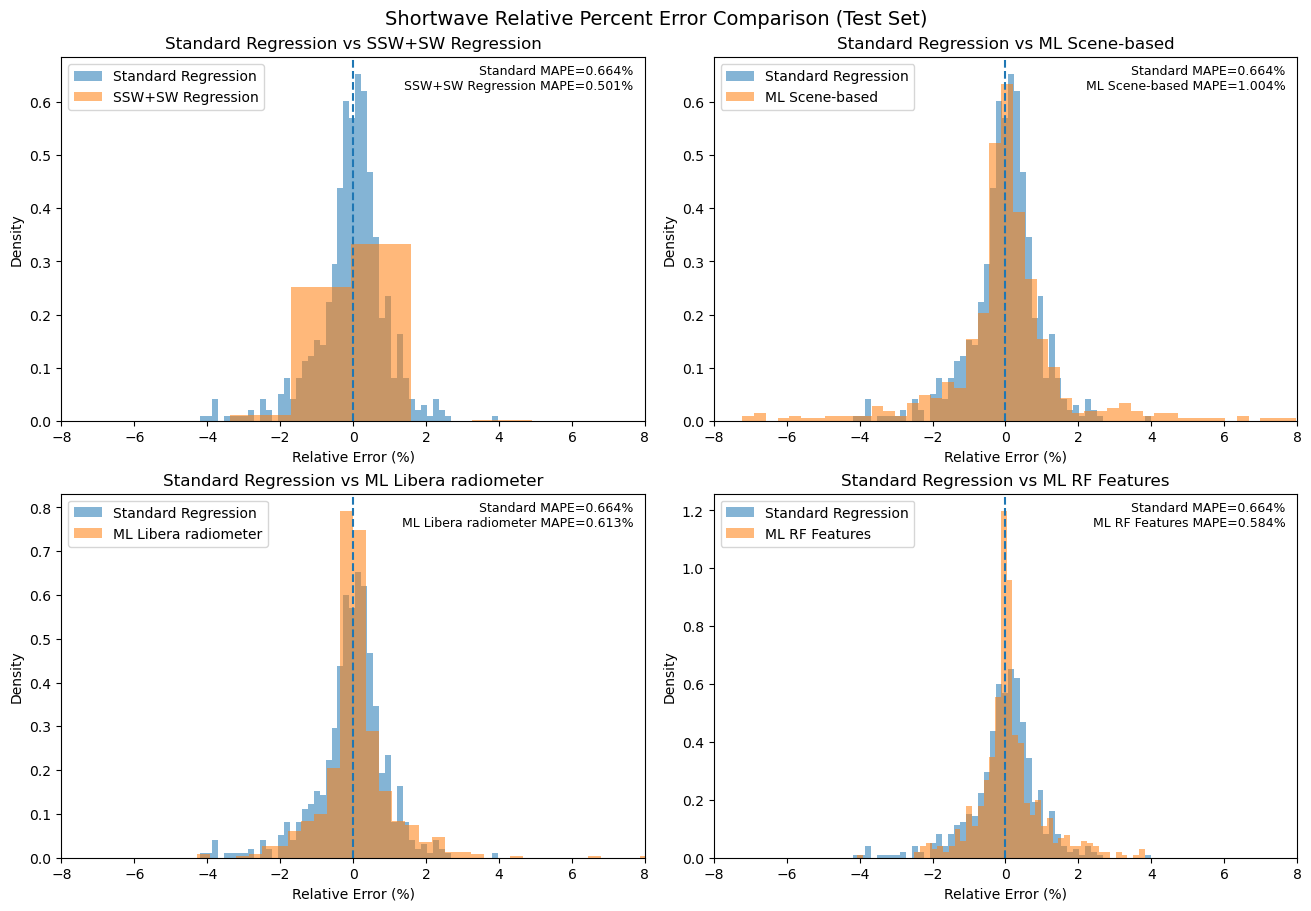

In [43]:
# plot_percent_error_panels_4up(
#     channel="SW",
#     ret_regression=sw_scene_model,
#     ret_ml_baseline=sw_scene_model,
#     ret_ml_libera=sw_all_channels_model,
#     ret_ml_full=sw_model,
#     bins=60,
#     xlim=(-10, 10),
#     title="Shortwave unfiltering performance on held-out test set",
# )

plot_sw_percent_error_overlay_panels(
    sw_regression_ret=sw_scene_model,
    sw_ml_baseline_ret=sw_scene_model,
    sw_ml_libera_ret=sw_all_channels_model,
    sw_ml_rf_ret=sw_model,
    bins=50,
    xlim=(-8, 8),
)

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def relative_percent_error(y_true, y_pred, eps: float = 1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    safe_true = np.where(np.abs(y_true) < eps, eps, y_true)
    return 100.0 * (y_pred - y_true) / safe_true


def plot_lw_percent_error_overlay_panels(
    lw_regression_ret: dict,
    lw_ml_baseline_ret: dict,
    lw_ml_libera_ret: dict,
    lw_ml_rf_ret: dict,
    *,
    bins: int = 60,
    xlim: tuple[float, float] | None = (-10, 10),
    density: bool = False,
    alpha_base: float = 0.55,
    alpha_overlay: float = 0.55,
    title: str = "Longwave Relative Percent Error Comparison (Test Set)",
    eps: float = 1e-12,
):
    """
    1x3 panel plot for Longwave where baseline LW regression is overlaid in all panels.

    Panels:
      [0] baseline regression vs ML baseline
      [1] baseline regression vs ML Libera
      [2] baseline regression vs ML RF/chosen-features

    Expected:
      lw_regression_ret["Regression_test"]["standard_df"] with columns:
          - "Longwave Unfiltered Rads (Integrated)"
          - "LW_unf_pred"

      each ML ret should contain:
          - ret["ML_test_df"]
          - column "LW_unf_pred_ml"
    """

    reg_df = lw_regression_ret["Regression_test"]["standard_df"]
    y_col = "Longwave Unfiltered Rads (Integrated)"
    reg_base_col = "LW_unf_pred"
    ml_col = "LW_unf_pred_ml"

    def _clean_percent_error(df: pd.DataFrame, pred_col: str):
        y_true = pd.to_numeric(df[y_col], errors="coerce").to_numpy()
        y_pred = pd.to_numeric(df[pred_col], errors="coerce").to_numpy()
        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        return relative_percent_error(y_true[mask], y_pred[mask], eps=eps)

    e_reg_base = _clean_percent_error(reg_df, reg_base_col)

    ml_base_df = lw_ml_baseline_ret["ML_test_df"]
    ml_lib_df  = lw_ml_libera_ret["ML_test_df"]
    ml_rf_df   = lw_ml_rf_ret["ML_test_df"]

    e_ml_base = _clean_percent_error(ml_base_df, ml_col)
    e_ml_lib  = _clean_percent_error(ml_lib_df, ml_col)
    e_ml_rf   = _clean_percent_error(ml_rf_df, ml_col)

    print("Regression N:", len(e_reg_base))
    print("ML baseline N:", len(e_ml_base))
    print("ML libera N:", len(e_ml_lib))
    print("ML rf N:", len(e_ml_rf))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

    panel_info = [
        ("Standard Regression vs ML Scene-based",    e_ml_base, axes[0], "ML Scene-based"),
        ("Standard Regression vs ML Libera radiometer",      e_ml_lib,  axes[1], "ML Libera radiometer"),
        ("Standard Regression vs ML RF Features", e_ml_rf,   axes[2], "ML RF Features"),
    ]

    for panel_title, overlay_errs, ax, overlay_label in panel_info:
        # ax.hist(
        #     e_reg_base,
        #     bins=bins,
        #     density=density,
        #     alpha=alpha_base,
        #     label="Baseline Regression"
        # )
        # ax.hist(
        #     overlay_errs,
        #     bins=bins,
        #     density=density,
        #     alpha=alpha_overlay,
        #     label=overlay_label
        # )

        combined = np.concatenate([e_reg_base, overlay_errs])
        bin_edges = np.histogram_bin_edges(combined, bins=bins)

        ax.hist(
            e_reg_base,
            bins=bin_edges,
            density=density,
            alpha=alpha_base,
            label="Standard Regression"
        )

        ax.hist(
            overlay_errs,
            bins=bin_edges,
            density=density,
            alpha=alpha_overlay,
            label=overlay_label
        )

        ax.axvline(0, linestyle="--")
        if xlim is not None:
            ax.set_xlim(*xlim)

        ax.set_title(panel_title)
        ax.set_xlabel("Relative Error (%)")
        ax.set_ylabel("Density" if density else "Count")
        ax.legend()

        base_mae = np.mean(np.abs(e_reg_base))
        over_mae = np.mean(np.abs(overlay_errs))

        ax.text(
            0.98, 0.98,
            f"Standard MAPE={base_mae:.3f}%\n{overlay_label} MAE={over_mae:.3f}%",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
        )

    fig.suptitle(title, fontsize=14)
    plt.savefig(f"./imgs/{title}.png", dpi=600, bbox_inches="tight")
    plt.show()

Regression N: 621
ML baseline N: 650
ML libera N: 650
ML rf N: 650


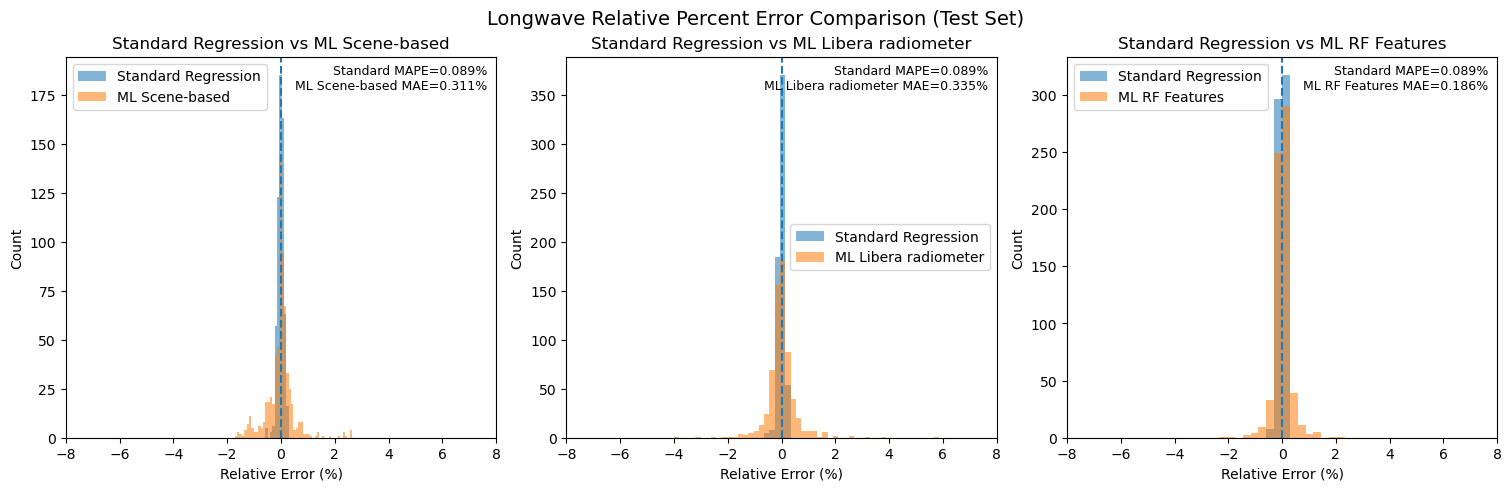

In [45]:
# plot_percent_error_panels_4up(
#     channel="lW",
#     ret_regression=lw_scene_model,
#     ret_ml_baseline=lw_scene_model,
#     ret_ml_libera=lw_all_channels_model,
#     ret_ml_full=lw_model,
#     bins=60,
#     xlim=(-10, 10),
#     title="Longwave unfiltering performance on held-out test set",
# )


plot_lw_percent_error_overlay_panels(
    lw_regression_ret=lw_scene_model,
    lw_ml_baseline_ret=lw_scene_model,
    lw_ml_libera_ret=lw_all_channels_model,
    lw_ml_rf_ret=lw_model,
    bins=50,
    xlim=(-8, 8),
)

In [60]:
lw_model.keys()

dict_keys(['Regression_val', 'Regression_test', 'GridSearch', 'Val_RMSE', 'Val_MAE', 'Val_MAPE%', 'Val_R2', 'CV_Fold_RMSEs', 'CV_RMSE_mean', 'CV_RMSE_std', 'ML_test_df', 'Regression_test_df', 'Test_plot_df', 'Test_RMSE', 'Test_MAE', 'Test_MAPE%', 'Test_R2', 'Final_Model', 'Params_Used', 'Train_data', 'Validation_data', 'Test_data'])

In [64]:
df1 = lw_model["ML_test_df"]
df2 = lw_model["Regression_test"]["standard_df"]

In [62]:
df1

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),...,M14,M15,I5,M16,Scaled Shortwave Filtered,Scaled Shortwave Unfiltered,Scaled Longwave Filtered,Scaled Longwave Unfiltered,Scene_encoded,LW_unf_pred_ml
1,Snow,0.000,0.000,0.0,1,1,308.989576,61.707542,224.248333,40.116431,...,0.000327,0.000176,0.000381,2.261981e-04,0.463442,0.503278,0.453486,0.439632,2,62.162417
23,Snow,0.066,30.000,7.5,1,23,363.425318,53.412802,268.780611,34.865491,...,0.012942,0.007767,0.010499,3.437981e-03,0.556446,0.592972,0.344008,0.331623,2,53.414836
24,Snow,0.066,30.000,7.5,1,24,307.329228,62.886232,224.836618,40.892467,...,0.011865,0.006748,0.008721,2.682710e-03,0.464671,0.500543,0.469666,0.454980,2,62.902114
32,Snow,0.311,30.000,37.5,1,32,294.881847,64.577008,213.489210,41.919058,...,0.000036,0.000053,0.000135,9.666399e-05,0.440972,0.480033,0.491069,0.476996,2,64.593510
46,Snow,0.511,30.000,90.0,1,46,303.565123,60.699093,220.472793,39.470687,...,0.000308,0.000181,0.000396,2.376948e-04,0.455557,0.494340,0.440023,0.426500,2,60.716365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6154,Clear Ocean,84.848,60.000,172.5,0,106,10.673827,91.598231,7.192588,58.423045,...,0.000003,0.000001,0.000002,6.351223e-07,0.010130,0.011743,0.835165,0.828847,4,91.477822
6164,Clear Ocean,85.850,89.947,7.5,0,116,198.342393,68.745837,154.145855,44.440427,...,0.000567,0.000412,0.000459,1.162115e-04,0.317036,0.320965,0.543638,0.531279,4,68.725779
6169,Clear Ocean,85.648,89.947,37.5,0,121,57.066929,68.826195,43.106074,44.481174,...,0.000041,0.000032,0.000040,1.369233e-05,0.085134,0.088185,0.544488,0.532326,4,68.828370
6178,Clear Ocean,84.911,89.947,90.0,0,130,33.474285,68.745823,24.265128,44.440407,...,0.000021,0.000017,0.000020,6.748014e-06,0.045786,0.049311,0.543638,0.531279,4,68.754416


In [65]:
df2

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),...,I5,M16,Scaled Shortwave Filtered,Scaled Shortwave Unfiltered,Scaled Longwave Filtered,Scaled Longwave Unfiltered,Scene_encoded,SW_unf_pred,LW_unf_pred,SW_unf_pred_ssw
1,Snow,0.000,0.000,0.0,1,1,308.989576,61.707542,224.248333,40.116431,...,0.000381,2.261981e-04,0.463442,0.503278,0.453486,0.439632,2,306.750735,61.672410,308.439979
23,Snow,0.066,30.000,7.5,1,23,363.425318,53.412802,268.780611,34.865491,...,0.010499,3.437981e-03,0.556446,0.592972,0.344008,0.331623,2,365.897906,53.407251,363.131313
24,Snow,0.066,30.000,7.5,1,24,307.329228,62.886232,224.836618,40.892467,...,0.008721,2.682710e-03,0.464671,0.500543,0.469666,0.454980,2,307.521388,62.906807,307.677807
32,Snow,0.311,30.000,37.5,1,32,294.881847,64.577008,213.489210,41.919058,...,0.000135,9.666399e-05,0.440972,0.480033,0.491069,0.476996,2,292.079244,64.542155,294.353394
46,Snow,0.511,30.000,90.0,1,46,303.565123,60.699093,220.472793,39.470687,...,0.000396,2.376948e-04,0.455557,0.494340,0.440023,0.426500,2,301.403554,60.653492,303.071942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6154,Clear Ocean,84.848,60.000,172.5,0,106,10.673827,91.598231,7.192588,58.423045,...,0.000002,6.351223e-07,0.010130,0.011743,0.835165,0.828847,4,10.456862,91.442188,10.643683
6164,Clear Ocean,85.850,89.947,7.5,0,116,198.342393,68.745837,154.145855,44.440427,...,0.000459,1.162115e-04,0.317036,0.320965,0.543638,0.531279,4,NaN,NaN,NaN
6169,Clear Ocean,85.648,89.947,37.5,0,121,57.066929,68.826195,43.106074,44.481174,...,0.000040,1.369233e-05,0.085134,0.088185,0.544488,0.532326,4,NaN,NaN,NaN
6178,Clear Ocean,84.911,89.947,90.0,0,130,33.474285,68.745823,24.265128,44.440407,...,0.000020,6.748014e-06,0.045786,0.049311,0.543638,0.531279,4,33.601134,68.713533,33.540045


In [159]:
sorted(-sw_train_idx)

[-6193,
 -6192,
 -6191,
 -6190,
 -6188,
 -6187,
 -6186,
 -6184,
 -6183,
 -6182,
 -6181,
 -6180,
 -6179,
 -6177,
 -6176,
 -6175,
 -6174,
 -6173,
 -6172,
 -6171,
 -6170,
 -6168,
 -6167,
 -6166,
 -6165,
 -6163,
 -6162,
 -6161,
 -6160,
 -6159,
 -6158,
 -6157,
 -6156,
 -6153,
 -6152,
 -6149,
 -6148,
 -6146,
 -6145,
 -6144,
 -6143,
 -6142,
 -6141,
 -6137,
 -6134,
 -6133,
 -6132,
 -6131,
 -6130,
 -6129,
 -6128,
 -6127,
 -6126,
 -6125,
 -6124,
 -6121,
 -6120,
 -6118,
 -6117,
 -6116,
 -6115,
 -6114,
 -6113,
 -6112,
 -6111,
 -6110,
 -6109,
 -6108,
 -6107,
 -6104,
 -6103,
 -6102,
 -6101,
 -6099,
 -6098,
 -6097,
 -6095,
 -6094,
 -6093,
 -6092,
 -6091,
 -6090,
 -6088,
 -6087,
 -6086,
 -6084,
 -6083,
 -6082,
 -6081,
 -6079,
 -6078,
 -6077,
 -6076,
 -6075,
 -6074,
 -6073,
 -6072,
 -6071,
 -6070,
 -6067,
 -6066,
 -6065,
 -6064,
 -6063,
 -6061,
 -6060,
 -6059,
 -6058,
 -6057,
 -6056,
 -6055,
 -6054,
 -6053,
 -6052,
 -6051,
 -6050,
 -6048,
 -6046,
 -6045,
 -6044,
 -6043,
 -6041,
 -6040,
 -6039,
 -6037,


In [160]:
sorted(-sw_val_idx)

[-6189,
 -6185,
 -6155,
 -6139,
 -6138,
 -6136,
 -6123,
 -6106,
 -6105,
 -6096,
 -6089,
 -6085,
 -6080,
 -6069,
 -6042,
 -6038,
 -6008,
 -5992,
 -5991,
 -5989,
 -5976,
 -5959,
 -5958,
 -5949,
 -5942,
 -5938,
 -5933,
 -5922,
 -5895,
 -5891,
 -5861,
 -5845,
 -5844,
 -5842,
 -5829,
 -5812,
 -5811,
 -5802,
 -5795,
 -5791,
 -5786,
 -5775,
 -5748,
 -5744,
 -5714,
 -5698,
 -5697,
 -5695,
 -5682,
 -5665,
 -5664,
 -5655,
 -5648,
 -5644,
 -5639,
 -5628,
 -5601,
 -5597,
 -5567,
 -5551,
 -5550,
 -5548,
 -5535,
 -5518,
 -5517,
 -5508,
 -5501,
 -5497,
 -5492,
 -5481,
 -5446,
 -5441,
 -5434,
 -5411,
 -5407,
 -5404,
 -5403,
 -5388,
 -5362,
 -5357,
 -5350,
 -5327,
 -5323,
 -5320,
 -5319,
 -5304,
 -5278,
 -5273,
 -5266,
 -5243,
 -5239,
 -5236,
 -5235,
 -5220,
 -5194,
 -5189,
 -5182,
 -5159,
 -5155,
 -5152,
 -5151,
 -5136,
 -5110,
 -5105,
 -5098,
 -5075,
 -5071,
 -5068,
 -5067,
 -5052,
 -5036,
 -5012,
 -5005,
 -4996,
 -4995,
 -4979,
 -4973,
 -4949,
 -4942,
 -4933,
 -4932,
 -4916,
 -4910,
 -4886,
 -4879,


In [161]:
sorted(-sw_test_idx)

[-6194,
 -6178,
 -6169,
 -6164,
 -6154,
 -6151,
 -6150,
 -6147,
 -6140,
 -6135,
 -6122,
 -6119,
 -6100,
 -6068,
 -6062,
 -6049,
 -6047,
 -6031,
 -6022,
 -6017,
 -6007,
 -6004,
 -6003,
 -6000,
 -5993,
 -5988,
 -5975,
 -5972,
 -5953,
 -5921,
 -5915,
 -5902,
 -5900,
 -5884,
 -5875,
 -5870,
 -5860,
 -5857,
 -5856,
 -5853,
 -5846,
 -5841,
 -5828,
 -5825,
 -5806,
 -5774,
 -5768,
 -5755,
 -5753,
 -5737,
 -5728,
 -5723,
 -5713,
 -5710,
 -5709,
 -5706,
 -5699,
 -5694,
 -5681,
 -5678,
 -5659,
 -5627,
 -5621,
 -5608,
 -5606,
 -5590,
 -5581,
 -5576,
 -5566,
 -5563,
 -5562,
 -5559,
 -5552,
 -5547,
 -5534,
 -5531,
 -5512,
 -5480,
 -5474,
 -5461,
 -5452,
 -5438,
 -5427,
 -5426,
 -5418,
 -5417,
 -5398,
 -5390,
 -5379,
 -5368,
 -5354,
 -5343,
 -5342,
 -5334,
 -5333,
 -5314,
 -5306,
 -5295,
 -5284,
 -5270,
 -5259,
 -5258,
 -5250,
 -5249,
 -5230,
 -5222,
 -5211,
 -5200,
 -5186,
 -5175,
 -5174,
 -5166,
 -5165,
 -5146,
 -5138,
 -5127,
 -5116,
 -5102,
 -5091,
 -5090,
 -5082,
 -5081,
 -5062,
 -5054,
 -5043,


In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_split_violin(
    df: pd.DataFrame,
    tr_idx,
    val_idx,
    te_idx,
    value_col: str,
    title: str | None = None,
    ylabel: str | None = None,
    show_points: bool = True,
):
    """
    Violin plot of a column across train / val / test splits.
    """
    tr_idx = np.asarray(tr_idx)
    val_idx = np.asarray(val_idx)
    te_idx = np.asarray(te_idx)

    def _get_vals(idxs):
        vals = pd.to_numeric(df.iloc[idxs][value_col], errors="coerce").to_numpy()
        return vals[np.isfinite(vals)]

    vals_tr = _get_vals(tr_idx)
    vals_val = _get_vals(val_idx)
    vals_te = _get_vals(te_idx)

    data = [vals_tr, vals_val, vals_te]
    labels = [f"Train\n(n={len(vals_tr)})", f"Val\n(n={len(vals_val)})", f"Test\n(n={len(vals_te)})"]

    fig, ax = plt.subplots(figsize=(8, 6))
    parts = ax.violinplot(data, showmeans=False, showmedians=True, showextrema=True)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel or value_col)
    ax.set_title(title or f"{value_col} distribution by split")

    if show_points:
        rng = np.random.default_rng(42)
        for i, vals in enumerate(data, start=1):
            if len(vals) == 0:
                continue
            jitter = rng.normal(0, 0.04, size=len(vals))
            ax.scatter(np.full(len(vals), i) + jitter, vals, alpha=0.15, s=8)

    plt.tight_layout()
    plt.savefig(f"./imgs/{title}.png", dpi=600, bbox_inches="tight")
    plt.show()

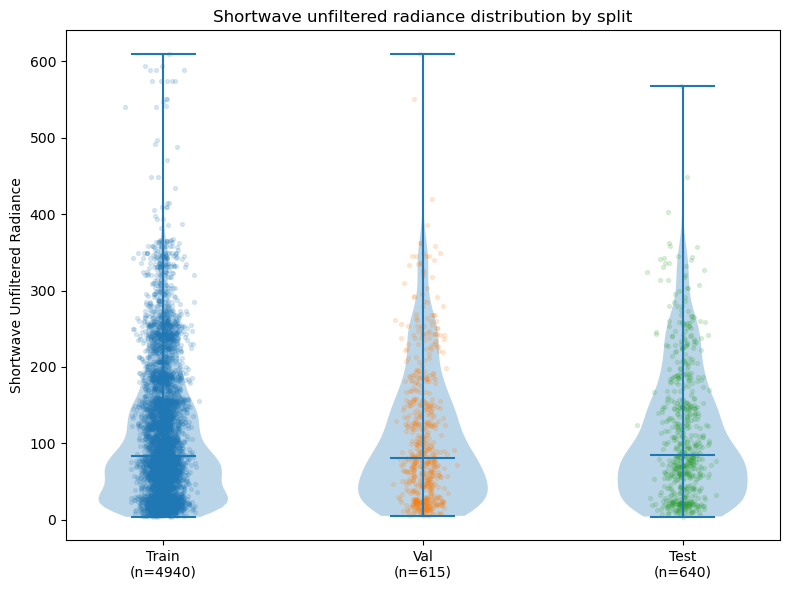

In [189]:
plot_split_violin(
    df=all_dataset,
    tr_idx=sw_train_idx,
    val_idx=sw_val_idx,
    te_idx=sw_test_idx,
    value_col="Shortwave Unfiltered Rads (Integrated)",
    title="Shortwave unfiltered radiance distribution by split",
    ylabel="Shortwave Unfiltered Radiance"
)

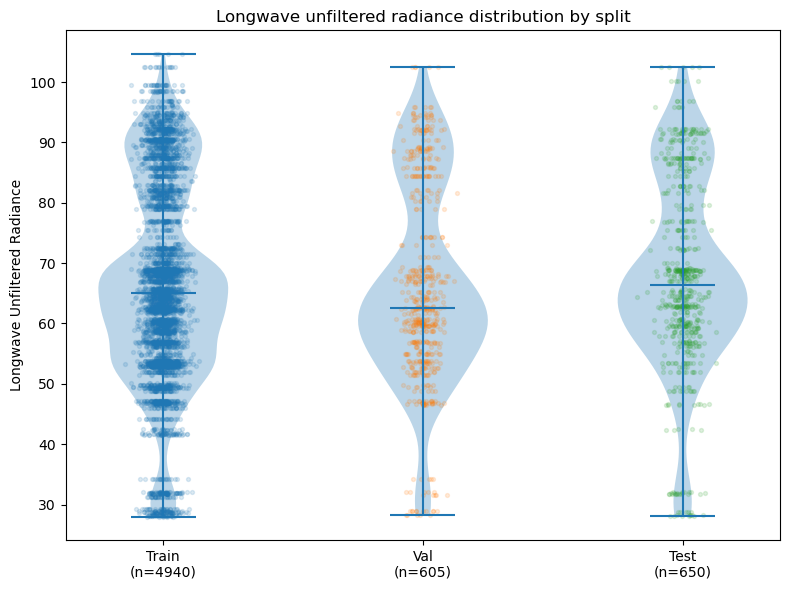

In [190]:
plot_split_violin(
    df=all_dataset,
    tr_idx=lw_train_idx,
    val_idx=lw_val_idx,
    te_idx=lw_test_idx,
    value_col="Longwave Unfiltered Rads (Integrated)",
    title="Longwave unfiltered radiance distribution by split",
    ylabel="Longwave Unfiltered Radiance"
)

In [167]:
group_sw = (
    all_dataset
    .assign(group_key=lambda d: d["Scene"].astype(str) + "|" + d["Cloud"].astype(str) + "|" + d["Run #"].astype(str))
    .groupby("group_key")["Shortwave Unfiltered Rads (Integrated)"]
    .max()
    .sort_values(ascending=False)
)

print(group_sw.head(20))

group_key
Land|1|507                    610.452673
Land|1|506                    609.404564
Land|1|497                    593.962578
Land|1|502                    593.962578
Snow|1|241                    588.520839
Snow|1|246                    588.520773
Snow|1|251                    588.520687
Land|1|496                    574.725503
Land|1|501                    574.725503
Land|1|482                    574.645778
Land|1|487                    574.645778
Cloudy Ocean|1|65             574.644405
Land|1|492                    568.320783
Land|1|486                    550.342487
Land|1|481                    550.342487
Cloudy Ocean|1|64             550.341126
Land|1|491                    547.176169
Deep Convective Cloud|1|48    496.856153
Deep Convective Cloud|1|49    492.373921
Deep Convective Cloud|1|50    487.521960
Name: Shortwave Unfiltered Rads (Integrated), dtype: float64


In [47]:
import pandas as pd

def build_results_table(
    sw_results: dict,
    lw_results: dict,
):
    """
    Build a results table comparing regression and ML models
    for SW and LW channels.

    Parameters
    ----------
    sw_results : dict
        Dictionary mapping model names to SW result objects
    lw_results : dict
        Dictionary mapping model names to LW result objects

    Returns
    -------
    pandas.DataFrame
        Table with RMSE, MAPE, and R²
    """

    rows = []

    def extract_metrics(ret, channel, model_name, regression=False):

        if regression:
            scores = ret["Regression_test"]
            rmse = scores["RMSE"]
            mape = scores["MAPE%"]
            r2 = scores["R2"]
        else:
            rmse = ret["Test_RMSE"]
            mape = ret["Test_MAPE%"]
            r2 = ret["Test_R2"]

        rows.append({
            "Channel": channel,
            "Model": model_name,
            "RMSE": rmse,
            "MAPE (%)": mape,
            "R²": r2
        })

    # ---- Shortwave ----
    for model_name, ret in sw_results.items():

        if model_name == "Regression":
            extract_metrics(ret, "SW", model_name, regression=True)
        else:
            extract_metrics(ret, "SW", model_name)

    # ---- Longwave ----
    for model_name, ret in lw_results.items():

        if model_name == "Regression":
            extract_metrics(ret, "LW", model_name, regression=True)
        else:
            extract_metrics(ret, "LW", model_name)

    df = pd.DataFrame(rows)

    df = df.sort_values(["Channel", "RMSE"])

    return df

In [196]:
sw_scene_model["Regression_test"]['cloud=0']

{'SW_1D': {'n': 179,
  'MAE': 0.4981673466353873,
  'RMSE': 0.7639826505923953,
  'Bias': 0.08752240895755765,
  'MAPE_%': 1.010309388937226,
  'R2': 0.9998513325278459},
 'LW_1D': {'n': 179,
  'MAE': 0.08590570477048164,
  'RMSE': 0.10976060683488509,
  'Bias': -0.03476819758920979,
  'MAPE_%': 0.10918371195454057,
  'R2': 0.9999260216074456},
 'SW_SSW': {'n': 179,
  'MAE': 0.2033540833499869,
  'RMSE': 0.2865645065845332,
  'Bias': -0.018207556776242896,
  'MAPE_%': 0.49591967358842204,
  'R2': 0.9999790832714007}}

In [197]:
sw_scene_model["Regression_test"]['cloud=1']

{'SW_1D': {'n': 442,
  'MAE': 0.6294074094638954,
  'RMSE': 0.9511143815804544,
  'Bias': 0.05623460893138774,
  'MAPE_%': 0.48508442909808663,
  'R2': 0.9998780356659684},
 'LW_1D': {'n': 442,
  'MAE': 0.0515979132985077,
  'RMSE': 0.06544568081236944,
  'Bias': 0.0027358985736711636,
  'MAPE_%': 0.08146127918978778,
  'R2': 0.9999811437986132},
 'SW_SSW': {'n': 442,
  'MAE': 0.19621063949267256,
  'RMSE': 0.2789542625264248,
  'Bias': -0.002458637368724172,
  'MAPE_%': 0.1711013232294003,
  'R2': 0.9999895086021731}}

In [192]:
sw_results = {
    "Regression": sw_scene_model,
    "ML Baseline": sw_scene_model,
    "ML Libera": sw_all_channels_model,
    "ML RF Features": sw_model
}

lw_results = {
    "Regression": lw_scene_model,
    "ML Baseline": lw_scene_model,
    "ML Libera": lw_all_channels_model,
    "ML RF Features": lw_model
}

results_table = build_results_table(sw_results, lw_results)

print(results_table)

KeyError: 'RMSE'

In [ ]:
# plot_percent_error_panels_4up(
#     channel="SW",
#     ret_regression=sw_scene_model,
#     ret_ml_baseline=sw_scene_model,
#     ret_ml_libera=sw_all_channels_model,
#     ret_ml_full=sw_model,
#     bins=60,
#     xlim=(-10, 10),
#     title="Shortwave unfiltering performance on held-out test set",
# )
# plot_percent_error_panels_4up(
#     channel="lW",
#     ret_regression=lw_scene_model,
#     ret_ml_baseline=lw_scene_model,
#     ret_ml_libera=lw_all_channels_model,
#     ret_ml_full=lw_model,
#     bins=60,
#     xlim=(-10, 10),
#     title="Longwave unfiltering performance on held-out test set",
# )

In [199]:
sw_scene_model.keys()

dict_keys(['Regression_val', 'Regression_test', 'GridSearch', 'Val_RMSE', 'Val_MAE', 'Val_MAPE%', 'Val_R2', 'CV_Fold_RMSEs', 'CV_RMSE_mean', 'CV_RMSE_std', 'ML_test_df', 'Regression_test_df', 'Test_plot_df', 'Test_RMSE', 'Test_MAE', 'Test_MAPE%', 'Test_R2', 'Final_Model', 'Params_Used', 'Train_data', 'Validation_data', 'Test_data'])

In [200]:
sw_scene_model["Regression_test"]['cloud=0']

{'SW_1D': {'n': 179,
  'MAE': 0.4981673466353873,
  'RMSE': 0.7639826505923953,
  'Bias': 0.08752240895755765,
  'MAPE_%': 1.010309388937226,
  'R2': 0.9998513325278459},
 'LW_1D': {'n': 179,
  'MAE': 0.08590570477048164,
  'RMSE': 0.10976060683488509,
  'Bias': -0.03476819758920979,
  'MAPE_%': 0.10918371195454057,
  'R2': 0.9999260216074456},
 'SW_SSW': {'n': 179,
  'MAE': 0.2033540833499869,
  'RMSE': 0.2865645065845332,
  'Bias': -0.018207556776242896,
  'MAPE_%': 0.49591967358842204,
  'R2': 0.9999790832714007}}

In [201]:
sw_scene_model["Regression_test"]['cloud=1']

{'SW_1D': {'n': 442,
  'MAE': 0.6294074094638954,
  'RMSE': 0.9511143815804544,
  'Bias': 0.05623460893138774,
  'MAPE_%': 0.48508442909808663,
  'R2': 0.9998780356659684},
 'LW_1D': {'n': 442,
  'MAE': 0.0515979132985077,
  'RMSE': 0.06544568081236944,
  'Bias': 0.0027358985736711636,
  'MAPE_%': 0.08146127918978778,
  'R2': 0.9999811437986132},
 'SW_SSW': {'n': 442,
  'MAE': 0.19621063949267256,
  'RMSE': 0.2789542625264248,
  'Bias': -0.002458637368724172,
  'MAPE_%': 0.1711013232294003,
  'R2': 0.9999895086021731}}

In [202]:
sw_scene_model['Test_RMSE'], sw_scene_model['Test_MAE'], sw_scene_model['Test_MAPE%'], sw_scene_model['Test_R2'], sw_scene_model['CV_Fold_RMSEs'], sw_scene_model['CV_RMSE_mean'], sw_scene_model['CV_RMSE_std']

(1.4731440457791178,
 0.802938106398494,
 1.015626427215315,
 0.9997037952456532,
 array([1.99429867, 2.83756493, 2.19547616, 2.21423376, 3.29785745]),
 2.507886193572859,
 0.5432187797753955)

In [203]:
lw_scene_model['Test_RMSE'], lw_scene_model['Test_MAE'], lw_scene_model['Test_MAPE%'], lw_scene_model['Test_R2'], lw_scene_model['CV_Fold_RMSEs'], lw_scene_model['CV_RMSE_mean'], lw_scene_model['CV_RMSE_std']

(0.39087552719975704,
 0.21440363174969776,
 0.31095384240103785,
 0.9993954902310994,
 array([0.54414968, 0.42711656, 0.62805079, 0.53008464, 0.52729869]),
 0.5313400702295922,
 0.07140990532360195)

In [204]:
sw_all_channels_model['Test_RMSE'], sw_all_channels_model['Test_MAE'], sw_all_channels_model['Test_MAPE%'], sw_all_channels_model['Test_R2'], sw_all_channels_model['CV_Fold_RMSEs'], sw_all_channels_model['CV_RMSE_mean'], sw_all_channels_model['CV_RMSE_std']

(0.6310496181042459,
 0.38741110259566447,
 0.6892249660418572,
 0.9999456463626967,
 array([0.97825063, 1.54364196, 1.02576542, 0.87266202, 1.00914508]),
 1.0858930219905167,
 0.26272324571689915)

In [205]:
lw_all_channels_model['Test_RMSE'], lw_all_channels_model['Test_MAE'], lw_all_channels_model['Test_MAPE%'], lw_all_channels_model['Test_R2'], lw_all_channels_model['CV_Fold_RMSEs'], lw_all_channels_model['CV_RMSE_mean'], lw_all_channels_model['CV_RMSE_std']

(0.32104482883500657,
 0.20210511626874414,
 0.33487663867292045,
 0.9995921901404455,
 array([0.49656101, 0.46710378, 0.64985434, 0.58110463, 0.41349493]),
 0.5216237364751124,
 0.09390616199034993)

In [206]:
sw_model['Test_RMSE'], sw_model['Test_MAE'], sw_model['Test_MAPE%'], sw_model['Test_R2'], lw_all_channels_model['CV_Fold_RMSEs'], sw_model['CV_RMSE_mean'], sw_model['CV_RMSE_std']

(0.9680756837129885,
 0.47488955812765504,
 0.5842120563528912,
 0.9998749058262653,
 array([0.49656101, 0.46710378, 0.64985434, 0.58110463, 0.41349493]),
 1.4365128620223664,
 0.2643423841638988)

In [207]:
lw_model['Test_RMSE'], lw_model['Test_MAE'], lw_model['Test_MAPE%'], lw_model['Test_R2'], lw_model['CV_Fold_RMSEs'], lw_model['CV_RMSE_mean'], lw_model['CV_RMSE_std']

(0.2557663820206121,
 0.11269813084208763,
 0.18619588780147248,
 0.9997411707918119,
 array([0.36391203, 0.36014334, 0.4162272 , 0.30871151, 0.32107683]),
 0.3540141801468057,
 0.04225871132216746)

In [57]:
sw_scene_model.keys()

dict_keys(['Regression_val', 'Regression_test', 'GridSearch', 'Val_RMSE', 'Val_MAE', 'Val_MAPE%', 'Val_R2', 'CV_Fold_RMSEs', 'CV_RMSE_mean', 'CV_RMSE_std', 'ML_test_df', 'Regression_test_df', 'Test_plot_df', 'Test_RMSE', 'Test_MAE', 'Test_MAPE%', 'Test_R2', 'Final_Model', 'Params_Used', 'Train_data', 'Validation_data', 'Test_data'])

In [33]:
sw_model['Regression_test']["overall"]["SW_SSW"]["RMSE"], lw_model['Regression_test']["overall"]["SW_SSW"]["RMSE"]

(7.440135078897951, 0.281169005968886)

In [32]:
sw_scene_model['Regression_test']["overall"]["SW_SSW"]["RMSE"], lw_scene_model['Regression_test']["overall"]["SW_SSW"]["RMSE"]

(7.440135078897951, 0.281169005968886)

In [32]:
sw_scene_model['Regression_test']["overall"].keys()

dict_keys(['SW_1D', 'LW_1D', 'SW_SSW'])

In [35]:
rmse_results = {
    'sw_regression': sw_scene_model["Regression_test"]['overall']['SW_1D']["RMSE"],
    'lw_regression': sw_scene_model["Regression_test"]['overall']['LW_1D']["RMSE"],
    'sw_ssw_regression': lw_scene_model["Regression_test"]['overall']['SW_SSW']["RMSE"],
    "sw_scene_model": sw_scene_model['Test_RMSE'],
    'lw_scene_model': lw_scene_model['Test_RMSE'],
    'sw_libera_model': sw_all_channels_model['Test_RMSE'],
    'lw_libera_model': lw_all_channels_model['Test_RMSE'],
    'sw_rf_model': sw_model['Test_RMSE'],
    'lw_rf_model': lw_model['Test_RMSE'],
}

mape_results = {
    'sw_regression': sw_scene_model["Regression_test"]['overall']['SW_1D']["MAPE_%"],
    'lw_regression': sw_scene_model["Regression_test"]['overall']['LW_1D']["MAPE_%"],
    'sw_ssw_regression': lw_scene_model["Regression_test"]['overall']['SW_SSW']["MAPE_%"],
    "sw_scene_model": sw_scene_model['Test_MAPE%'],
    'lw_scene_model': lw_scene_model['Test_MAPE%'],
    'sw_libera_model': sw_all_channels_model['Test_MAPE%'],
    'lw_libera_model': lw_all_channels_model['Test_MAPE%'],
    'sw_rf_model': sw_model['Test_MAPE%'],
    'lw_rf_model': lw_model['Test_MAPE%'],
}

r2_results = {
    'sw_regression': sw_scene_model["Regression_test"]['overall']['SW_1D']["R2"],
    'lw_regression': sw_scene_model["Regression_test"]['overall']['LW_1D']["R2"],
    'sw_ssw_regression': lw_scene_model["Regression_test"]['overall']['SW_SSW']["R2"],
    "sw_scene_model": sw_scene_model['Test_R2'],
    'lw_scene_model': lw_scene_model['Test_R2'],
    'sw_libera_model': sw_all_channels_model['Test_R2'],
    'lw_libera_model': lw_all_channels_model['Test_R2'],
    'sw_rf_model': sw_model['Test_R2'],
    'lw_rf_model': lw_model['Test_R2'],
}

In [36]:
import pandas as pd

def build_metric_tables(rmse_results, mape_results, r2_results):

    sw_methods = {
        "Baseline Regression": "sw_regression",
        "SSW + SW Regression": "sw_ssw_regression",
        "Scene-Based ML Model": "sw_scene_model",
        "ML Libera Channels": "sw_libera_model",
        "ML RF Features": "sw_rf_model",
    }

    lw_methods = {
        "Baseline Regression": "lw_regression",
        "Scene-Based ML Model": "lw_scene_model",
        "ML Libera Channels": "lw_libera_model",
        "ML RF Features": "lw_rf_model",
    }

    def build_table(method_dict):
        rows = []
        for name, key in method_dict.items():
            rows.append({
                "Model": name,
                "RMSE": rmse_results[key],
                "MAPE (%)": mape_results[key],
                "R²": r2_results[key]
            })
        return pd.DataFrame(rows)

    sw_table = build_table(sw_methods)
    lw_table = build_table(lw_methods)

    return sw_table, lw_table
sw_table, lw_table = build_metric_tables(
    rmse_results,
    mape_results,
    r2_results
)

print(sw_table)
print(lw_table)

                  Model      RMSE  MAPE (%)        R²
0   Baseline Regression  1.092061  0.663964  0.999829
1   SSW + SW Regression  0.281169  0.264729  0.999989
2  Scene-Based ML Model  1.456365  1.003644  0.999717
3    ML Libera Channels  0.725769  0.613281  0.999930
4        ML RF Features  0.968076  0.584212  0.999875
                  Model      RMSE  MAPE (%)        R²
0   Baseline Regression  0.102540  0.107155  0.999960
1  Scene-Based ML Model  0.390876  0.310954  0.999395
2    ML Libera Channels  0.321045  0.334877  0.999592
3        ML RF Features  0.255766  0.186196  0.999741


In [37]:
sw_table

,Model,RMSE,MAPE (%),R²
0,Baseline Regression,1.092061,0.663964,0.999829
1,SSW + SW Regression,0.281169,0.264729,0.999989
2,Scene-Based ML Model,1.456365,1.003644,0.999717
3,ML Libera Channels,0.725769,0.613281,0.999930
4,ML RF Features,0.968076,0.584212,0.999875


In [38]:
lw_table

,Model,RMSE,MAPE (%),R²
0,Baseline Regression,0.102540,0.107155,0.999960
1,Scene-Based ML Model,0.390876,0.310954,0.999395
2,ML Libera Channels,0.321045,0.334877,0.999592
3,ML RF Features,0.255766,0.186196,0.999741


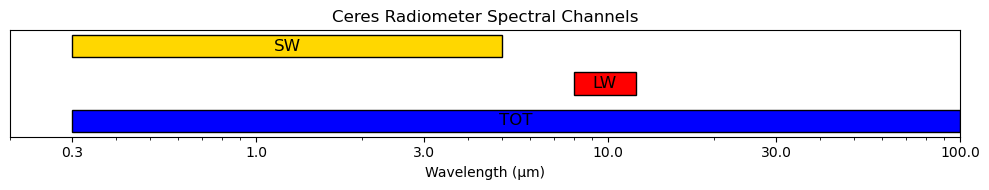

In [64]:
# def plot_libera_channels():
#     import matplotlib.pyplot as plt
#
#     channels = {
#         "SW": (0.3, 5),
#         "SSW": (0.7, 5),
#         "LW": (5, 50),
#         "TOT": (0.3, 100)
#     }
#
#     colors = {
#         "SW": "gold",
#         "SSW": "orange",
#         "LW": "red",
#         "TOT": "blue"
#     }
#
#     fig, ax = plt.subplots(figsize=(10,2))
#
#     y_positions = [3,2,1,0]
#
#     for (channel, (start, end)), y in zip(channels.items(), y_positions):
#
#         ax.barh(
#             y=y,
#             width=end-start,
#             left=start,
#             height=0.6,
#             color=colors[channel],
#             edgecolor="black",
#             label=channel
#         )
#
#         ax.text((start+end)/2, y, channel,
#                 ha="center", va="center", fontsize=12)
#
#     ax.set_yticks([])
#     ax.set_xlabel("Wavelength (μm)")
#     ax.set_xlim(0.03,100)
#
#     ax.set_title("Libera Radiometer Spectral Channels")
#
#     plt.tight_layout()
#     plt.xscale("log")
#     plt.savefig(f"./imgs/libera_channels.png", dpi=600, bbox_inches="tight")
#     plt.show()
# plot_libera_channels()
def plot_libera_channels():
    import matplotlib.pyplot as plt
    import numpy as np

    channels = {
        "SW": (0.3, 5),
        "SSW": (0.7, 5),
        "LW": (5, 50),
        "TOT": (0.3, 100)
    }

    colors = {
        "SW": "gold",
        "SSW": "orange",
        "LW": "red",
        "TOT": "blue"
    }

    fig, ax = plt.subplots(figsize=(10,2))

    # Set log scale BEFORE plotting
    ax.set_xscale("log")

    y_positions = [3,2,1,0]

    for (channel, (start, end)), y in zip(channels.items(), y_positions):

        ax.barh(
            y=y,
            width=end-start,
            left=start,
            height=0.6,
            color=colors[channel],
            edgecolor="black"
        )

        ax.text(
            np.sqrt(start*end),  # geometric center for log scale
            y,
            channel,
            ha="center",
            va="center",
            fontsize=12
        )

    ax.set_yticks([])

    ax.set_xlabel("Wavelength (μm)")
    ax.set_xlim(0.2, 100)

    # nice log ticks
    ax.set_xticks([0.3, 1, 3, 10, 30, 100])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

    ax.set_title("Libera Radiometer Spectral Channels")

    plt.tight_layout()

    plt.savefig("./imgs/libera_channels.png", dpi=600, bbox_inches="tight")
    plt.show()

plot_libera_channels()

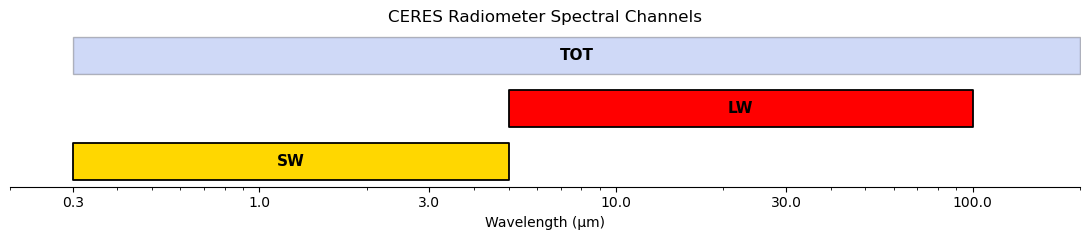

In [67]:
def plot_ceres_channels():
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.ticker import ScalarFormatter

    channels = {
        "SW":  (0.3, 5),
        "LW":  (5, 100),
        "TOT": (0.3, 200)
    }

    colors = {
        "SW": "gold",
        "LW": "red",
        "TOT": "blue"
    }

    fig, ax = plt.subplots(figsize=(11,2.5))
    ax.set_xscale("log")

    y_positions = {
        "TOT": 2,
        "LW": 1,
        "SW": 0
    }

    bar_height = 0.7

    # Plot TOT first so it sits behind the others
    start, end = channels["TOT"]
    ax.broken_barh(
        [(start, end-start)],
        (y_positions["TOT"] - bar_height/2, bar_height),
        facecolors=colors["TOT"],
        edgecolors="black",
        alpha=0.25
    )

    # Plot LW and SW
    for channel in ["LW","SW"]:
        start, end = channels[channel]
        y = y_positions[channel]

        ax.broken_barh(
            [(start, end-start)],
            (y - bar_height/2, bar_height),
            facecolors=colors[channel],
            edgecolors="black",
            linewidth=1.3
        )

        ax.text(
            np.sqrt(start*end),
            y,
            channel,
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

    # Label TOT
    ax.text(
        np.sqrt(channels["TOT"][0]*channels["TOT"][1]),
        y_positions["TOT"],
        "TOT",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_yticks([])
    ax.set_xlabel("Wavelength (μm)")
    ax.set_title("CERES Radiometer Spectral Channels")

    ax.set_xlim(0.2,200)

    ticks = [0.3,1,3,10,30,100]
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(ScalarFormatter())

    for spine in ["left","right","top"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig("./imgs/ceres_channels.png", dpi=600, bbox_inches="tight")
    plt.show()
plot_ceres_channels()

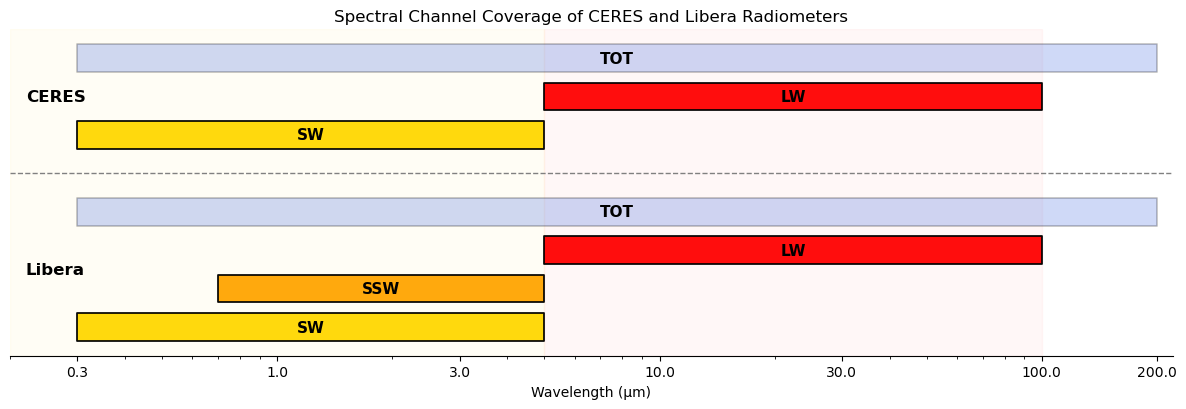

In [1]:
def plot_ceres_vs_libera_channels():
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.ticker import ScalarFormatter

    # wavelength ranges in microns
    channels = {
        "CERES": {
            "SW":  (0.3, 5.0),
            "LW":  (5.0, 100.0),
            "TOT": (0.3, 200.0),
        },
        "Libera": {
            "SW":  (0.3, 5.0),
            "SSW": (0.7, 5.0),
            "LW":  (5.0, 100.0),
            "TOT": (0.3, 200.0),
        }
    }

    colors = {
        "SW": "gold",
        "SSW": "orange",
        "LW": "red",
        "TOT": "royalblue",
    }

    fig, ax = plt.subplots(figsize=(12, 4.2))
    ax.set_xscale("log")

    # Optional spectral-region shading
    ax.axvspan(0.2, 5, color="gold", alpha=0.04)
    ax.axvspan(5, 100, color="red", alpha=0.03)

    # y positions with a gap between missions
    y_positions = {
        "CERES":  {"TOT": 6, "LW": 5, "SW": 4},
        "Libera": {"TOT": 2, "LW": 1, "SSW": 0, "SW": -1},
    }

    bar_height = 0.72

    # Plot TOT first for each mission so it sits visually behind the others
    for mission in ["CERES", "Libera"]:
        if "TOT" in channels[mission]:
            start, end = channels[mission]["TOT"]
            y = y_positions[mission]["TOT"]
            ax.broken_barh(
                [(start, end - start)],
                (y - bar_height / 2, bar_height),
                facecolors=colors["TOT"],
                edgecolors="black",
                linewidth=1.2,
                alpha=0.25,
            )
            ax.text(
                np.sqrt(start * end),
                y,
                "TOT",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
            )

    # Plot remaining channels
    plot_order = {
        "CERES": ["LW", "SW"],
        "Libera": ["LW", "SSW", "SW"],
    }

    for mission in ["CERES", "Libera"]:
        for channel in plot_order[mission]:
            start, end = channels[mission][channel]
            y = y_positions[mission][channel]

            ax.broken_barh(
                [(start, end - start)],
                (y - bar_height / 2, bar_height),
                facecolors=colors[channel],
                edgecolors="black",
                linewidth=1.3,
                alpha=0.95,
            )

            ax.text(
                np.sqrt(start * end),  # geometric midpoint for log axis
                y,
                channel,
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
            )

    # Mission labels on left side
    ax.text(0.22, 5.0, "CERES", ha="left", va="center", fontsize=12, fontweight="bold")
    ax.text(0.22, 0.5, "Libera", ha="left", va="center", fontsize=12, fontweight="bold")

    # Divider line between mission groups
    ax.axhline(3.0, color="gray", linestyle="--", linewidth=1)

    ax.set_yticks([])
    ax.set_xlabel("Wavelength (μm)")
    ax.set_title("Spectral Channel Coverage of CERES and Libera Radiometers")

    ax.set_xlim(0.2, 220)

    ticks = [0.3, 1, 3, 10, 30, 100, 200]
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(ScalarFormatter())

    for spine in ["left", "right", "top"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig("./imgs/ceres_vs_libera_channels.png", dpi=600, bbox_inches="tight")
    plt.show()


plot_ceres_vs_libera_channels()

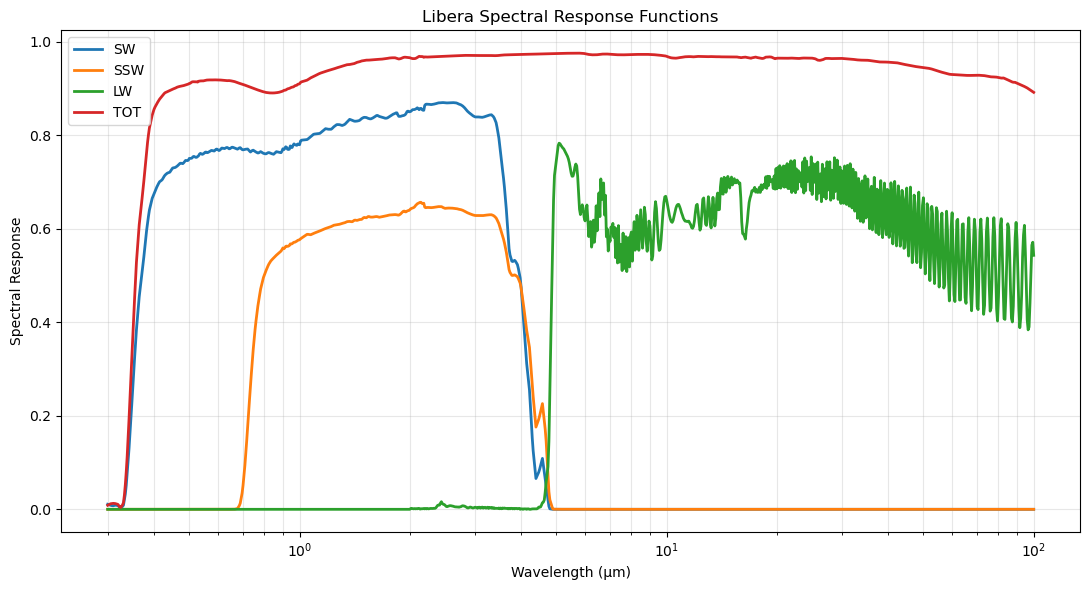

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_libera_srfs_thesis(csv_path: str):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    wavelength = df["wavelength [um]"]

    srf_cols = {
        "SW": "sw srf",
        "SSW": "ssw srf",
        "LW": "lw srf",
        "TOT": "total srf"
    }

    plt.figure(figsize=(11, 6))

    for label, col in srf_cols.items():
        plt.plot(wavelength, df[col], label=label, linewidth=2)

    plt.xlabel("Wavelength (μm)")
    plt.ylabel("Spectral Response")
    plt.title("Libera Spectral Response Functions")
    plt.xscale("log")   # helpful for broad wavelength ranges
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"./imgs/libera_srf.png", dpi=600, bbox_inches="tight")
    plt.show()

plot_libera_srfs_thesis("./data/libera_srfs_20241017.csv")

In [56]:
lw_scene_model.keys()

dict_keys(['Regression_val', 'Regression_test', 'GridSearch', 'Val_RMSE', 'Val_MAE', 'Val_MAPE%', 'Val_R2', 'CV_Fold_RMSEs', 'CV_RMSE_mean', 'CV_RMSE_std', 'ML_test_df', 'Regression_test_df', 'Test_plot_df', 'Test_RMSE', 'Test_MAE', 'Test_MAPE%', 'Test_R2', 'Final_Model', 'Params_Used', 'Train_data', 'Validation_data', 'Test_data'])

In [55]:
lw_scene_model["Regression_test"]["standard_df"]

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),...,Scaled Longwave Filtered,Scaled Longwave Unfiltered,Scene_Clear Ocean,Scene_Cloudy Ocean,Scene_Deep Convective Cloud,Scene_Land,Scene_Snow,SW_unf_pred,LW_unf_pred,SW_unf_pred_ssw
1,Snow,0.000,0.000,0.0,1,1,308.989576,61.707542,224.248333,40.116431,...,0.453486,0.439632,0,0,0,0,1,306.750735,61.672410,308.439979
23,Snow,0.066,30.000,7.5,1,23,363.425318,53.412802,268.780611,34.865491,...,0.344008,0.331623,0,0,0,0,1,365.897906,53.407251,363.131313
24,Snow,0.066,30.000,7.5,1,24,307.329228,62.886232,224.836618,40.892467,...,0.469666,0.454980,0,0,0,0,1,307.521388,62.906807,307.677807
32,Snow,0.311,30.000,37.5,1,32,294.881847,64.577008,213.489210,41.919058,...,0.491069,0.476996,0,0,0,0,1,292.079244,64.542155,294.353394
46,Snow,0.511,30.000,90.0,1,46,303.565123,60.699093,220.472793,39.470687,...,0.440023,0.426500,0,0,0,0,1,301.403554,60.653492,303.071942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6154,Clear Ocean,84.848,60.000,172.5,0,106,10.673827,91.598231,7.192588,58.423045,...,0.835165,0.828847,1,0,0,0,0,10.456862,91.442188,10.643683
6164,Clear Ocean,85.850,89.947,7.5,0,116,198.342393,68.745837,154.145855,44.440427,...,0.543638,0.531279,1,0,0,0,0,NaN,NaN,NaN
6169,Clear Ocean,85.648,89.947,37.5,0,121,57.066929,68.826195,43.106074,44.481174,...,0.544488,0.532326,1,0,0,0,0,NaN,NaN,NaN
6178,Clear Ocean,84.911,89.947,90.0,0,130,33.474285,68.745823,24.265128,44.440407,...,0.543638,0.531279,1,0,0,0,0,33.601134,68.713533,33.540045


RUN MODELS

In [33]:
sw_scene_model = final_ml_testing(
    dataset=dataset_ohe,
    v=True,
    is_sw=True,
    input_features=input_features + ['Shortwave Filtered Rads (Integrated)'],
)

Input features ['SZA', 'VZA', 'RAZ', 'Scene_Clear Ocean', 'Scene_Cloudy Ocean', 'Scene_Deep Convective Cloud', 'Scene_Land', 'Scene_Snow', 'Shortwave Filtered Rads (Integrated)']
In train/val/test split: ['SZA', 'VZA', 'RAZ', 'Scene_Clear Ocean', 'Scene_Cloudy Ocean', 'Scene_Deep Convective Cloud', 'Scene_Land', 'Scene_Snow', 'Shortwave Filtered Rads (Integrated)']
data sizes
(4940, 44)
(615, 44)
(640, 44)
Train (4940, 9), Val (615, 9), Test (640, 9)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


In [34]:
lw_scene_model = final_ml_testing(
    dataset=dataset_ohe,
    v=True,
    is_sw=False,
    input_features=input_features + ['Longwave Filtered Rads (Integrated)'],
)

Input features ['SZA', 'VZA', 'RAZ', 'Scene_Clear Ocean', 'Scene_Cloudy Ocean', 'Scene_Deep Convective Cloud', 'Scene_Land', 'Scene_Snow', 'Longwave Filtered Rads (Integrated)']
In train test split: ['SZA', 'VZA', 'RAZ', 'Scene_Clear Ocean', 'Scene_Cloudy Ocean', 'Scene_Deep Convective Cloud', 'Scene_Land', 'Scene_Snow', 'Longwave Filtered Rads (Integrated)']
data sizes
(4940, 44)
(605, 44)
(650, 44)
Train (4940, 9), Val (605, 9), Test (650, 9)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


In [35]:
sw_model = final_ml_testing(all_dataset, v=True, is_sw=True, input_features=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)', 'M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7'], use_groups=True)

Input features ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7']
In train/val/test split: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7']
data sizes
(4940, 39)
(615, 39)
(640, 39)
Train (4940, 14), Val (615, 14), Test (640, 14)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


In [36]:
lw_model = final_ml_testing(all_dataset, v=True, is_sw=False, input_features=['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)',  'M7', 'M9', 'I2', 'M16'], use_groups=True)

Input features ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M7', 'M9', 'I2', 'M16']
In train test split: ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M7', 'M9', 'I2', 'M16']
data sizes
(4940, 39)
(605, 39)
(650, 39)
Train (4940, 8), Val (605, 8), Test (650, 8)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


In [37]:
ssw_model = final_ml_testing(all_dataset, v=True,is_sw=True,input_features=["DNB", "M6", "M5", "M7", "I1", "I2", "Split Shortwave Filtered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)"],  use_groups=True)

Input features ['DNB', 'M6', 'M5', 'M7', 'I1', 'I2', 'Split Shortwave Filtered Rads (Integrated)', 'Shortwave Filtered Rads (Integrated)']
In train/val/test split: ['DNB', 'M6', 'M5', 'M7', 'I1', 'I2', 'Split Shortwave Filtered Rads (Integrated)', 'Shortwave Filtered Rads (Integrated)']
data sizes
(4940, 39)
(615, 39)
(640, 39)
Train (4940, 8), Val (615, 8), Test (640, 8)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


In [38]:
sw_all_channels_model = final_ml_testing(all_dataset, v=True, is_sw=True, input_features=['Shortwave Filtered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ'], use_groups=True)

Input features ['Shortwave Filtered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ']
In train/val/test split: ['Shortwave Filtered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ']
data sizes
(4940, 39)
(615, 39)
(640, 39)
Train (4940, 7), Val (615, 7), Test (640, 7)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


In [39]:
lw_all_channels_model = final_ml_testing(all_dataset, v=True, is_sw=False, input_features=['Shortwave Filtered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ'], use_groups=True)

Input features ['Shortwave Filtered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ']
In train test split: ['Shortwave Filtered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ']
data sizes
(4940, 39)
(605, 39)
(650, 39)
Train (4940, 7), Val (605, 7), Test (650, 7)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


In [26]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    sw_model["Final_Model"],
    sw_model["Test_data"]["X_test"],
    sw_model["Test_data"]["y_test"],
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

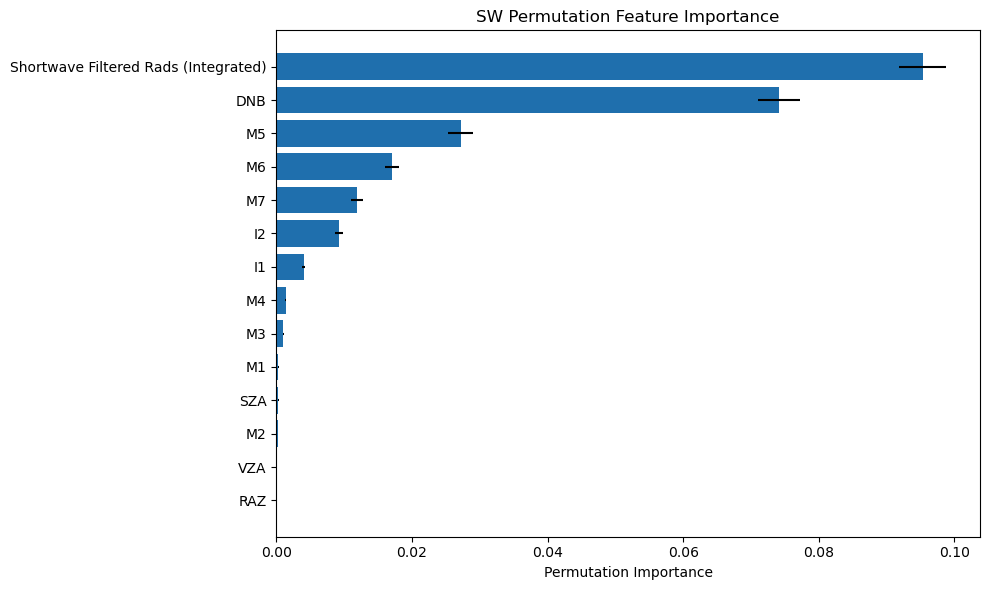

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_permutation_importance(perm_result, feature_names, title="Permutation Feature Importance"):
    sorted_idx = perm_result.importances_mean.argsort()

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.barh(
        range(len(sorted_idx)),
        perm_result.importances_mean[sorted_idx],
        xerr=perm_result.importances_std[sorted_idx],
        color="#1f6fad",
        align="center"
    )

    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx])
    ax.set_xlabel("Permutation Importance")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150)
    plt.show()

feature_names = ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)', 'M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7']

plot_permutation_importance(result, feature_names, title="SW Permutation Feature Importance")

In [24]:
sw_model["Params_Used"]

{'bootstrap': True,
 'max_depth': None,
 'max_features': 'sqrt',
 'max_samples': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 500,
 'random_state': 42,
 'n_jobs': -1}

In [58]:
sw_model_test = final_ml_testing(all_dataset, v=True, is_sw=False, input_features=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)', 'M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7'], use_groups=True)

Input features ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7']
In train test split: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7']
data sizes
(4940, 39)
(605, 39)
(650, 39)
Train (4940, 14), Val (605, 14), Test (650, 14)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


In [59]:
sw_model_test["Regression_test"]

{'overall': {'SW_1D': {'n': 621,
   'MAE': 0.591578148197707,
   'RMSE': 0.9011696151389379,
   'Bias': 0.0652531535444061,
   'MAPE_%': 0.6364777750098514,
   'R2': 0.9998892342827339},
  'LW_1D': {'n': 621,
   'MAE': 0.06148695464067089,
   'RMSE': 0.08075359202448348,
   'Bias': -0.00807446086780338,
   'MAPE_%': 0.08945212534903216,
   'R2': 0.9999741517622607},
  'SW_SSW': {'n': 621,
   'MAE': 0.19826969979937026,
   'RMSE': 0.281169005968886,
   'Bias': -0.00699818096606049,
   'MAPE_%': 0.26472851278538245,
   'R2': 0.9999892173086251}},
 'cloud=0': {'SW_1D': {'n': 179,
   'MAE': 0.4981673466353873,
   'RMSE': 0.7639826505923953,
   'Bias': 0.08752240895755765,
   'MAPE_%': 1.010309388937226,
   'R2': 0.9998513325278459},
  'LW_1D': {'n': 179,
   'MAE': 0.08590570477048164,
   'RMSE': 0.10976060683488509,
   'Bias': -0.03476819758920979,
   'MAPE_%': 0.10918371195454057,
   'R2': 0.9999260216074456},
  'SW_SSW': {'n': 179,
   'MAE': 0.2033540833499869,
   'RMSE': 0.2865645065845

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_multi_scene_spectra_with_srf(
    scene_dict: dict,
    srf_wavelengths: np.ndarray,
    sw_srf: np.ndarray,
    lw_srf: np.ndarray,
    run_index: int = 0,
    save_path: str = "multi_scene_spectra_srf.png",
    dpi: int = 600,
    plot_total: bool = True
):
    """
    Plot spectral radiance with and without SRF applied.

    Shows how the instrument spectral response function modifies
    the spectrum prior to broadband integration.

    Parameters
    ----------
    scene_dict : dict
        {scene_name: Tape7_object}

    srf_wavelengths : np.ndarray
        wavelength grid of SRF

    sw_srf : np.ndarray
        shortwave spectral response function

    lw_srf : np.ndarray
        longwave spectral response function

    run_index : int
        which run to plot

    plot_total : bool
        if True plots SW+LW combined spectrum
    """

    plt.figure(figsize=(9, 5))

    for scene_name, tp7_obj in scene_dict.items():

        run = tp7_obj.rads[run_index]

        wavelength = run[0]
        sw_rad = run[1]
        lw_rad = run[2]

        total_rad = sw_rad + lw_rad

        # interpolate SRFs onto MODTRAN wavelength grid
        sw_interp = np.interp(wavelength, srf_wavelengths, sw_srf)
        lw_interp = np.interp(wavelength, srf_wavelengths, lw_srf)

        filtered_sw = sw_rad * sw_interp
        filtered_lw = lw_rad * lw_interp

        filtered_total = filtered_sw + filtered_lw

        mask = wavelength > 0

        wavelength = wavelength[mask]
        total_rad = total_rad[mask]
        filtered_total = filtered_total[mask]

        # --- unfiltered spectrum ---
        plt.plot(
            wavelength,
            total_rad,
            linewidth=1.6,
            label=f"{scene_name} (unfiltered)"
        )

        # --- filtered spectrum ---
        plt.plot(
            wavelength,
            filtered_total,
            linestyle="--",
            linewidth=1.6,
            label=f"{scene_name} (filtered)"
        )

    plt.xscale("log")

    plt.xlabel("Wavelength (μm)")
    plt.ylabel("Spectral Radiance")
    plt.title("Effect of Instrument SRF on TOA Spectral Radiance")

    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.close()

    print(f"Saved figure to {save_path}")

In [8]:
# srf = SRFS("./data/libera_srfs_20241017.csv")
# tot_wvln = srf.srf_vals['wavelength [um]']
# sw_srf = srf.srf_vals[' sw srf']
# lw_srf = srf.srf_vals[' lw srf']
srf.srf_vals.columns

Index(['wavelength [um]', ' ssw srf', ' conv ssw srf', ' lw srf',
       ' conv lw srf', ' total srf', ' conv total srf', ' sw srf',
       ' conv sw srf', 'End_wv_range'],
      dtype='object')

In [9]:
plot_multi_scene_spectra_with_srf(
    scene_dict=a00,
    srf_wavelengths=srf.srf_vals["wavelength [um]"].values,
    sw_srf=srf.srf_vals[" sw srf"].values,
    lw_srf=srf.srf_vals[" lw srf"].values
)

Saved figure to multi_scene_spectra_srf.png


In [11]:
import matplotlib.pyplot as plt

def plot_land_filtered_vs_unfiltered(all_dataset, save_path="./imgs/land_filtering_effect.png"):

    land_df = all_dataset[all_dataset["Scene"] == "Land"]

    sw_unf = land_df["Shortwave Unfiltered Rads (Integrated)"]
    sw_filt = land_df["Shortwave Filtered Rads (Integrated)"]

    lw_unf = land_df["Longwave Unfiltered Rads (Integrated)"]
    lw_filt = land_df["Longwave Filtered Rads (Integrated)"]

    plt.figure(figsize=(6,5))

    plt.scatter(
        sw_unf,
        sw_filt,
        s=12,
        alpha=0.6,
        label="Shortwave"
    )

    plt.scatter(
        lw_unf,
        lw_filt,
        s=12,
        alpha=0.6,
        label="Longwave"
    )

    # 1:1 reference line
    min_val = min(sw_unf.min(), lw_unf.min())
    max_val = max(sw_unf.max(), lw_unf.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--"
    )

    plt.xlabel("Unfiltered Radiance")
    plt.ylabel("Filtered Radiance")

    plt.title("Effect of SRF on Land Scene Radiances")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=600)
    plt.close()

    print("Saved to", save_path)

plot_land_filtered_vs_unfiltered(all_dataset)

Saved to ./imgs/land_filtering_effect.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_land_radiance_srf_effect(
    land_tp7,
    srf_wavelengths,
    sw_srf,
    lw_srf,
    run_index=0,
    save_path="land_radiance_srf_effect.png",
    dpi=600
):
    """
    Plot Land spectral radiance before and after SRF application.

    Shows how instrument spectral response modifies the spectrum.

    Parameters
    ----------
    land_tp7 : Tape7 object
        Land scene Tape7 object

    srf_wavelengths : np.ndarray
        wavelength grid of SRF

    sw_srf : np.ndarray
        shortwave SRF

    lw_srf : np.ndarray
        longwave SRF

    run_index : int
        which MODTRAN run to plot
    """

    run = land_tp7.rads[run_index]

    wavelength = run[0]
    sw_rad = run[1]
    lw_rad = run[2]

    total_radiance = sw_rad + lw_rad

    # interpolate SRFs onto MODTRAN wavelength grid
    sw_interp = np.interp(wavelength, srf_wavelengths, sw_srf)
    lw_interp = np.interp(wavelength, srf_wavelengths, lw_srf)

    # apply SRFs
    filtered_sw = sw_rad * sw_interp
    filtered_lw = lw_rad * lw_interp

    filtered_total = filtered_sw + filtered_lw

    mask = wavelength > 0

    wavelength = wavelength[mask]
    total_radiance = total_radiance[mask]
    filtered_total = filtered_total[mask]

    plt.figure(figsize=(7,4))

    plt.plot(
        wavelength,
        total_radiance,
        linewidth=2,
        label="Unfiltered Radiance"
    )

    plt.plot(
        wavelength,
        filtered_total,
        linewidth=2,
        linestyle="--",
        label="Radiance with SRF applied"
    )

    plt.xscale("log")

    plt.xlabel("Wavelength (μm)")
    plt.ylabel("Spectral Radiance (W m$^{-2}$ sr$^{-1}$ μm$^{-1}$)")

    plt.title("Land TOA Spectral Radiance Before and After SRF Application")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.close()

    print(f"Saved to {save_path}")

In [13]:
type(a00["Land"])

tp7.tp7.Tape7

In [14]:
plot_land_radiance_srf_effect(
    land_tp7 = a00["Land"],
    srf_wavelengths=srf.srf_vals["wavelength [um]"].values,
    sw_srf=srf.srf_vals[" sw srf"].values,
    lw_srf=srf.srf_vals[" lw srf"].values,
    run_index = 0
)

Saved to land_radiance_srf_effect.png


In [40]:
sw_model.keys()

dict_keys(['Regression_val', 'Regression_test', 'GridSearch', 'Val_RMSE', 'Val_MAE', 'Val_MAPE%', 'Val_R2', 'CV_Fold_RMSEs', 'CV_RMSE_mean', 'CV_RMSE_std', 'ML_test_df', 'Regression_test_df', 'Test_plot_df', 'Test_RMSE', 'Test_MAE', 'Test_MAPE%', 'Test_R2', 'Final_Model', 'Params_Used', 'Train_data', 'Validation_data', 'Test_data'])